# analysis

### load base data

In [136]:
import pandas as pd

In [137]:
#读取Excel数据表，记录了116个任务里每个参与者（human/agent）完成任务的时间戳
formated_data_timestamps = pd.read_excel("Formated_Data_Renamed.xlsx", header=0, index_col=None, dtype=str)

In [138]:
TASK_COUNT = 116

In [139]:
formated_data_timestamps

,app,task_name,user1,user2,user3,ui-tars available humanity,Ui-tars success?,Mobile-agent-e gpt-4o available humanity,Mobile-agent-e gpt-4o available humanity success?,Mobile-agent-e claude-sonnet-3.7 available humanity,...,user4,user5,user6,user7,open_autoglm_agent_raw,open_autoglm_agent_raw success rate?,open_autoglm_agent_rot_tap_unclear,open_autoglm_agent_rot_tap_unclear success rate?,open_autoglm_rot_tap_fake_unclear,open_autoglm_rot_tap_fake_unclear success rate?
0,jd,搜索“无线耳机”，打开一个非自营卖家的商品页面，查看其一条评价。,20251012_104825,20251012_114348,20251014_142315,20251015_195101,20251013_091517With lots of human intervention...,20251013_102435,查看的是短视频。。有评价弹屏。。。,NaN,...,NaN,NaN,NaN,NaN,20260204_135645,NaN,20260205_102649,NaN,NaN,NaN
1,jd,找一个价格在50到100元之间的移动电源，加入购物车，然后从购物车中移除。,20251012_105107,20251012_114522,20251014_142456,20251015_195632,(20251013_091907 had volcengine failure)\n失败：不...,20251013_102921,加入了购物车，没能移除,20251013_144110,...,NaN,NaN,NaN,NaN,20260204_135751,NaN,NaN,NaN,NaN,NaN
2,jd,使用应用的对比功能，比较两个不同品牌的手机壳，重点关注价格和材质。,20251012_105412,20251012_114739,20251014_142701,20251015_200817,(20251013_092058 had volcengine failure)\n找了半天...,20251013_105043,失败（点击搜索时点了相机,20251013_144802,...,NaN,NaN,NaN,NaN,20260204_141548,NaN,NaN,NaN,NaN,NaN
3,jd,找到“百亿补贴”专区，选择一个补贴商品，查看其折扣价与原价。,20251012_105701,20251012_115003,20251014_143233,20251015_201818,(20251013_092208 had volcengine failure)\n成功,20251013_105309,找到了“百亿补贴”专区，which展示了很多折扣价与补贴额。然后什么都没干。,20251013_145243,...,NaN,NaN,NaN,NaN,20260204_142530,NaN,NaN,NaN,NaN,NaN
4,jd,选择一种日用品（例如洗发水），添加收货地址，进入订单确认页面，但不要提交支付。,20251012_105947,20251012_115159,20251014_143606,20251015_202029,(20251013_092319 volcengine dos) 洗发水订单确认，但是没有添...,20251013_105524,洗发水订单确认，但是没有添加收货地址,20251013_145513,...,NaN,NaN,NaN,NaN,20260204_153227,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,知乎,搜索“编程猫”，搜索用户，并进入结果中一个用户的主页，查看其最新发布的文章,20251115_185627,20251115_164345,NaN,20251201_201900,NaN,20251203_110016,NaN,20251204_044625,...,NaN,20260201_212750,20260201_225553,NaN,20260205_035702,NaN,20260206_005342,NaN,20260208_143542,NaN
112,知乎,搜索“编程猫”，搜索用户，并进入结果中一个用户的主页，查看其最新发布的文章，点赞该文章，点击...,20251115_185802,20251115_164609,NaN,20251201_202135,NaN,20251203_110711,NaN,20251204_050113,...,NaN,NaN,NaN,NaN,20260205_035835,NaN,20260206_010137,NaN,20260208_144231,NaN
113,知乎,搜索“人工智能”专栏,20251115_190001,20251115_164832,NaN,20251201_202546_problematic,NaN,20251203_113803,NaN,20251204_053224,...,NaN,20260201_212927,20260201_225713,20260202_205336,20260205_035943,NaN,20260206_010244,NaN,20260208_144337,NaN
114,知乎,搜索“人工智能”专栏，查看一篇专栏中的文章并评论“hello world”,20251115_190056,20251115_164957,NaN,20251201_202819_problematic,NaN,20251203_115101,NaN,20251204_054532,...,NaN,20260201_213026,20260201_225813,NaN,20260205_040403,NaN,20260206_010422,NaN,20260208_144554,NaN


In [140]:
# print all unique app names in formated_data_timestamps
formated_data_timestamps['app'].unique()

array(['jd', 'eleme', 'ctrip', 'qqmusic', 'iqiyi', '哔哩哔哩', '菜鸟裹裹', '高德地图',
       '航旅纵横', '好大夫', '美团', '去哪儿', '淘宝', '腾讯文档', '腾讯会议', '今日头条', '微博',
       '小红书', '有道词典', '知乎'], dtype=object)

In [141]:
# classify: social media, shopping, video streaming, trip planning, office&learning, others
#把116个任务按app类型分成5个cluster
from typing import List


task_cluster_by_name = {
    "social_media": ['今日头条', '微博', '小红书', '知乎'],
    "shopping": ['jd', '淘宝', '菜鸟裹裹', '美团', 'eleme'],
    "video_streaming": ['iqiyi', '哔哩哔哩', 'qqmusic'],
    "trip_planning": ['ctrip', '高德地图', '航旅纵横', '去哪儿'],
    "office_learning": ['腾讯文档', '腾讯会议', '有道词典', '好大夫'],
}

# check that each task is classified
all_mentioned_tasks = set()
for task_list in task_cluster_by_name.values():
    all_mentioned_tasks.update(task_list)
all_given_tasks = set(formated_data_timestamps['app'].unique())
assert all_mentioned_tasks == all_given_tasks, f"Some tasks are not classified: {all_given_tasks - all_mentioned_tasks}"
#assert验证了所有app都被分进了某个cluster，没有遗漏

task_clusters: List[List[int]] = [
    list(formated_data_timestamps.index[formated_data_timestamps["app"].isin(lister)]) for key, lister in task_cluster_by_name.items()
]
#把每个cluster转换成行索引列表

In [142]:
#test case,验证索引筛选逻辑是否正确
formated_data_timestamps.index[formated_data_timestamps['app'].isin(["jd"])]

Index([0, 1, 2, 3, 4], dtype='int64')

In [143]:
from analysis.lib.gesture_log_reader_utils import file_finder
from pathlib import Path

In [144]:
import numpy as np
np.isnan(float("nan")), np.isnan(float("inf"))

(True, False)

### test existence

In [145]:
#数据完整性检查格子，作者用它来确认GPT-4o agent的数据是否都已经下载到本地
for timestamp in formated_data_timestamps["gpt4o no humanity"]:
    if (not isinstance(timestamp, str)):
        continue
    stripped_timestamp = timestamp.strip()
    if stripped_timestamp != "":
        print(file_finder(Path("."), "gesture_recording_" + stripped_timestamp + ".log"))

gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_085544.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_092951.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_093831.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_094246.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250924_090037.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_101347.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_101607.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_102121.log
gesture_recordings/mobile_agent_e_gpt_4o_no_humanity_gesture_recording/gesture_recording_20250925_102416.log
gesture_recordings/

gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_072318.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_073119.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_075353.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_080004.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_080650.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_083814.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_084822.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_085752.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_090550.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092448.log
gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recordi

### extract column names

In [148]:
formated_data_timestamps.columns

Index(['app', 'task_name', 'user1', 'user2', 'user3',
       'ui-tars available humanity', 'Ui-tars success?',
       'Mobile-agent-e gpt-4o available humanity',
       'Mobile-agent-e gpt-4o available humanity success?',
       'Mobile-agent-e claude-sonnet-3.7 available humanity',
       'Mobile-agent-e claude-sonnet-3.7 available humanity success?',
       'Online humanity best effort count', 'ui-tars no humanity',
       'ui-tars no humanity success?', 'gpt4o no humanity',
       'gpt4o no humanity success?', 'claude no humanity',
       'claude no humanity success?', 'No humanity Best effort count',
       'cpm_gui_agent raw', 'cpm_gui_agent available humanity',
       'cpm available humanity success?', 'cpm no humanity success?',
       'ui_tars_only_swipe', 'ui_tars_only_swipe success?',
       'mobile_agent_e_gpt_4o_only_swipe',
       'mobile_agent_e_gpt_4o_only_swipe success?', 'only swipe success rate',
       'ui_tars_rot_tap_and_faked', 'ui_tars_rot_tap_and_faked success?'

In [149]:
formated_data_timestamps.columns[30]

'mobile_agent_e_gpt_4o_rot_tap_and_faked'

In [150]:
#这个部分跟作者的数量不一致，应该是证明了数据集在持续的更新
columns_list = list(formated_data_timestamps.columns)
len(columns_list)

43

In [151]:
#从Excel列名里提取出各个participant的名字，分类成humans、humanized_agents、non_humanized_agents等五个列表
from operator import itemgetter
from typing import Tuple

humans: List[str] = list(itemgetter(2, 3, 4, 33, 34, 35, 36)(columns_list))
humanized_agents: List[str] = list(itemgetter(5, 7, 9, 20)(columns_list))
non_humanized_agents: List[str] = list(itemgetter(12, 14, 16, 37)(columns_list))
rot_humanized_agents: List[str] = list(itemgetter(23, 25)(columns_list))
fake_rot_tap_humanized_agents: List[str] = list(itemgetter(28, 30)(columns_list))

# Human demographic groups (confirmed from paper Table 4)
young_males = ["user1", "user2", "user3"]
young_females = ["user4"]
middle_aged = ["user5", "user6"]
elderly = ["user7"]
all_humans = humans

# Agent groups by model
ui_tars = ["ui-tars no humanity", "ui-tars available humanity", "ui_tars_only_swipe"]
gpt4o_agents = ["gpt4o no humanity", "Mobile-agent-e gpt-4o available humanity", "mobile_agent_e_gpt_4o_only_swipe"]
claude_agents = ["claude no humanity", "Mobile-agent-e claude-sonnet-3.7 available humanity"]
autoglm_agents = ["open_autoglm_agent_raw"]  # substituted for cpm_gui_agents (data not in public release)
# cpm_gui_agents = ["cpm_gui_agent raw", "cpm_gui_agent available humanity"]  # not available in public dataset

In [153]:
for i in [humans, humanized_agents, non_humanized_agents, rot_humanized_agents, fake_rot_tap_humanized_agents]:
    print(i)

['user1', 'user2', 'user3', 'user4', 'user5', 'user6', 'user7']
['ui-tars available humanity', 'Mobile-agent-e gpt-4o available humanity', 'Mobile-agent-e claude-sonnet-3.7 available humanity', 'cpm_gui_agent available humanity']
['ui-tars no humanity', 'gpt4o no humanity', 'claude no humanity', 'open_autoglm_agent_raw']
['ui_tars_only_swipe', 'mobile_agent_e_gpt_4o_only_swipe']
['ui_tars_rot_tap_and_faked', 'mobile_agent_e_gpt_4o_rot_tap_and_faked']


In [283]:
for agent in humanized_agents:
    data = ranged_swipe_generator(participants=[agent])
    print(f"{agent}: {len(data)} sessions")

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251201_162133.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251201_194046.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 2 samples in the generated trace.


ui-tars available humanity: 339 sessions


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191019.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191303.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_194143.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

Mobile-agent-e gpt-4o available humanity: 157 sessions


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_205324.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251204_020956.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 7 complete samples from all 8 samples in the generated trace.


Mobile-agent-e claude-sonnet-3.7 available humanity: 46 sessions


Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251215_073950.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 1. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251215_081213.log: Unexpected log format: invalid id inheritance. fleeting_id: ffffffff, inherited_id: ffffffff, line: [   58931.471161] /dev/input/event4: EV_ABS       ABS_MT_TRACKING_ID   ffffffff            
. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251215_141730.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 5 complete samples from all 6 samples in the generated trace.


cpm_gui_agent available humanity: 286 sessions


### Design basic reader for this data

In [155]:
from functools import partial
from analysis.processing.extract_feature_of_swipes import deprecated_cleanse_into_swipe as cleanse_into_swipe
from analysis.lib.gesture_log_reader_utils import ranged_modified_generator_without_session_timestamp as previous_ranged_modified_generator
from analysis.processing.tap_duration_extract import leave_taps
from typing import Callable, List, Optional
from analysis.lib.motionevent_classes import FingerEvent
ranged_swipe_generator: Callable[[List[str], Optional[List[int]], Optional[Callable[[List[FingerEvent]], List[FingerEvent]]]], List[List[FingerEvent]]] = partial(previous_ranged_modified_generator, formated_data_timestamps=formated_data_timestamps, filtering_and_modification_function=cleanse_into_swipe)
#过滤掉tap，只保留滑动动作
ranged_tap_generator = partial(previous_ranged_modified_generator, formated_data_timestamps=formated_data_timestamps, filtering_and_modification_function=leave_taps)
#过滤掉swipe，只保留点击动作
ranged_raw_generator = partial(previous_ranged_modified_generator, formated_data_timestamps=formated_data_timestamps, filtering_and_modification_function=None)
#不过滤，swipe和tap都保留

In [264]:
#定义了三个核心"数据读取器"和三个"数据变换器"
from analysis.processing.fit_effort_provider import FitEffortProvider, bot_line_fit
from analysis.processing.fit_effort_provider import pickle
from analysis.processing.fit_effort_provider import b_spline_faker as previous_b_spline_faker

static_fit_effort_provider: FitEffortProvider
with open("analysis/processing/swipe_data.pkl", "rb") as f:
    static_fit_effort_provider = FitEffortProvider(
        pickle.load(f)
    )
#把agent的swipe轨迹替换成人类的相似轨迹
b_spline_faker = partial(previous_b_spline_faker, neighbor_time_delta_us=11000)
#B-spline噪声注入器，给agent的swipe轨迹加上随机曲线扰动，让轨迹看起来不那么笔直
def raw_faker(event_list: List[FingerEvent]) -> List[FingerEvent]:
    return bot_line_fit(x1=event_list[0].x, y1=event_list[0].y, x2=event_list[-1].x, y2=event_list[-1].y, duration_us=500 * 1000, neighbor_time_delta_us=11000, end_upfinger_time_us=600 * 1000)
#把任何swipe轨迹替换成完全笔直的机器人线段

### Print table of swipe count: row: task column: agent

In [164]:
#统计每个participant在每个task里做了多少次swipe，生成一个116×N的计数表，保存成CSV，用于数据质量验证
def execute_swipe_count_individual_participants():
    all_participants = humans + non_humanized_agents + humanized_agents + rot_humanized_agents + fake_rot_tap_humanized_agents
    swipe_counts_individual_participants = pd.DataFrame(columns=all_participants, index=range(TASK_COUNT))

    for task in range(TASK_COUNT):
        for participant in all_participants:
            # print(f"Processing task {task} participant {participant}")
            generator = ranged_swipe_generator(participants=[participant], index_range=[task])
            swipe_count = len(generator)
            # aggregate swipe_count into a 
            swipe_counts_individual_participants.loc[task, participant] = swipe_count
    swipe_counts_individual_participants.to_csv("results0125/swipe_counts_individual_participants.csv")
    # print sum of swipe counts across tasks for each participant
    total_swipe_counts = swipe_counts_individual_participants.sum(axis=0)
    print(total_swipe_counts)


    # totalize over the 5 categories
    all_humans = ["user1", "user2", "user3", "user4", "user5", "user6", "user7"]
    autoglm_agents = ["open_autoglm_agent_raw"]
    for category in [all_humans, ui_tars, gpt4o_agents, claude_agents, autoglm_agents]:
        success_counts = total_swipe_counts[category].sum()
        print(f"Category {category} total swipe counts: {success_counts}")
    
execute_swipe_count_individual_participants()

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_114522.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_115003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_143233.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     940.922936] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till

SYN_CONFIG found in line, which is unexpected but not disruptive: [     839.185891] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251201_162133.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260122_233404.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 797 complete samples from all 798 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_194143.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 com

Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_204914.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_020851.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 55 complete samples from all 56 samples in the generated trace.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_135228.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_205007.log, which is unexpected and currently not supported. Skipping this file.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_212222.log: Unexpected log format: log ended without pr

Kept 746 complete samples from all 747 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_034233.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 746 complete samples from all 747 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_220114.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 24. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_041349.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The

Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_080821.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 47 complete samples from all 48 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_080821.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 47 complete samples from all 48 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251215_073950.log: Unexpected log format: l

...

Kept 476 complete samples from all 477 samples in the generated trace.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154750.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_133011.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251217_020420.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_051730.log. This may 

Kept 743 complete samples from all 744 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_161447.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 786 complete samples from all 787 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_164609.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 813 complete samples from all 814 samples in the generated trace.
Incomplete sa

Kept 17 complete samples from all 18 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_012902.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 17 complete samples from all 18 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_194536.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 131 complete samples from all 132 samples in the generated trace.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_204358.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260122_044855.log. This may indicat

Kept 3 complete samples from all 4 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_021015.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 36. Discarding the last incomplete trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_214943.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 743 complete samples from all 744 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_222101.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 63 complete samples from all 64 samples in the generated trace.
Incomplete sample detected in fi

user1                                                    680
user2                                                    892
user3                                                    247
user4                                                    165
user5                                                    152
user6                                                    186
user7                                                    432
ui-tars no humanity                                      380
gpt4o no humanity                                        148
claude no humanity                                       141
open_autoglm_agent_raw                                   339
ui-tars available humanity                               339
Mobile-agent-e gpt-4o available humanity                 157
Mobile-agent-e claude-sonnet-3.7 available humanity       46
cpm_gui_agent available humanity                         286
ui_tars_only_swipe                                       344
mobile_agent_e_gpt_4o_on

### Print table of tap count: row: task column: agent

In [167]:
def execute_tap_count_individual_participants():
    all_participants = humans + non_humanized_agents + humanized_agents + rot_humanized_agents + fake_rot_tap_humanized_agents
    tap_counts_individual_participants = pd.DataFrame(columns=all_participants, index=range(TASK_COUNT))
    for task in range(TASK_COUNT):
        for participant in all_participants:
            # print(f"Processing task {task} participant {participant}")
            generator = ranged_tap_generator(participants=[participant], index_range=[task])
            tap_count = len(generator)
            # aggregate swipe_count into a 
            tap_counts_individual_participants.loc[task, participant] = tap_count
    tap_counts_individual_participants.to_csv("results0125/tap_counts_individual_participants.csv")
    
    # print sum of tap counts across tasks for each participant
    total_tap_counts = tap_counts_individual_participants.sum(axis=0)
    print(total_tap_counts)

    all_humans = ['user1', 'user2', 'user3', 'user4', 'user5', 'user6', 'user7']
    autoglm_agents = ['open_autoglm_agent_raw']
    for category in [all_humans, ui_tars, gpt4o_agents, claude_agents, autoglm_agents]:
        success_counts = total_tap_counts[category].sum()
        print(f"Category {category} total tap counts: \t {success_counts}")
execute_tap_count_individual_participants()

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_114522.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_115003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_143233.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     940.922936] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till

SYN_CONFIG found in line, which is unexpected but not disruptive: [     839.185891] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251201_162133.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260122_233404.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 797 complete samples from all 798 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_194143.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 com

Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_204914.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_020851.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 55 complete samples from all 56 samples in the generated trace.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_135228.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_205007.log, which is unexpected and currently not supported. Skipping this file.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_212222.log: Unexpected log format: log ended without pr

Kept 746 complete samples from all 747 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_034233.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 746 complete samples from all 747 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_220114.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 24. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_041349.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The

Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_080821.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 47 complete samples from all 48 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_080821.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 47 complete samples from all 48 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251215_073950.log: Unexpected log format: l

...

Kept 476 complete samples from all 477 samples in the generated trace.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154750.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_133011.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251217_020420.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_051730.log. This may 

Kept 743 complete samples from all 744 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_161447.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 786 complete samples from all 787 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_164609.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 813 complete samples from all 814 samples in the generated trace.
Incomplete sa

Kept 17 complete samples from all 18 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_012902.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 17 complete samples from all 18 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_194536.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 131 complete samples from all 132 samples in the generated trace.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_204358.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260122_044855.log. This may indicat

Kept 3 complete samples from all 4 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_021015.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 36. Discarding the last incomplete trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_214943.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 743 complete samples from all 744 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_222101.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 63 complete samples from all 64 samples in the generated trace.
Incomplete sample detected in fi

user1                                                  1459
user2                                                  1464
user3                                                   744
user4                                                   403
user5                                                   593
user6                                                   733
user7                                                   500
ui-tars no humanity                                     772
gpt4o no humanity                                       827
claude no humanity                                      846
open_autoglm_agent_raw                                 1580
ui-tars available humanity                             1031
Mobile-agent-e gpt-4o available humanity                745
Mobile-agent-e claude-sonnet-3.7 available humanity     673
cpm_gui_agent available humanity                       1950
ui_tars_only_swipe                                      644
mobile_agent_e_gpt_4o_only_swipe        

## Print sensorevent counts

In [28]:
#1.1是关于sensor的，这个部分作为辅助
# reload analysis.lib.gesture_log_reader_utils
#import importlib
#import analysis.lib.gesture_log_reader_utils
#_ = importlib.reload(analysis.lib.gesture_log_reader_utils)

In [29]:
from analysis.lib.gesture_log_reader_utils import rectify_timestamp_idx

all_participants = humans + non_humanized_agents + humanized_agents + rot_humanized_agents + fake_rot_tap_humanized_agents

all_participants = list(all_participants)

rectified_formated_data_timestamps = rectify_timestamp_idx(formated_data_timestamps, participants=all_participants)




In [30]:
rectified_formated_data_timestamps

{'user1': [(0, '20251012_104825'),
  (1, '20251012_105107'),
  (2, '20251012_105412'),
  (3, '20251012_105701'),
  (4, '20251012_105947'),
  (5, '20251012_110215'),
  (6, '20251012_110410'),
  (7, '20251012_110544'),
  (8, '20251012_110943'),
  (9, '20251012_111051'),
  (10, '20251012_111330'),
  (11, '20251012_111614'),
  (12, '20251012_111812'),
  (13, '20251012_112054'),
  (14, '20251012_112232'),
  (15, '20251012_112338'),
  (16, '20251012_112445'),
  (17, '20251012_112604'),
  (18, '20251012_112714'),
  (19, '20251012_112855'),
  (20, '20251012_113033'),
  (21, '20251012_113200'),
  (22, '20251012_113351'),
  (23, '20251012_113511'),
  (24, '20251012_113631'),
  (25, '20251012_113825'),
  (26, '20251115_152846'),
  (27, '20251115_153005'),
  (28, '20251115_153134'),
  (29, '20251115_153336'),
  (30, '20251115_153556'),
  (31, '20251115_153746'),
  (32, '20251115_153947'),
  (33, '20251115_154143'),
  (34, '20251115_154302'),
  (35, '20251115_170110'),
  (36, '20251115_170216'),
  

In [31]:
from typing import Dict, List, Tuple
a: Dict[str, List[int]] = {"a": [1], "b": [2], }
a

{'a': [1], 'b': [2]}

In [32]:
import analysis.lib.sensor_log_reader_utils
importlib.reload(analysis.lib.sensor_log_reader_utils)

<module 'analysis.lib.sensor_log_reader_utils' from '/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization-Benchmark-main/analysis/lib/sensor_log_reader_utils.py'>

In [33]:
from analysis.lib.sensor_log_reader_utils import ranged_batched_modified_sensor_generator_with_session_timestamp, SensorSessionType

def print_sensor_counts(participants_group_to_consider: List[List[str]]):

    total_table = pd.DataFrame()
    for participants in participants_group_to_consider:
        for participant in participants:
            generator = ranged_batched_modified_sensor_generator_with_session_timestamp(
                formated_data_timestamps_rectified=rectified_formated_data_timestamps,
                participants=[participant],
                index_range=None,
                use_tqdm_for_each_participant=True
            )

            all_sensors = set.union(*[set(session["sensor_data_for_each_sensor_type"].keys()) for session in generator])
            
            sensor_counts_individual_participants = pd.DataFrame(columns=list(all_sensors))

            for sensor in all_sensors:
                sum_count = sum(session["sensor_data_for_each_sensor_type"][sensor].shape[0] for session in generator if sensor in session["sensor_data_for_each_sensor_type"])
                sensor_counts_individual_participants.loc[participant, sensor] = sum_count
            
            print(sensor_counts_individual_participants)
            total_table = pd.concat([total_table, sensor_counts_individual_participants], axis=0)
        # print sum of sensor counts across tasks for each participant
    total_table.to_csv("results0125/sensor_counts_individual_participants.csv")
    print(total_table)

In [34]:


print_sensor_counts([young_males, ui_tars, gpt4o_agents, claude_agents, cpm_gui_agents])

 18%|██████████▌                                               | 21/115 [00:00<00:00, 108.00it/s]

 60%|██████████████████████████████████▊                       | 69/115 [00:00<00:00, 189.95it/s]

100%|█████████████████████████████████████████████████████████| 115/115 [00:00<00:00, 186.10it/s]

TypeError: unbound method set.union() needs an argument

In [31]:

print_sensor_counts([["ui_tars_rot_tap_and_faked", "mobile_agent_e_gpt_4o_rot_tap_and_faked"]])

100%|██████████| 89/89 [00:45<00:00,  1.94it/s]


                           Gravity StepCounter Accelerometer StepDetector  \
ui_tars_rot_tap_and_faked  3213647          89       3213798            0   

                          Light MotionDetector RotationVector Proximity  \
ui_tars_rot_tap_and_faked  2833              0        3200123       185   

                          Gyroscope LinearAcceleration MagneticField Pressure  
ui_tars_rot_tap_and_faked   3213773            3213644        786520        0  


100%|██████████| 89/89 [03:32<00:00,  2.39s/it]

                                          Gravity StepCounter Accelerometer  \
mobile_agent_e_gpt_4o_rot_tap_and_faked  14345959          89      14346123   

                                        StepDetector Light MotionDetector  \
mobile_agent_e_gpt_4o_rot_tap_and_faked            0   425              0   

                                        RotationVector Proximity Gyroscope  \
mobile_agent_e_gpt_4o_rot_tap_and_faked       14345898       178  14346063   

                                        LinearAcceleration MagneticField  \
mobile_agent_e_gpt_4o_rot_tap_and_faked           14345962       3525565   

                                        Pressure  
mobile_agent_e_gpt_4o_rot_tap_and_faked        0  
                                          Gravity StepCounter Accelerometer  \
ui_tars_rot_tap_and_faked                 3213647          89       3213798   
mobile_agent_e_gpt_4o_rot_tap_and_faked  14345959          89      14346123   

                                    

## Plot tap duration

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_010704.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_051730.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_052108.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 11 complete samples from all 12 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_073155.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

Kept 52 complete samples from all 53 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_213037.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 52 complete samples from all 53 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_213601.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 4. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_214331.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 31. Discarding the last incomplete trace.
Error processing file gesture_recordings/gestu

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260122_231743.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 382 complete samples from all 383 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260122_233404.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 797 complete samples from all 798 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_000517.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 41 complete samples from all 42 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_20

Kept 746 complete samples from all 747 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_055135.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 97 complete samples from all 98 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_055701.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 756 complete samples from all 757 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_062815.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 590 complete samples from all 591 samples in the generated trace.
Error process

Kept 792 complete samples from all 793 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_105741.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 786 complete samples from all 787 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_105741.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 786 complete samples from all 787 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025

Kept 585 complete samples from all 586 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_153141.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 98 complete samples from all 99 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_153644.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 130 complete samples from all 131 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recor

Kept 418 complete samples from all 419 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_210710.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 749 complete samples from all 750 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_213910.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 105 complete samples from all 106 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_214338.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 64 complete samples from all 65 samples in the generated trace.
Incomplete sa

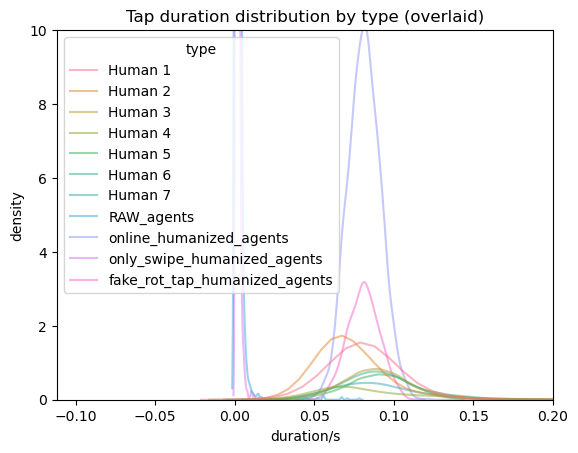

In [162]:
#先在1.6里通过散点图确定|f|<5这个阈值的 → 作者编进了leave_taps函数，再在1.2里用这个阈值区分tap和swipe
from typing import List, Tuple
from analysis.lib.motionevent_classes import FingerEvent
from analysis.processing.tap_duration_extract import build_durations_dataframe
import seaborn as sns
def execute_tap_duration_individual_participants():

    humans_list: List[Tuple[str, List[List[FingerEvent]]]] = [
        (human_name, ranged_tap_generator(participants=[human_name]))
        for human_name in humans
    ]

    generator_list: List[Tuple[str, List[List[FingerEvent]]]] = [
        *humans_list,
        ("RAW_agents", ranged_tap_generator(participants=non_humanized_agents)),
        ("online_humanized_agents", ranged_tap_generator(participants=humanized_agents)),
        ("only_swipe_humanized_agents", ranged_tap_generator(participants=rot_humanized_agents)),
        ("fake_rot_tap_humanized_agents", ranged_tap_generator(participants=fake_rot_tap_humanized_agents)),
    ]
    duration_df = build_durations_dataframe(generator_list)
    # ax = sns.histplot(data=duration_df, x="duration_us", hue="type", bins=50, element="step", alpha=0.5)
    duration_df["duration_us"] /= 1e6
    
    duration_df.loc[:, "type"] = duration_df["type"].replace({
    humans[i]: f"Human {i+1}" for i in range(len(humans))
    })
    
    ax = sns.kdeplot(data=duration_df, x="duration_us", hue="type", alpha=0.5)
    ax.set_xlabel("duration/s")
    ax.set_ylabel("density")
    ax.set_title("Tap duration distribution by type (overlaid)")
    ax.set_ylim(0, 10)
    ax.set_xlim(None, 200000 / 1e6)

    # put legends to right upper corner
    
    
execute_tap_duration_individual_participants()

In [45]:
formated_data_timestamps.columns

Index(['app', 'task_name', 'user1', 'user2', 'user3',
       'ui-tars available humanity', 'Ui-tars success?',
       'Mobile-agent-e gpt-4o available humanity',
       'Mobile-agent-e gpt-4o available humanity success?',
       'Mobile-agent-e claude-sonnet-3.7 available humanity',
       'Mobile-agent-e claude-sonnet-3.7 available humanity success?',
       'Online humanity best effort count', 'ui-tars no humanity',
       'ui-tars no humanity success?', 'gpt4o no humanity',
       'gpt4o no humanity success?', 'claude no humanity',
       'claude no humanity success?', 'No humanity Best effort count',
       'cpm_gui_agent raw', 'cpm_gui_agent available humanity',
       'cpm available humanity success?', 'cpm no humanity success?',
       'ui_tars_only_swipe', 'ui_tars_only_swipe success?',
       'mobile_agent_e_gpt_4o_only_swipe',
       'mobile_agent_e_gpt_4o_only_swipe success?', 'only swipe success rate',
       'ui_tars_rot_tap_and_faked', 'ui_tars_rot_tap_and_faked success?'

## calculate tap thresholding

In [288]:
#分别在5个cluster上测试，验证这个特征在不同任务类型下是否都有效
import random
random.seed(42)
from typing import Dict, List, Tuple, Optional
from analysis.lib.motionevent_classes import FingerEvent
from analysis.processing.interval_extract import build_intervals_dataframe
from analysis.lib.gesture_log_reader_utils import ranged_batched_modified_generator_with_session_timestamp
from analysis.lib.motionevent_classes import SessionType
from analysis.processing.calculate_roc_auc_from_feature import compute_acc_per_feature_using_thresholding, ThresholdPosterior
from analysis.processing.calculate_roc_auc_from_feature import compute_acc_per_feature_using_max_precision as compute_acc_per_feature
from analysis.processing.interval_extract import build_intervals_dataframe, faking_intervals_between_gestures

from analysis.processing.tap_duration_extract import build_durations_dataframe

import seaborn as sns
def execute_tap_duration_of_participants_per_index(index_range: Optional[List[int]] = None):


    generator_list: List[Tuple[str, List[List[FingerEvent]]]] = [
        ("Humans", ranged_tap_generator(participants=humans)),
        ("non_humanized_agents", ranged_tap_generator(participants=non_humanized_agents, index_range=index_range)),
        ("humanized_agents", ranged_tap_generator(participants=humanized_agents, index_range=index_range)),
        ("non_humanized_agents_fake", ranged_tap_generator(participants=non_humanized_agents, index_range=index_range)),
        ("humanized_agents_fake", ranged_tap_generator(participants=humanized_agents, index_range=index_range)),
        ("rot_humanized_agents", ranged_tap_generator(participants=rot_humanized_agents, index_range=index_range)),
        ("fake_rot_tap_humanized_agents", ranged_tap_generator(participants=fake_rot_tap_humanized_agents, index_range=index_range)),
    ]
    duration_df = build_durations_dataframe(generator_list)

    # modify the duration: for fake agents, replace duration with faked duration
    mask_non_humanized_agents_fake = duration_df["type"] == "non_humanized_agents_fake"
    mask_humanized_agents_fake = duration_df["type"] == "humanized_agents_fake"

    # for each duration in mask_non_humanized_agents_fake, assign a distribution: max(int(random.normalvariate(80000, 10000)), 20000)
    import random
    def fake_duration():
        return max(int(random.normalvariate(80000, 10000)), 20000)
    duration_df.loc[mask_non_humanized_agents_fake, "duration_us"] = duration_df.loc[mask_non_humanized_agents_fake, "duration_us"].apply(lambda x: fake_duration())
    
    # for each duration in mask_humanized_agents_fake, assign a number: 100
    duration_df.loc[mask_humanized_agents_fake, "duration_us"] = duration_df.loc[mask_humanized_agents_fake, "duration_us"].apply(lambda x: 100)

    return duration_df



def calculate_tap_duration_accuracies_per_task_cluster():

    result_interval = pd.DataFrame(columns=["task_cluster", "raw_accuracy", "humanized_accuracy", "raw_fake_accuracy", "humanized_unhumanize_accuracy"])

    raw_humanity_classifier_across_clusters: Dict[int, ThresholdPosterior] = {}
    humanized_humanity_classifier_across_clusters: Dict[int, ThresholdPosterior] = {}
    for cluster_idx, task_list in enumerate(task_clusters):
        duration_df = execute_tap_duration_of_participants_per_index(index_range=task_list)

        # duration_df.to_csv(f"results1220/intervals_task_cluster_{cluster_idx}.csv", index=False)

        accuracy_raw, raw_humanity_duration_us_classifier = compute_acc_per_feature_using_thresholding(duration_df, pos_label="non_humanized_agents", neg_label="Humans", threshold=5000)
        raw_humanity_duration_us_classifier = raw_humanity_duration_us_classifier["duration_us"]
        raw_humanity_classifier_across_clusters[cluster_idx] = raw_humanity_duration_us_classifier

        accuracy_online_humanity, humanized_humanity_duration_us_classifier = compute_acc_per_feature(duration_df, pos_label="humanized_agents", neg_label="Humans")
        if accuracy_online_humanity.empty:
            raise ValueError("accuracy_online_humanity is empty")
        humanized_humanity_duration_us_classifier = humanized_humanity_duration_us_classifier["duration_us"]
        humanized_humanity_classifier_across_clusters[cluster_idx] = humanized_humanity_duration_us_classifier

        accuracy_fake_raw, _ = compute_acc_per_feature(duration_df, pos_label="non_humanized_agents_fake", neg_label="Humans")

        accuracy_unhumanized, _ = compute_acc_per_feature_using_thresholding(duration_df, pos_label="humanized_agents_fake", neg_label="Humans", threshold=5000)

        accuracy_rot_humanized, _ = compute_acc_per_feature_using_thresholding(duration_df, pos_label="rot_humanized_agents", neg_label="Humans", threshold=5000)
        accuracy_fake_rot_tap_humanized, _ = compute_acc_per_feature(duration_df, pos_label="fake_rot_tap_humanized_agents", neg_label="Humans")

        result_interval = pd.concat([
            result_interval, pd.DataFrame({
                "task_cluster": [cluster_idx],
                "raw_accuracy": [accuracy_raw.loc[0, "acc"] if not accuracy_raw.empty else None],
                "humanized_accuracy": [accuracy_online_humanity.loc[0, "acc"] if not accuracy_online_humanity.empty else None],
                "raw_fake_accuracy": [accuracy_fake_raw.loc[0, "acc"] if not accuracy_fake_raw.empty else None],
                "humanized_unhumanize_accuracy": [accuracy_unhumanized.loc[0, "acc"] if not accuracy_unhumanized.empty else None],
                "rot_humanized_accuracy": [accuracy_rot_humanized.loc[0, "acc"] if not accuracy_rot_humanized.empty else None],
                "fake_rot_tap_humanized_accuracy": [accuracy_fake_rot_tap_humanized.loc[0, "acc"] if not accuracy_fake_rot_tap_humanized.empty else None],
            })
        ], ignore_index=True)
    
    result_interval.to_csv("results0125/duration_based_accuracies_per_task_cluster0125.csv", index=False)

    return result_interval, raw_humanity_classifier_across_clusters, humanized_humanity_classifier_across_clusters

result_tap_csv, raw_tap_classifier_us_across_clusters, humanized_tap_classifier_us_across_clusters = calculate_tap_duration_accuracies_per_task_cluster()

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_031311.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 5 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_032016.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 13 complete samples from all 15 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recordi

Kept 17 complete samples from all 18 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_012902.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 17 complete samples from all 18 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_014104.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 25. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_014506.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 5. Discarding the last incomplete trace.
Error processing file gesture_recordings/gestu

Kept 246 complete samples from all 247 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_213910.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 105 complete samples from all 106 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_214338.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 64 complete samples from all 65 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_214706.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 46 complete samples from all 47 samples in the generated trace.
Incomplete samp

...

Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_042819.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_205324.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251208_185903.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected 

Kept 55 complete samples from all 56 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_021218.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 66 complete samples from all 67 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_021540.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 57 complete samples from all 58 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_021857.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 58 complete samples from all 59 samples in the generated trace.
Incomplete sample d

Kept 787 complete samples from all 788 samples in the generated trace.
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization-Benchmark-main/analysis/processing/calculate_roc_auc_from_feature.py:182: RuntimeWarning: divide by zero encountered in log
  self.greater_than_threshold_agent_log_odds = float(np.log((1 - tpr) ) - np.log(1 - fpr))
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization-Benchmark-main/analysis/processing/calculate_roc_auc_from_feature.py:181: RuntimeWarning: divide by zero encountered in log
  self.lesser_than_threshold_agent_log_odds = float(np.log(tpr) - np.log(fpr))
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization-Benchmark-main/analysis/processing/calculate_roc_auc_from_feature.py:182: RuntimeWarning: divide by zero encountered in log
  self.greater_than_threshold_agent_log_odds = float(np.log((1 - tpr) ) - np.log(1 - fpr))
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Age

Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_161850.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_164345.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_164832.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_143233.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     940.922936] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recor

Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_205056.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_205227.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_205336.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260121_203545.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 9 complete samples from all 10 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_223459.log: Unexpected log format: log ended without proper termi

In [289]:
result_tap_csv

,task_cluster,raw_accuracy,humanized_accuracy,raw_fake_accuracy,humanized_unhumanize_accuracy,rot_humanized_accuracy,fake_rot_tap_humanized_accuracy
0,0,0.002381,0.582152,0.573030,0.0,0.002066,0.581820
1,1,0.007881,0.578027,0.575670,0.0,0.002453,0.576759
2,2,0.004493,0.582401,0.577043,0.0,0.000835,0.583071
3,3,0.003962,0.581784,0.572977,0.0,0.001608,0.575588
4,4,0.001552,0.576578,0.576034,0.0,0.000979,0.581926


In [51]:
def compute_acc_per_feature_using_thresholding_fixed(filtered_df, pos_label, neg_label, threshold):
    """修正版：反转阈值方向，因为agent的duration集中在低值区间"""
    from analysis.processing.calculate_roc_auc_from_feature import (
        get_numeric_feature_column_names, filter_df, BinaryClassificationMetrics, ThresholdPosterior
    )
    from sklearn.metrics import accuracy_score

    features = get_numeric_feature_column_names(filtered_df)
    results = []
    filtered_df = filter_df(df=filtered_df, pos_label=pos_label, neg_label=neg_label)
    threshold_posteriors = {}
    for feat in features:
        sub = filtered_df[["type", feat]].replace([np.inf, -np.inf], np.nan).dropna()
        if sub.empty:
            continue
        y = (sub["type"] == pos_label).to_numpy(dtype=int)
        if len(np.unique(y)) < 2:
            continue
        raw_scores = pd.to_numeric(sub[feat], errors="coerce").to_numpy(dtype=float)
        y_pred = (raw_scores < threshold).astype(int)  # 反转方向
        acc = accuracy_score(y, y_pred)
        metrics = BinaryClassificationMetrics(
            TP=np.sum((y_pred == 1) & (y == 1)),
            FP=np.sum((y_pred == 1) & (y == 0)),
            TN=np.sum((y_pred == 0) & (y == 0)),
            FN=np.sum((y_pred == 0) & (y == 1)),
        )
        threshold_posterior = ThresholdPosterior(metrics=metrics, threshold=float(threshold))
        threshold_posteriors[feat] = threshold_posterior
        results.append({"feature": feat, "acc": float(acc), "n": int(len(y))})
    res = pd.DataFrame(results)
    return res, threshold_posteriors


def calculate_tap_duration_accuracies_per_task_cluster_fixed():
    result_interval = pd.DataFrame(columns=["task_cluster", "raw_accuracy", "humanized_accuracy", "raw_fake_accuracy", "humanized_unhumanize_accuracy", "rot_humanized_accuracy", "fake_rot_tap_humanized_accuracy"])
    raw_humanity_classifier_across_clusters = {}
    humanized_humanity_classifier_across_clusters = {}
    
    for cluster_idx, task_list in enumerate(task_clusters):
        duration_df = execute_tap_duration_of_participants_per_index(index_range=task_list)

        accuracy_raw, raw_humanity_duration_us_classifier = compute_acc_per_feature_using_thresholding_fixed(duration_df, pos_label="non_humanized_agents", neg_label="Humans", threshold=5000)
        raw_humanity_classifier_across_clusters[cluster_idx] = raw_humanity_duration_us_classifier.get("duration_us")

        accuracy_online_humanity, humanized_humanity_duration_us_classifier = compute_acc_per_feature(duration_df, pos_label="humanized_agents", neg_label="Humans")
        humanized_humanity_classifier_across_clusters[cluster_idx] = humanized_humanity_duration_us_classifier.get("duration_us")

        accuracy_fake_raw, _ = compute_acc_per_feature(duration_df, pos_label="non_humanized_agents_fake", neg_label="Humans")
        accuracy_unhumanized, _ = compute_acc_per_feature_using_thresholding_fixed(duration_df, pos_label="humanized_agents_fake", neg_label="Humans", threshold=5000)
        accuracy_rot_humanized, _ = compute_acc_per_feature_using_thresholding_fixed(duration_df, pos_label="rot_humanized_agents", neg_label="Humans", threshold=5000)
        accuracy_fake_rot_tap_humanized, _ = compute_acc_per_feature(duration_df, pos_label="fake_rot_tap_humanized_agents", neg_label="Humans")

        result_interval = pd.concat([
            result_interval, pd.DataFrame({
                "task_cluster": [cluster_idx],
                "raw_accuracy": [accuracy_raw.loc[0, "acc"] if not accuracy_raw.empty else None],
                "humanized_accuracy": [accuracy_online_humanity.loc[0, "acc"] if not accuracy_online_humanity.empty else None],
                "raw_fake_accuracy": [accuracy_fake_raw.loc[0, "acc"] if not accuracy_fake_raw.empty else None],
                "humanized_unhumanize_accuracy": [accuracy_unhumanized.loc[0, "acc"] if not accuracy_unhumanized.empty else None],
                "rot_humanized_accuracy": [accuracy_rot_humanized.loc[0, "acc"] if not accuracy_rot_humanized.empty else None],
                "fake_rot_tap_humanized_accuracy": [accuracy_fake_rot_tap_humanized.loc[0, "acc"] if not accuracy_fake_rot_tap_humanized.empty else None],
            })
        ], ignore_index=True)

    result_interval.to_csv("results0125/duration_based_accuracies_per_task_cluster_fixed.csv", index=False)
    return result_interval, raw_humanity_classifier_across_clusters, humanized_humanity_classifier_across_clusters

result_tap_csv_fixed, raw_tap_classifier_fixed, humanized_tap_classifier_fixed = calculate_tap_duration_accuracies_per_task_cluster_fixed()
result_tap_csv_fixed

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_175245.log, which is unexpected and currently not supported. Skipping this file.

SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_102514.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_102956.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_104231.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found i

Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_014506.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 5. Discarding the last incomplete trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_021015.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 36. Discarding the last incomplete trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_153141.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 98 complete samples from all 99 samples in the generated trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_153644.log: Multiple Unexpected log format: log ended without prope

Kept 46 complete samples from all 47 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_214943.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 743 complete samples from all 744 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_222101.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 63 complete samples from all 64 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_222530.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 60 complete samples from all 61 samples in the generated trace.
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-

Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_154750.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_155304.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_155555.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_155747.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_161459.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_161718.log, which is unexpected and currently not suppo

...

Kept 3 complete samples from all 4 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_233627.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 3 complete samples from all 4 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_020851.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 55 complete samples from all 56 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_021218.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 66 complete samples from all 67 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_

Kept 53 complete samples from all 54 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_120302.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 787 complete samples from all 788 samples in the generated trace.
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization-Benchmark-main/analysis/processing/calculate_roc_auc_from_feature.py:181: RuntimeWarning: divide by zero encountered in log
  self.lesser_than_threshold_agent_log_odds = float(np.log(tpr) - np.log(fpr))
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization-Benchmark-main/analysis/processing/calculate_roc_auc_from_feature.py:181: RuntimeWarning: divide by zero encountered in log
  self.lesser_than_threshold_agent_log_odds = float(np.log(tpr) - np.log(fpr))
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization

Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_161850.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_164345.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_164832.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_143233.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     940.922936] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gestu

Kept 130 complete samples from all 131 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_204243.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 130 complete samples from all 131 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_204900.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 418 complete samples from all 419 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_210710.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 749 complete samples from all 750 samples in the generated trace.
/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-S

,task_cluster,raw_accuracy,humanized_accuracy,raw_fake_accuracy,humanized_unhumanize_accuracy,rot_humanized_accuracy,fake_rot_tap_humanized_accuracy
0,0,0.996961,0.617529,0.593018,1.0,0.996801,0.605059
1,1,0.979518,0.598748,0.592113,1.0,0.996141,0.611392
2,2,0.994131,0.603418,0.591435,1.0,0.998670,0.613046
3,3,0.994403,0.608995,0.596372,1.0,0.997492,0.596345
4,4,0.996644,0.609888,0.598730,1.0,0.998460,0.603046


In [55]:
# map the task cluster index to:
tap_humanity_mapper = {
    "raw_accuracy": [1, 3, 4, 7, 10, 14],
    "humanized_accuracy": [2, 6, 8],
    "raw_fake_accuracy": [9, 11, 12, 13, 15, ],
    "humanized_unhumanize_accuracy": [],
    "rot_humanized_accuracy": [5, ],
    "fake_rot_tap_humanized_accuracy": [16, ],
}

# initialize a column dataframe
columns = pd.DataFrame(columns=["tap"], index=range(16 * 5))

# for each cluster, 

for cluster_idx in range(5):
    for key, cluster_list in tap_humanity_mapper.items():
        for tap_idx in cluster_list:
            row_idx = cluster_idx * 16 + (tap_idx - 1)
            columns.loc[row_idx, "tap"] = result_tap_csv.loc[cluster_idx, key]

columns

,tap
0,0.003039
1,0.617529
2,0.003039
3,0.003039
4,0.003199
...,...
75,0.596205
76,0.596205
77,0.003356
78,0.596205


In [57]:
tap_humanity_mapper = {
    "raw_accuracy": [1, 3, 4, 7, 10, 14],
    "humanized_accuracy": [2, 6, 8],
    "raw_fake_accuracy": [9, 11, 12, 13, 15, ],
    "humanized_unhumanize_accuracy": [],
    "rot_humanized_accuracy": [5, ],
    "fake_rot_tap_humanized_accuracy": [16, ],
}
columns_fixed = pd.DataFrame(columns=["tap"], index=range(16 * 5))
for cluster_idx in range(5):
    for key, cluster_list in tap_humanity_mapper.items():
        for tap_idx in cluster_list:
            row_idx = cluster_idx * 16 + (tap_idx - 1)
            columns_fixed.loc[row_idx, "tap"] = result_tap_csv_fixed.loc[cluster_idx, key]
columns_fixed

,tap
0,0.996961
1,0.617529
2,0.996961
3,0.996961
4,0.996801
...,...
75,0.59873
76,0.59873
77,0.996644
78,0.59873


In [59]:
columns_fixed.T

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
tap,0.996961,0.617529,0.996961,0.996961,0.996801,0.617529,0.996961,0.617529,0.593018,0.996961,...,0.996644,0.609888,0.59873,0.996644,0.59873,0.59873,0.59873,0.996644,0.59873,0.603046


In [56]:
columns.T

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
tap,0.003039,0.617529,0.003039,0.003039,0.003199,0.617529,0.003039,0.617529,0.594559,0.003039,...,0.003356,0.609888,0.596205,0.003356,0.596205,0.596205,0.596205,0.003356,0.596205,0.603046


## Compare Interval Data
### Plot original

In [168]:
import inspect
print(inspect.signature(ranged_batched_modified_generator_with_session_timestamp))

(formated_data_timestamps: pandas.core.frame.DataFrame, participants: List[str], index_range: Optional[List[int]] = None, batched_filtering_and_modification_function: Optional[Callable[[List[List[analysis.lib.motionevent_classes.FingerEvent]]], List[List[analysis.lib.motionevent_classes.FingerEvent]]]] = None, humanity_disturbance: Optional[Callable[[List[analysis.lib.motionevent_classes.FingerEvent]], List[analysis.lib.motionevent_classes.FingerEvent]]] = None) -> List[Tuple[str, List[List[analysis.lib.motionevent_classes.FingerEvent]]]]


SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191019.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191303.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_194143.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

Kept 4 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_220331.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_031311.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 5 samples in the generated trace.
Incomplete sampl

Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_005538.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 38. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_011632.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 7. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_012902.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may

Kept 757 complete samples from all 758 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_031111.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 721 complete samples from all 722 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_034233.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 746 complete samples from all 747 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_rec

Kept 731 complete samples from all 732 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_082958.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 731 complete samples from all 732 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_090118.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 437 complete samples from all 438 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_rec

Kept 476 complete samples from all 477 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_133011.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_133413.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 144 complete samples from all 145 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_134151.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 359 complete samples from all 360 samples in the generated trace.
Incomplete sa

Kept 668 complete samples from all 669 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_201959.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_201959.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recordi

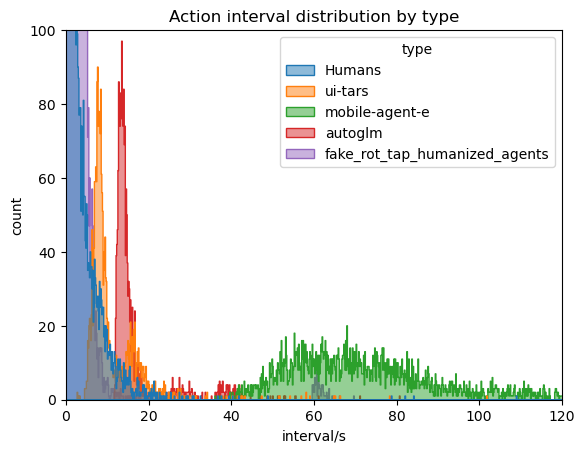

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


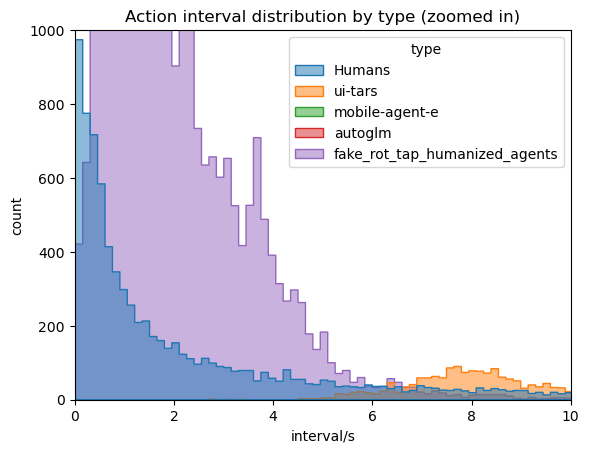

In [169]:
#cpm_gui_agent_list替换为AutoGLM，且把两张图分开显示
from typing import List, Tuple
from analysis.lib.motionevent_classes import FingerEvent
from analysis.processing.interval_extract import build_intervals_dataframe
from analysis.lib.gesture_log_reader_utils import ranged_batched_modified_generator_with_session_timestamp
from analysis.lib.motionevent_classes import SessionType
import seaborn as sns
def execute_interval_of_participants():
    ui_tars_list = ['ui-tars no humanity', 'ui-tars available humanity']
    
    all_agents_list = non_humanized_agents + humanized_agents
    mobile_agent_e_list = [
        'Mobile-agent-e gpt-4o available humanity',
        'Mobile-agent-e claude-sonnet-3.7 available humanity',
        'gpt4o no humanity',
        'claude no humanity',
    ]
    cpm_gui_agent_list = ['open_autoglm_agent_raw']

    ranged_raw_generator_with_session_timestamp:  Callable[[List[str], Optional[List[int]], Optional[Callable[[List[FingerEvent]], List[FingerEvent]]]], List[SessionType]] = partial(ranged_batched_modified_generator_with_session_timestamp, formated_data_timestamps=formated_data_timestamps, batched_filtering_and_modification_function=None)

    generator_list: List[Tuple[str, List[SessionType]]] = [
        ("Humans", ranged_raw_generator_with_session_timestamp(participants=humans)),
        # ("ui_tars_no_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[0]])), ("ui_tars_available_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[1]])),
        ("ui-tars", ranged_raw_generator_with_session_timestamp(participants=ui_tars_list)),
        ("mobile-agent-e", ranged_raw_generator_with_session_timestamp(participants=mobile_agent_e_list)),
        ("autoglm", ranged_raw_generator_with_session_timestamp(participants=cpm_gui_agent_list)),
        ("fake_rot_tap_humanized_agents", ranged_raw_generator_with_session_timestamp(participants=fake_rot_tap_humanized_agents)),
    ]
    duration_df = build_intervals_dataframe(generator_list)
    if True:
        duration_df["interval_us"] /= 1e6

    import matplotlib.pyplot as plt
    
    # 第一张图（跟论文Figure 3a对应）
    plt.figure()
    ax = sns.histplot(data=duration_df, x="interval_us", hue="type", bins=5000, element="step", alpha=0.5)
    ax.set_xlabel("interval/s")
    ax.set_ylabel("count")
    ax.set_title("Action interval distribution by type")
    ax.set_ylim(None, 100)
    ax.set_xlim(0, 120)
    plt.show()

    # 第二张图（zoom in版本）
    plt.figure()
    ax2 = sns.histplot(data=duration_df, x="interval_us", hue="type", bins=5000, element="step", alpha=0.5)
    ax2.set_xlabel("interval/s")
    ax2.set_ylabel("count")
    ax2.set_title("Action interval distribution by type (zoomed in)")
    ax2.set_ylim(None, 1000)
    ax2.set_xlim(0, 10)
    plt.show()


execute_interval_of_participants()

### Plot fake effect

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191019.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191303.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_194143.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

Kept 4 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_220331.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_031311.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 5 samples in the generated trace.
Incomplete sampl

Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_005538.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 38. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_011632.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 7. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_012902.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may

Kept 757 complete samples from all 758 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_031111.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 721 complete samples from all 722 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_034233.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 746 complete samples from all 747 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_rec

Kept 731 complete samples from all 732 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_082958.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 731 complete samples from all 732 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_090118.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 437 complete samples from all 438 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_rec

Kept 476 complete samples from all 477 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_133011.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_133413.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 144 complete samples from all 145 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_134151.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 359 complete samples from all 360 samples in the generated trace.
Incomplete sa

Kept 668 complete samples from all 669 samples in the generated trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_201959.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_201959.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 83 complete samples from all 84 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recordi

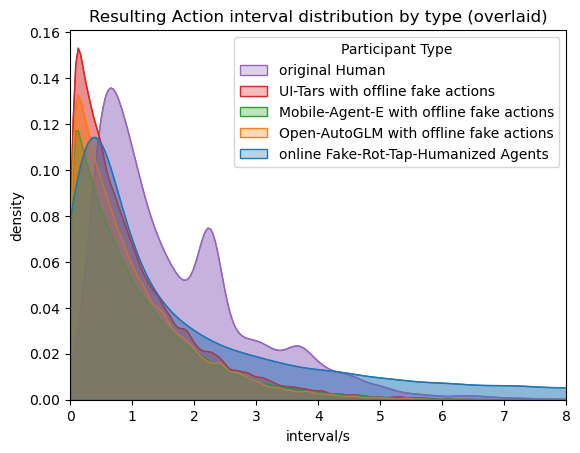

In [172]:
from typing import List, Tuple
from analysis.lib.motionevent_classes import FingerEvent
from analysis.processing.interval_extract import build_intervals_dataframe, faking_intervals_between_gestures
import seaborn as sns

from analysis.lib.gesture_log_reader_utils import ranged_batched_modified_generator_with_session_timestamp

def execute_faked_interval_of_participants():
    fake_ranged_generator: Callable[[List[str], Optional[List[int]], Optional[Callable[[List[FingerEvent]], List[FingerEvent]]]], List[SessionType]] = partial(
        ranged_batched_modified_generator_with_session_timestamp,
        formated_data_timestamps=formated_data_timestamps,
        batched_filtering_and_modification_function=partial(
            faking_intervals_between_gestures,
            target_expected_interval_us=int(1e6 * 1.1),
        )
    )

    ui_tars_list = ['ui-tars no humanity', 'ui-tars available humanity']
    
    all_agents_list = non_humanized_agents + humanized_agents
    mobile_agent_e_list = [
        'Mobile-agent-e gpt-4o available humanity',
        'Mobile-agent-e claude-sonnet-3.7 available humanity',
        'gpt4o no humanity',
        'claude no humanity',
    ]
    cpm_gui_agent_list = ['open_autoglm_agent_raw']

    ranged_raw_generator_with_session_timestamp:  Callable[[List[str], Optional[List[int]], Optional[Callable[[List[FingerEvent]], List[FingerEvent]]]], List[SessionType]] = partial(ranged_batched_modified_generator_with_session_timestamp, formated_data_timestamps=formated_data_timestamps, batched_filtering_and_modification_function=None)

    generator_list: List[Tuple[str, List[SessionType]]] = [
        ("Humans", ranged_raw_generator_with_session_timestamp(participants=humans)), # PASTBUG: wrote fake generator
        # ("ui_tars_no_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[0]])), ("ui_tars_available_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[1]])),
        ("ui-tars", fake_ranged_generator(participants=ui_tars_list)),
        ("mobile-agent-e", fake_ranged_generator(participants=mobile_agent_e_list)),
        ("autoglm", fake_ranged_generator(participants=cpm_gui_agent_list)),
        ("fake_rot_tap_humanized_agents", ranged_raw_generator_with_session_timestamp(participants=fake_rot_tap_humanized_agents)),
    ]
    """
        for name, gen in generator_list:
            print(f"Generator {name} prepared. Length is {len(gen)}")
            for swipe in gen:
                print("asdf")
                print(swipe)
                print(swipe[:1], swipe[-1:])
        """
    duration_df = build_intervals_dataframe(generator_list)
    duration_df["interval_us"] /= 1e6
    weights = {
    "Humans": 50, 
    "ui-tars": 10,
    "mobile-agent-e": 1,
    "autoglm": 10,
    "fake_rot_tap_humanized_agents": 10,
}
    rename_labels = {
    "Humans": "original Human",
    "ui-tars": "UI-Tars with offline fake actions",
    "mobile-agent-e": "Mobile-Agent-E with offline fake actions",
    "autoglm": "Open-AutoGLM with offline fake actions",
    "fake_rot_tap_humanized_agents": "online Fake-Rot-Tap-Humanized Agents",
}

    ax = sns.kdeplot(data=duration_df, x="interval_us", hue="type", fill=True, alpha=0.3,
                 weights=duration_df["type"].apply(lambda t: weights.get(t, 1)),
                 bw_adjust=0.5, clip=(0, 8))
  
    ax.legend(title='Participant Type', 
              labels=[rename_labels.get(label.get_text(), label.get_text()) 
                      for label in ax.get_legend().get_texts()])
    ax.set_xlabel("interval/s")
    ax.set_ylabel("density")
    ax.set_title("Resulting Action interval distribution by type (overlaid)")
    ax.set_xlim(0, 8)

execute_faked_interval_of_participants()

### Calculate accuracy

Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_185438.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_161459.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_161718.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_161850.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_164345.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_164832.log, which is unexpected and currently not suppo

Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_021015.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 36. Discarding the last incomplete trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_153141.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 98 complete samples from all 99 samples in the generated trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_153644.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple un

Kept 743 complete samples from all 744 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_222101.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 63 complete samples from all 64 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_222530.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 60 complete samples from all 61 samples in the generated trace.


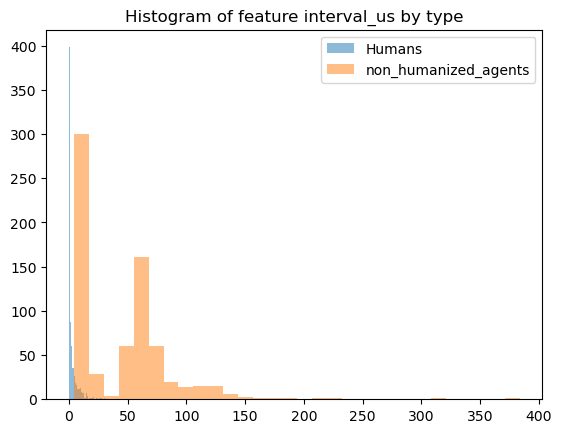

6.446943
-5.445768


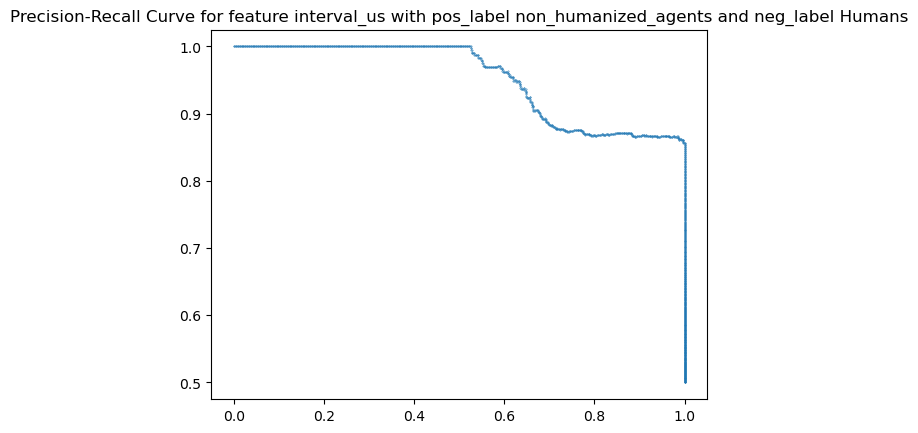

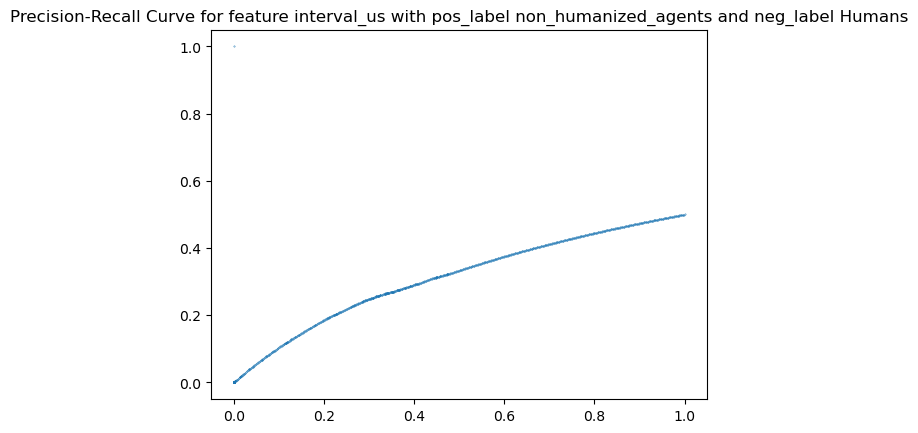

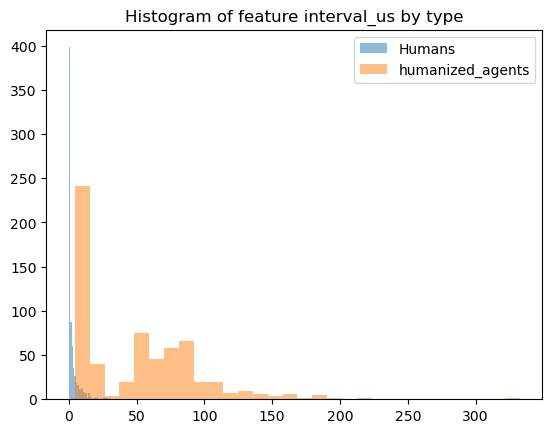

6.311961
-5.298519


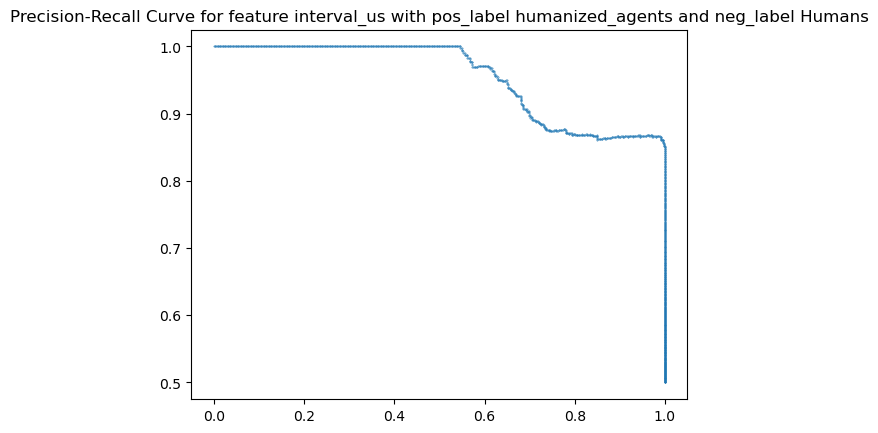

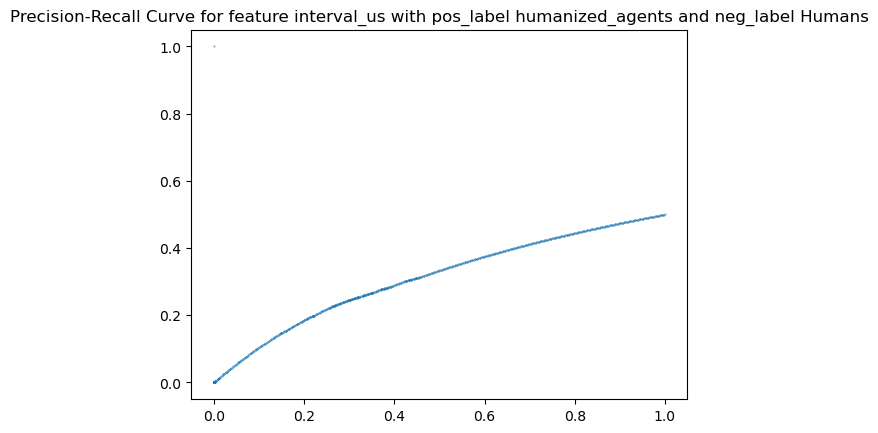

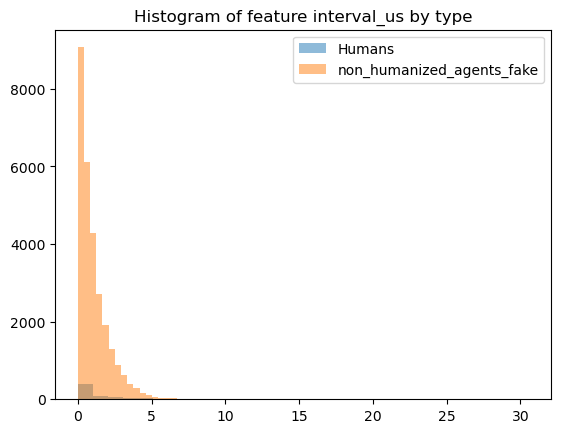

0.761681
0.23832699999999996


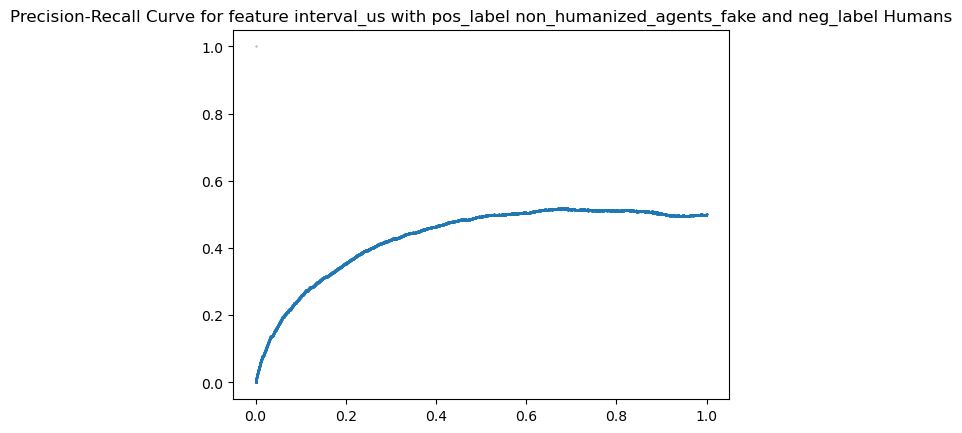

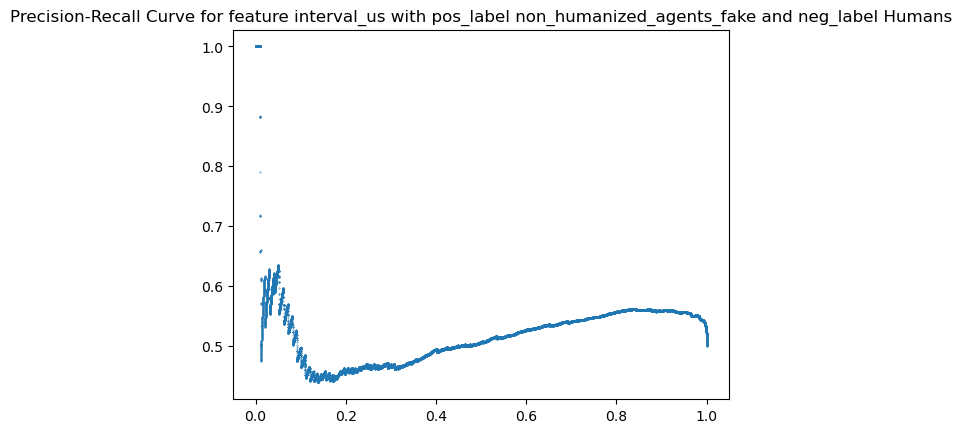

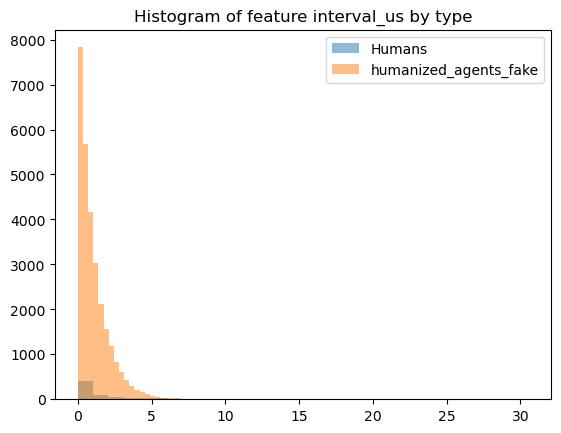

0.76843
0.23162000000000005


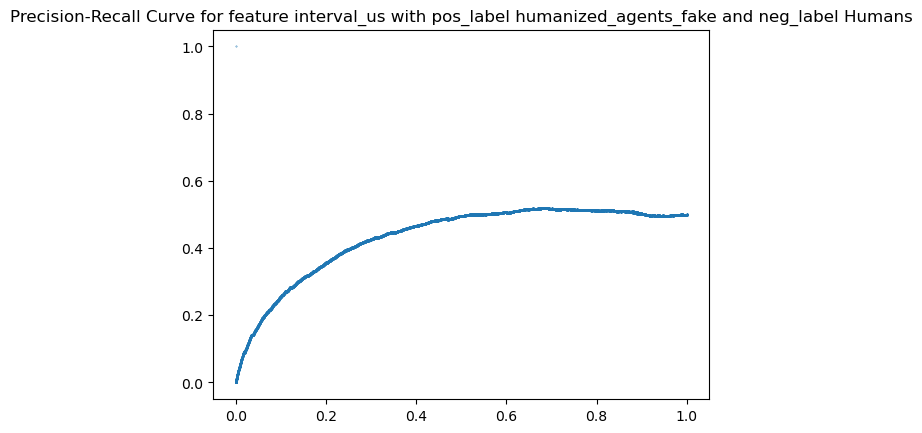

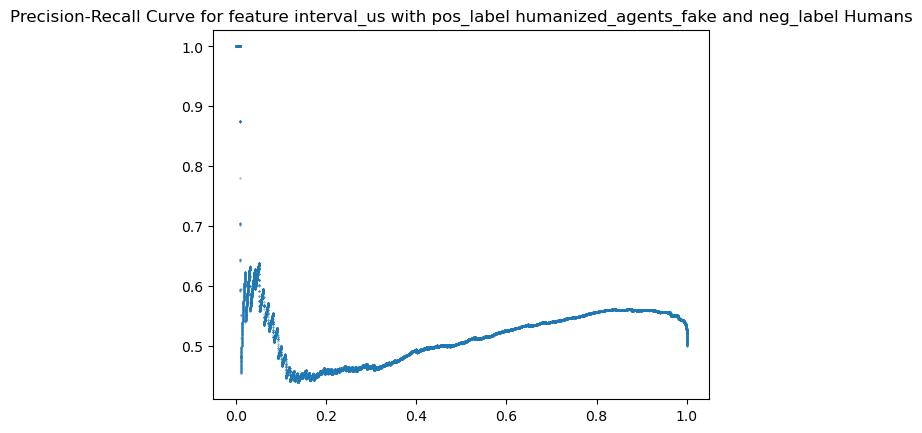

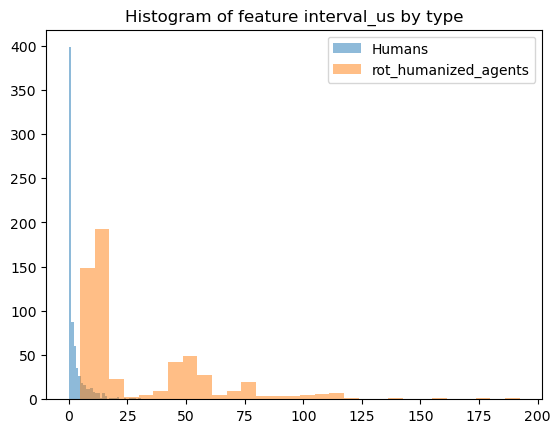

7.595761
-6.569705


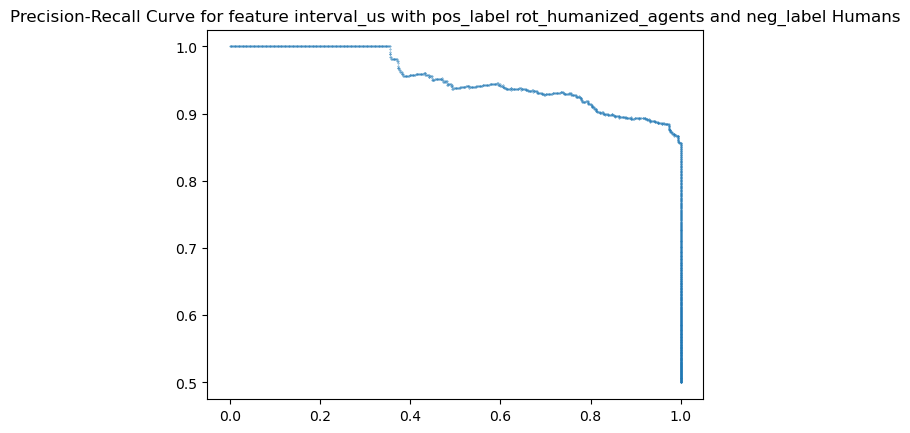

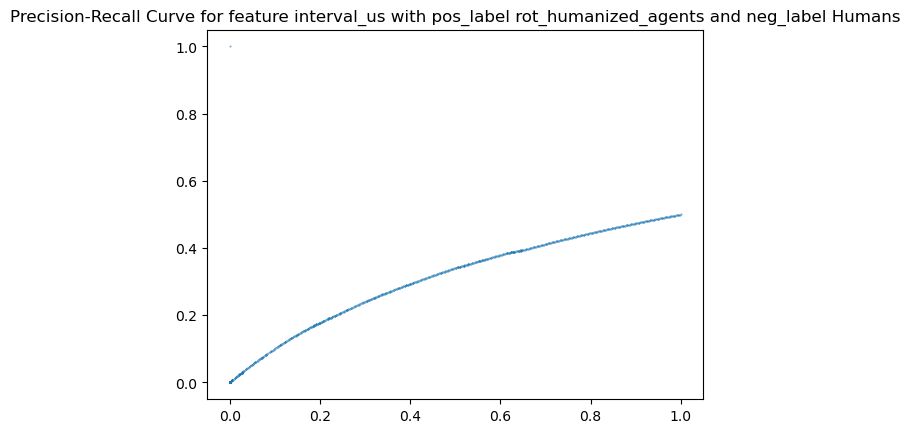

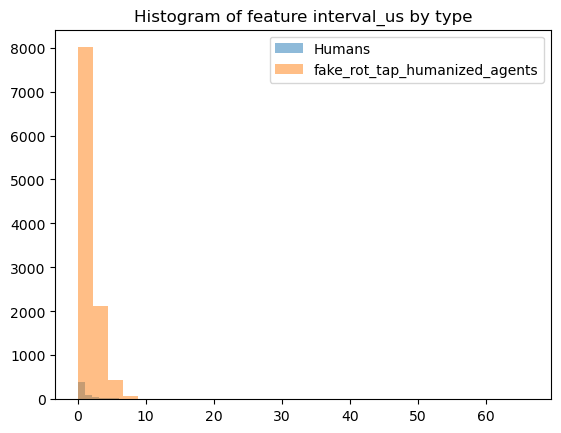

/var/folders/4q/gg2gsbgd2m71hq4w0lsncrym0000gn/T/ipykernel_16009/2549812472.py:107: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_interval = pd.concat([
SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004


1.108757
-0.10875600000000007


Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_175245.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file logs/gesture_recording_2025111x/gesture_recording_20251115_181528.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_114522.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_115003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_134628.log, which is unexpecte

Kept 3 complete samples from all 4 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260121_235020.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_211723.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 6. Discarding the last incomplete trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_224424.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 8. Discarding the last incomplete trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_232

Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_124704.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 81 complete samples from all 82 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_125121.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 100 complete samples from all 101 samples in the generated trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_125654.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplet

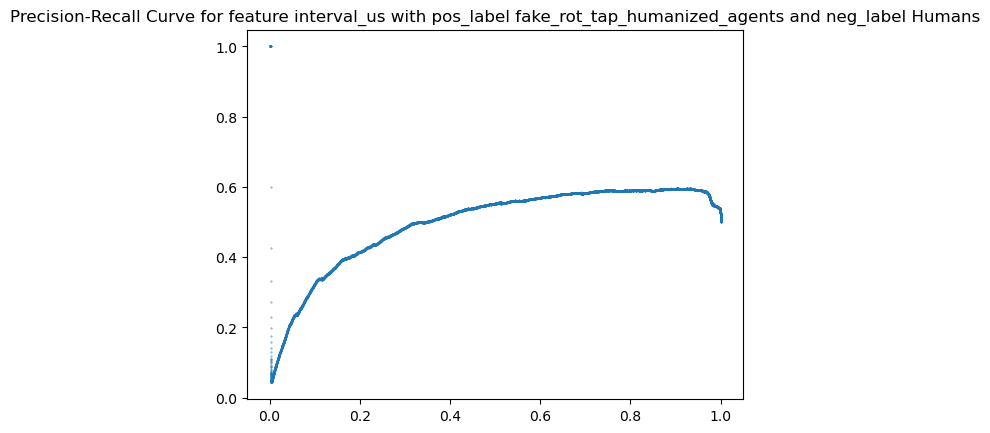

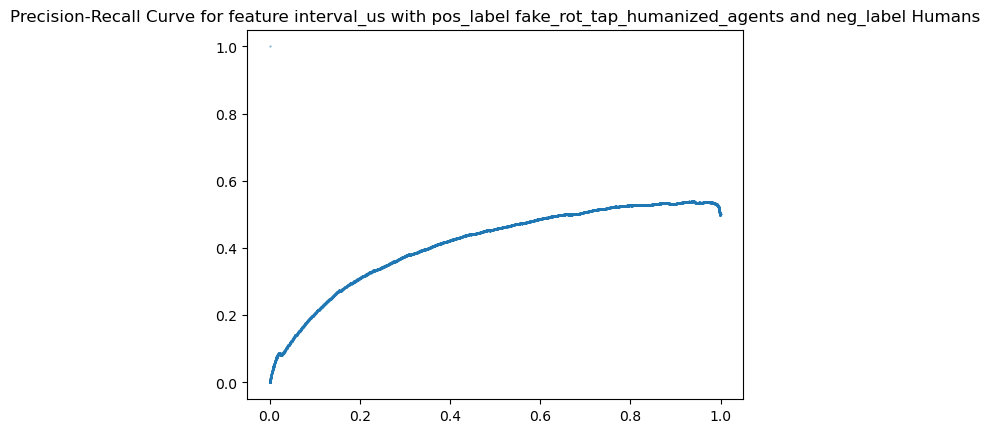

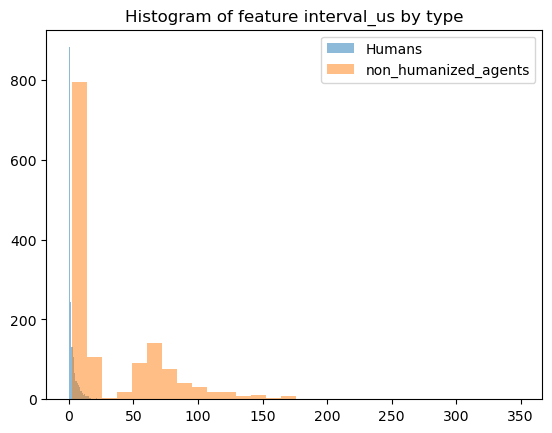

6.304088
-5.302938


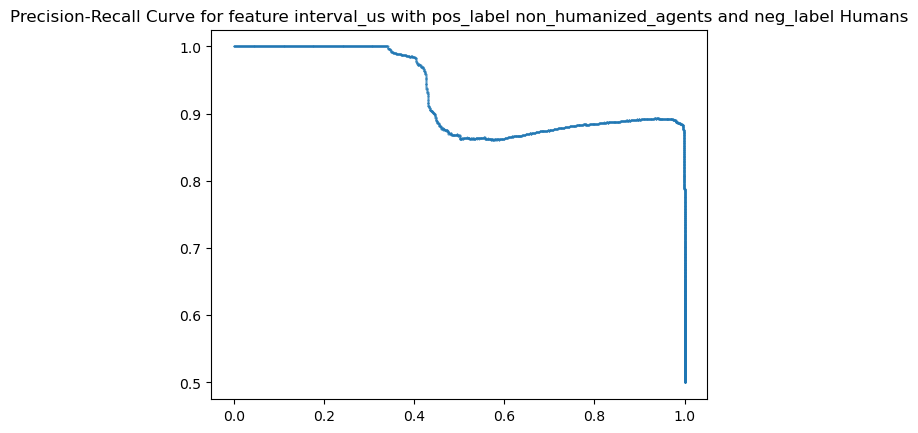

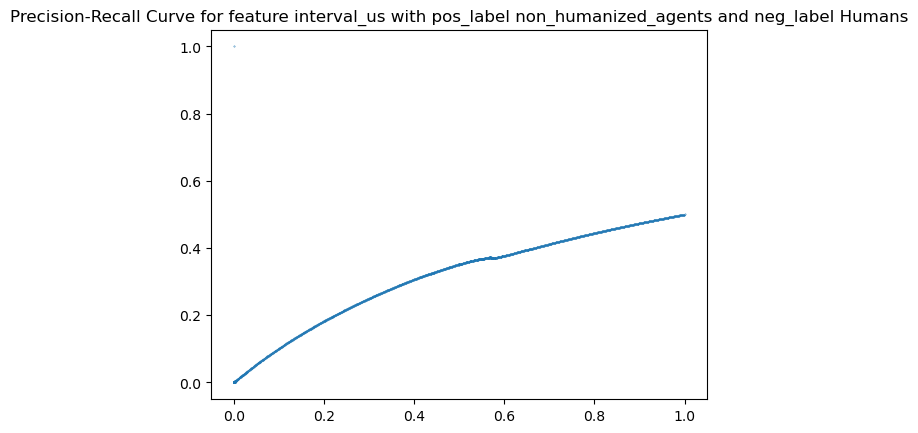

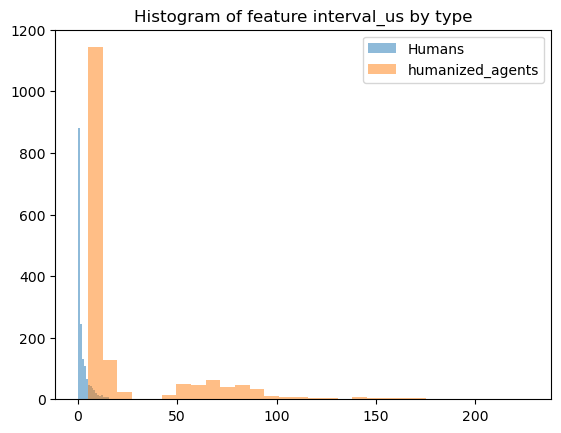

6.008676
-5.005307


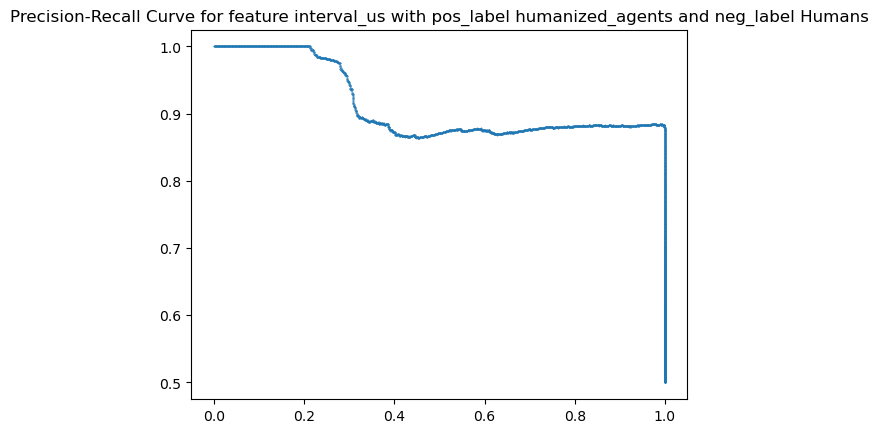

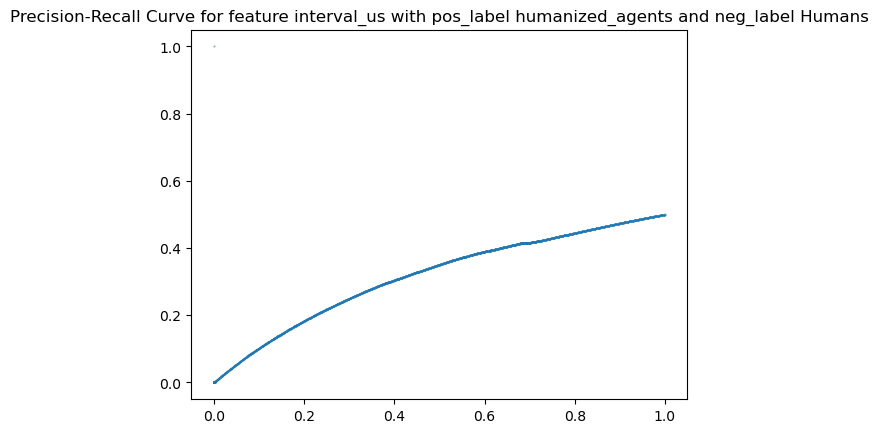

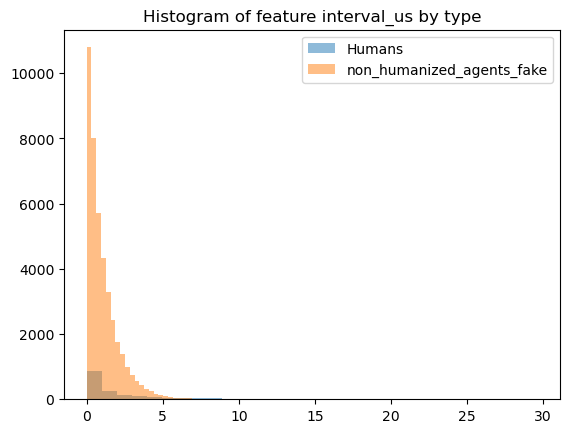

0.780376
0.21965900000000005


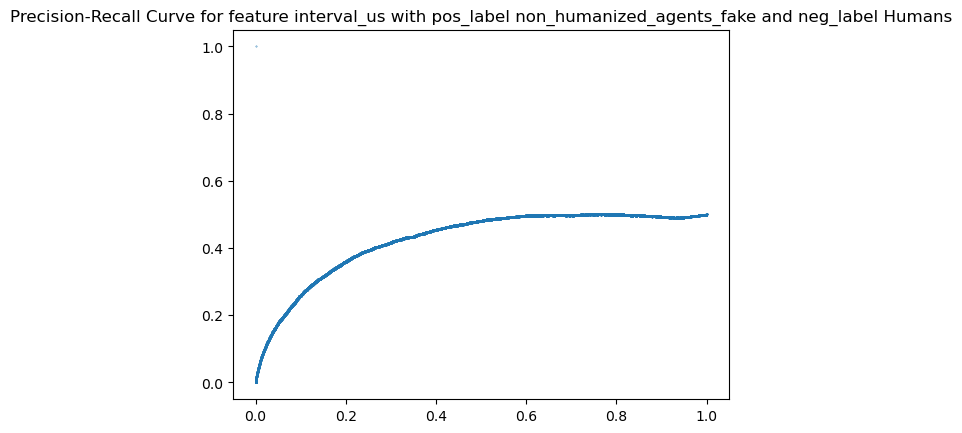

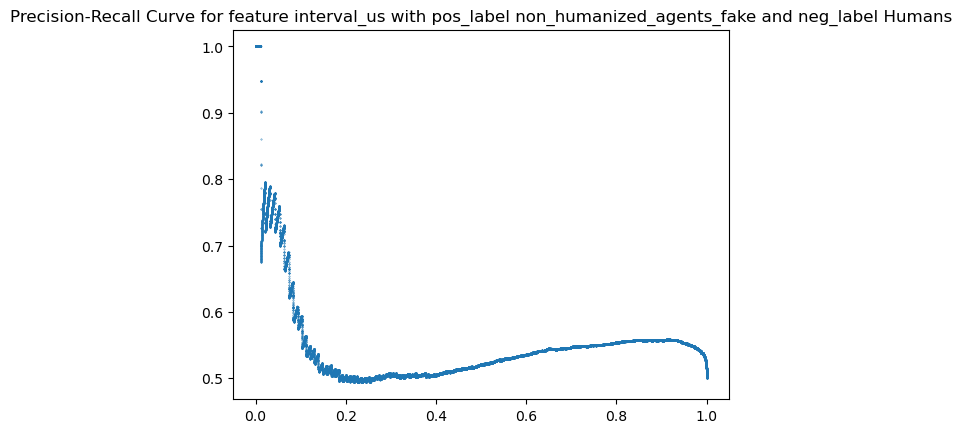

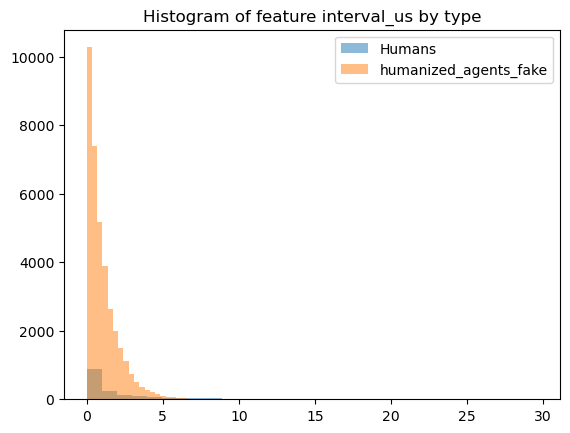

0.780263
0.219823


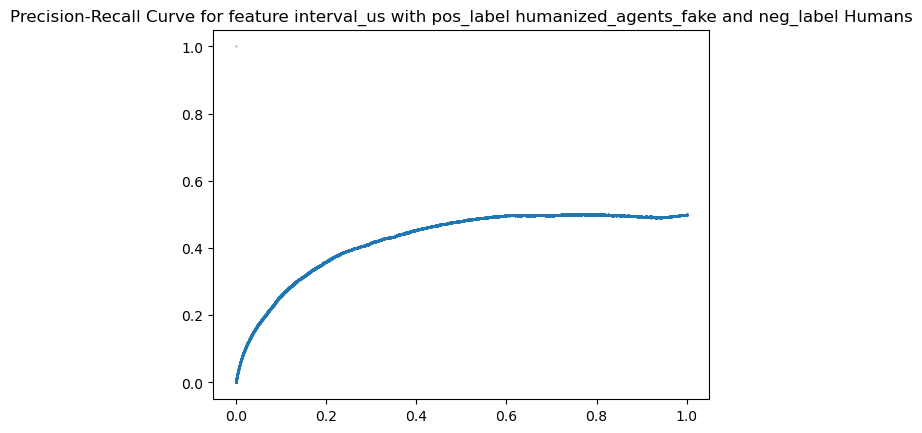

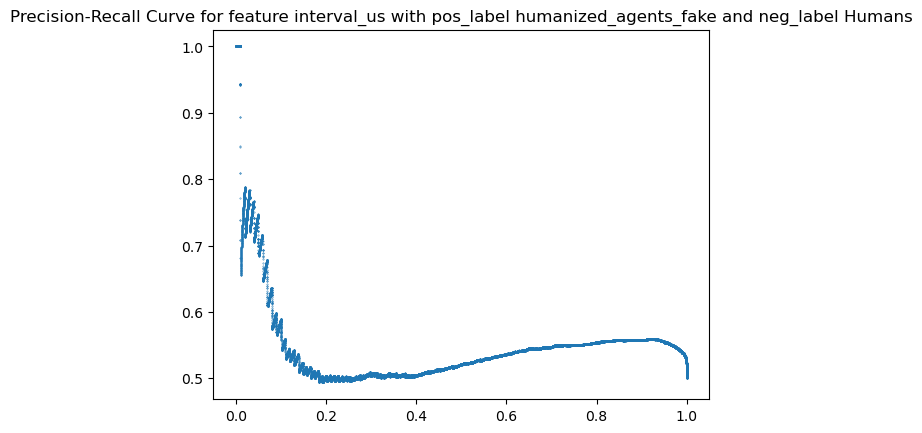

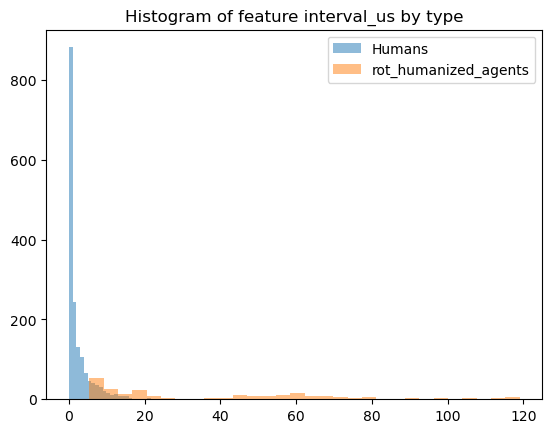

7.125525
-6.12399


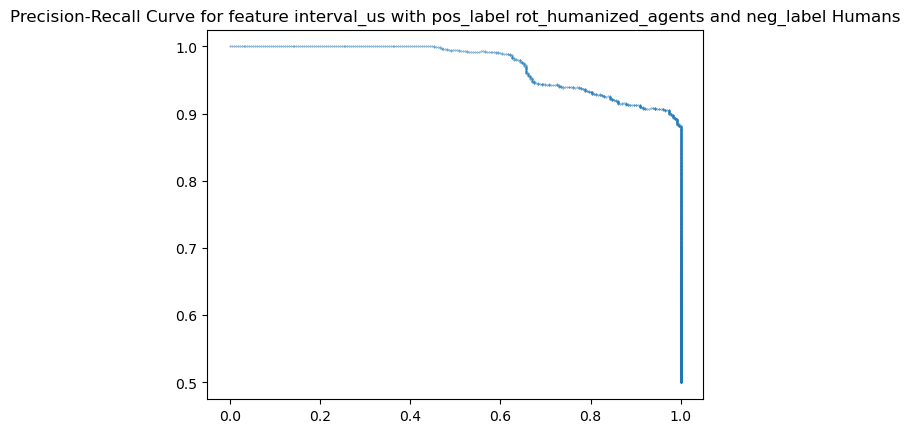

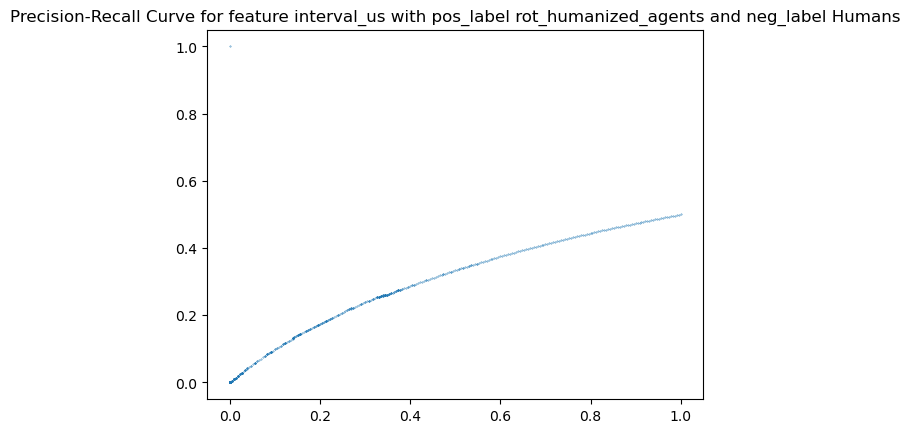

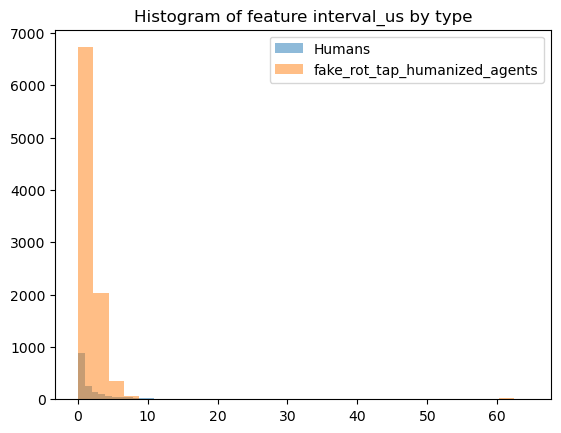

1.153149
-0.15314800000000006


Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_121655.log, which is unexpected and currently not supported. Skipping this file.
Error processing file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_121749.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 000006b9, len(current_gesture): 7. Discarding the last incomplete trace.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_122223.log, which is unexpected and currently not supported. Skipping this file.
Error processing file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_reco

Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260121_135445.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 4 complete samples from all 5 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260121_140429.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_205010.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 19 complete samples from all 20 samples in the generated trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gest

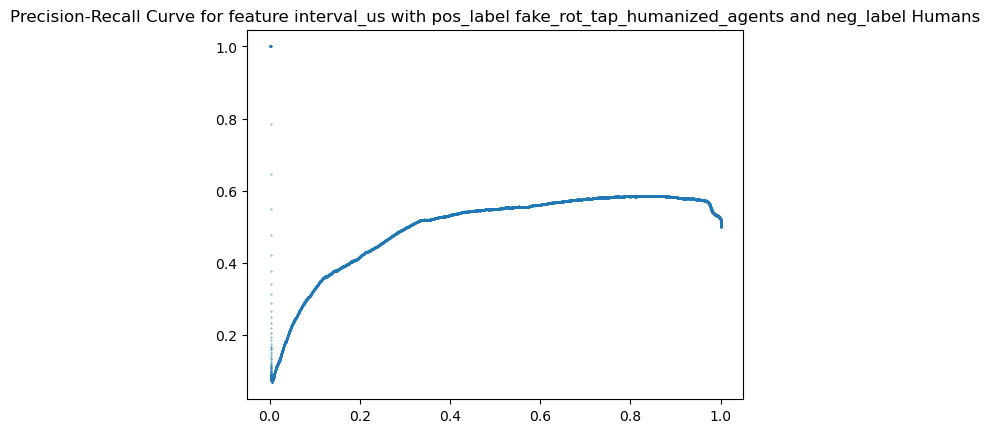

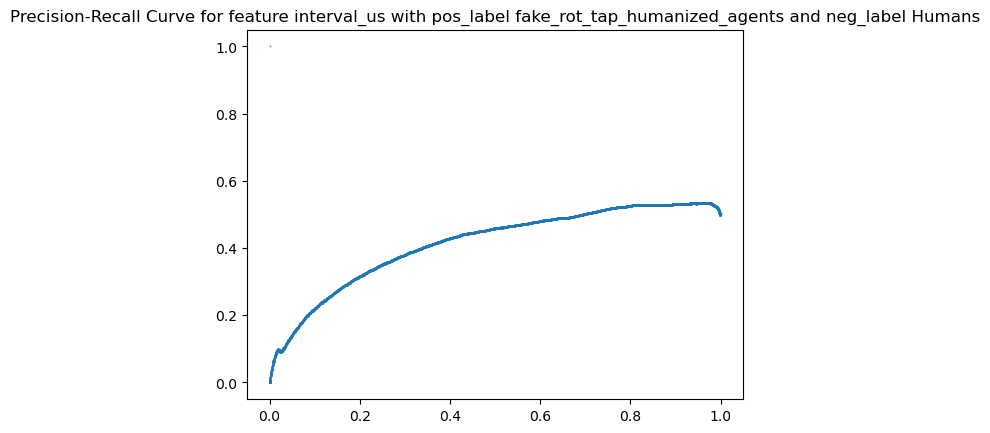

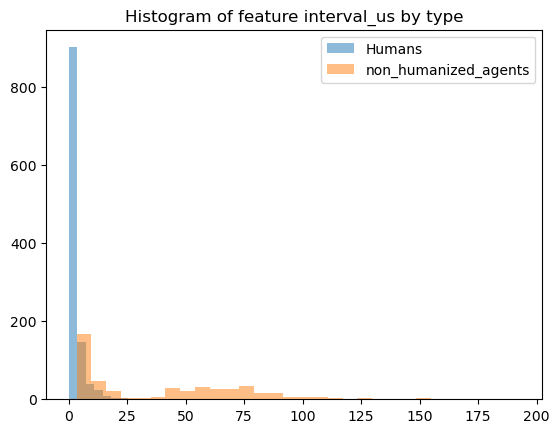

6.372562
-5.370479


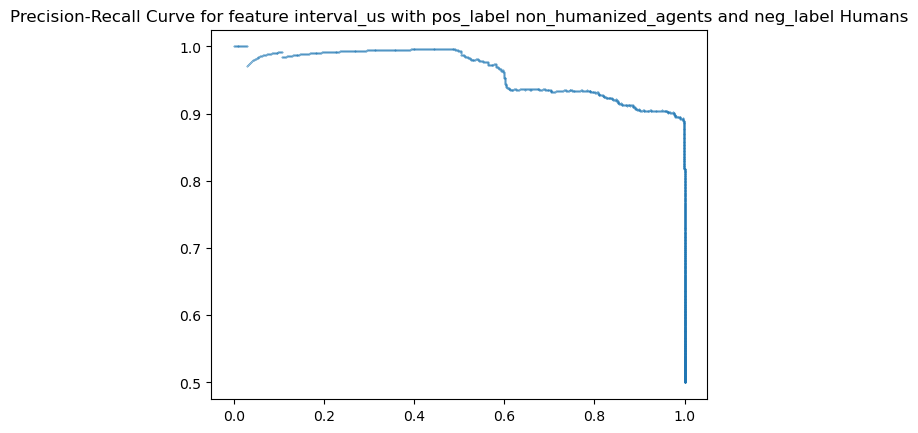

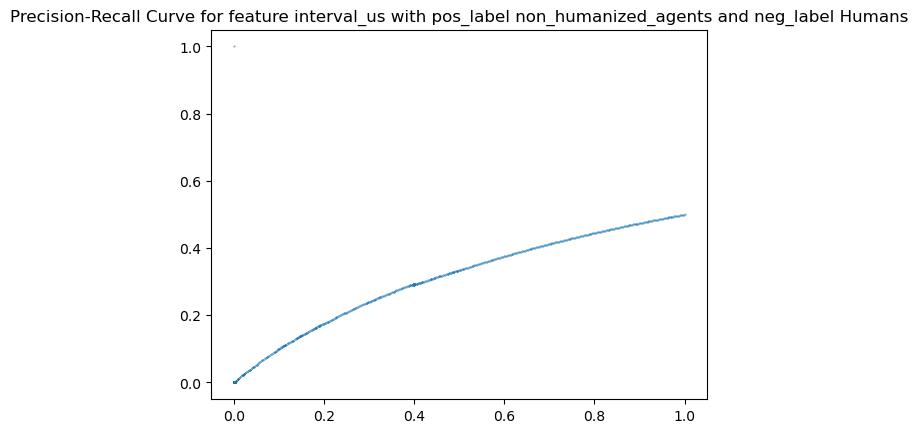

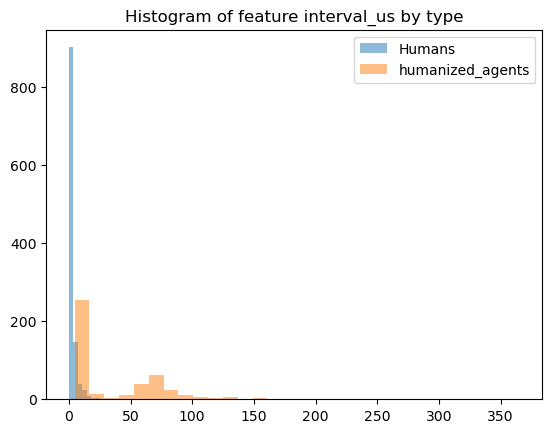

5.927296
-4.925934


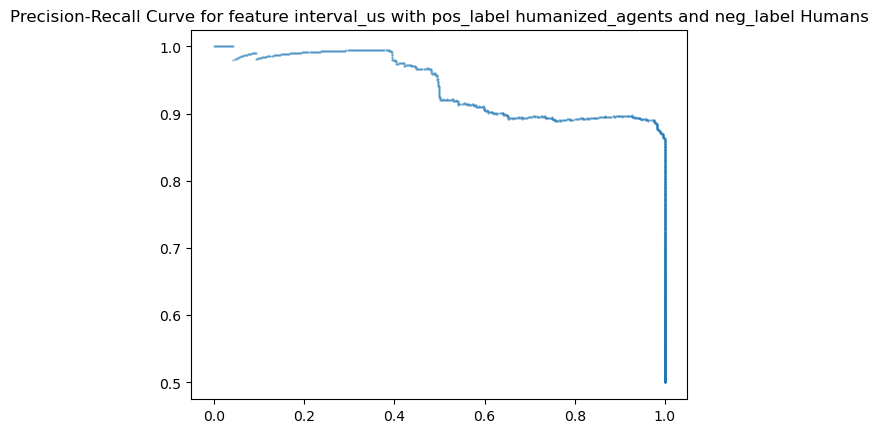

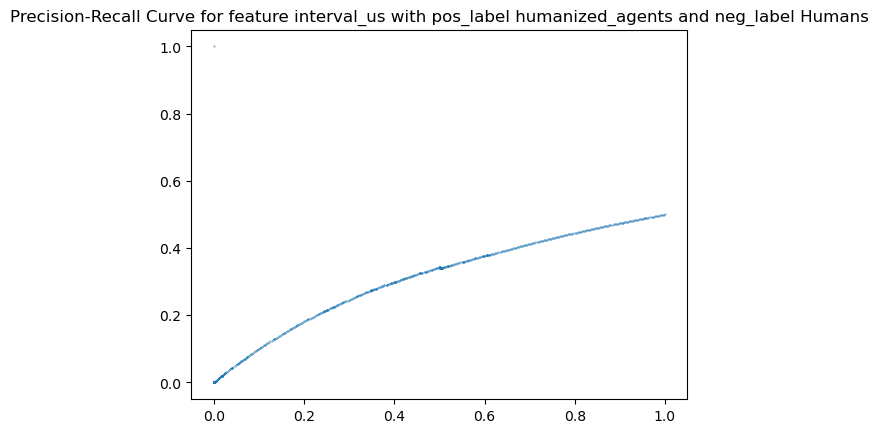

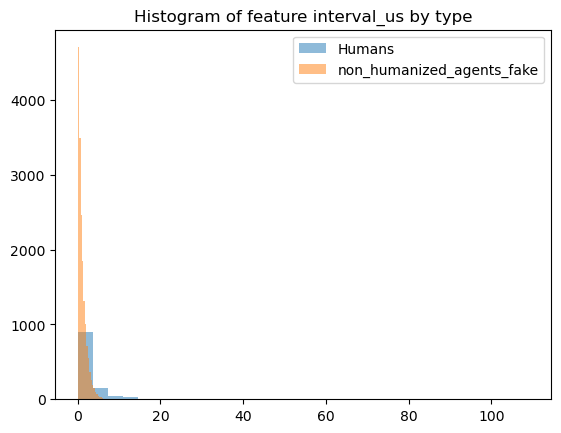

0.846845
0.15316300000000005


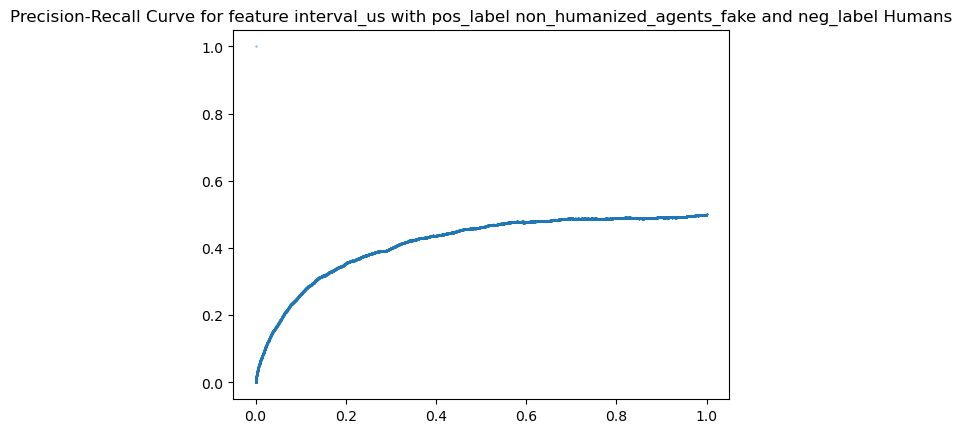

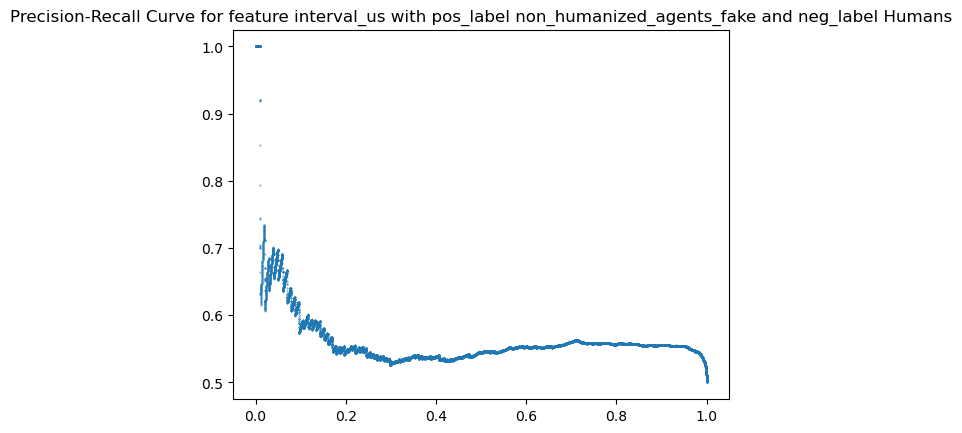

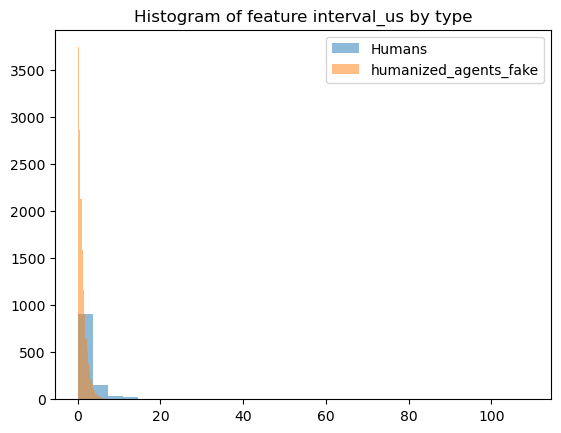

0.837542
0.162512


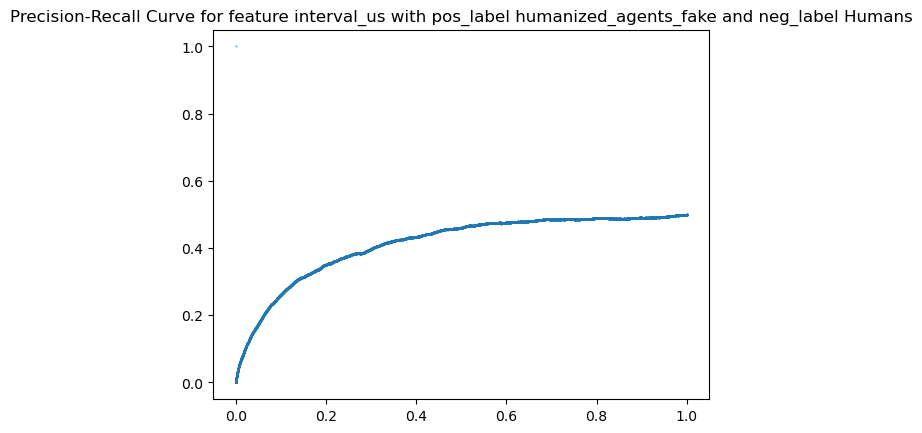

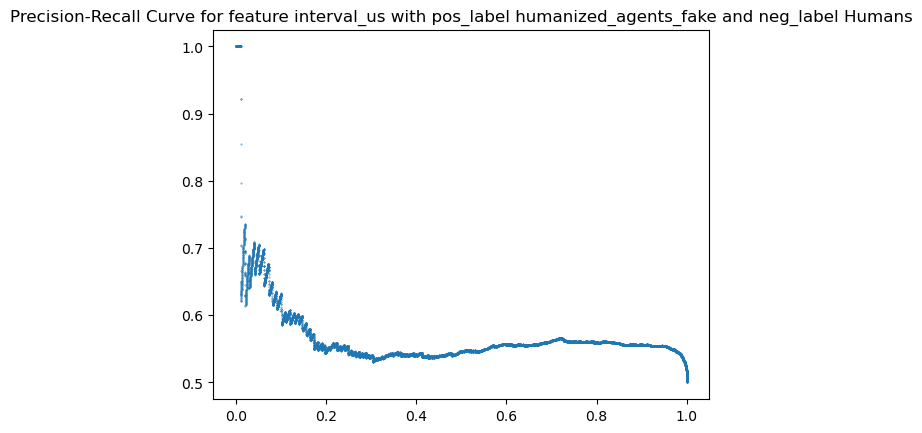

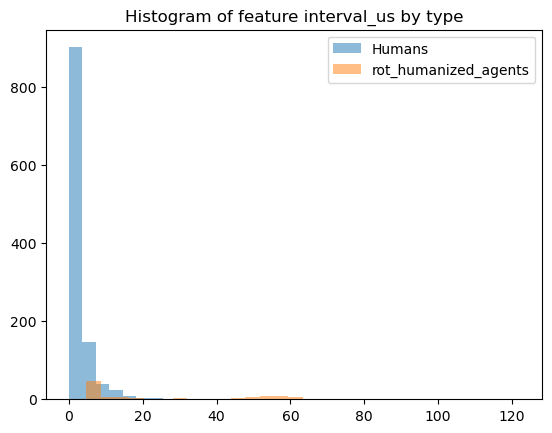

6.10661
-5.089151


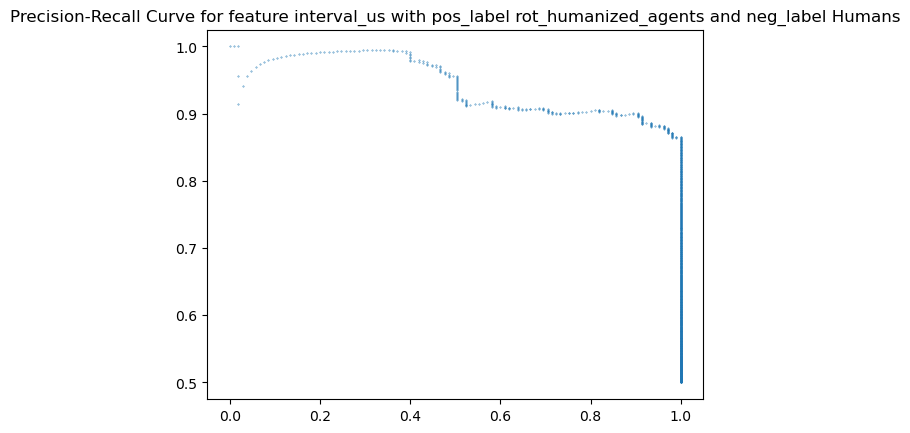

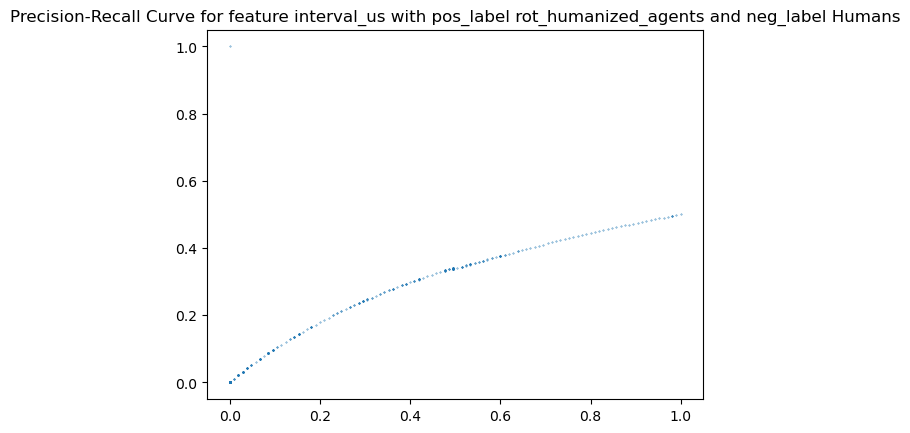

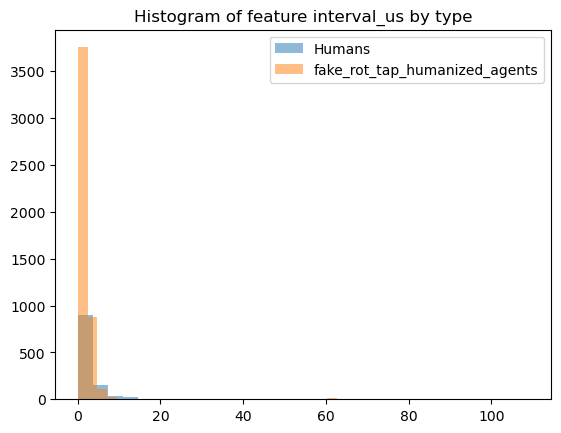

1.159495
-0.15938300000000005


Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_121239.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_135228.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_140248.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_141003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_142228.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_151402.log, 

Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_233627.log: Multiple Unexpected log format: log ended without proper termination and at least one incomplete sample detected. This may indicate missing lines or some other log format issue. Please check the logs for details. The generated trace may contain incomplete samples with None values and the last trace may be incomplete.. Multiple unexpected log format issues encountered.
Kept 3 complete samples from all 4 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_233627.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 3 complete samples from all 4 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_020851.log. This may indicate an unexpected log format or missing lin

Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_113845.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 532 complete samples from all 533 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_115944.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 53 complete samples from all 54 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_120302.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 787 complete samples from all 788 samples in the generated trace.


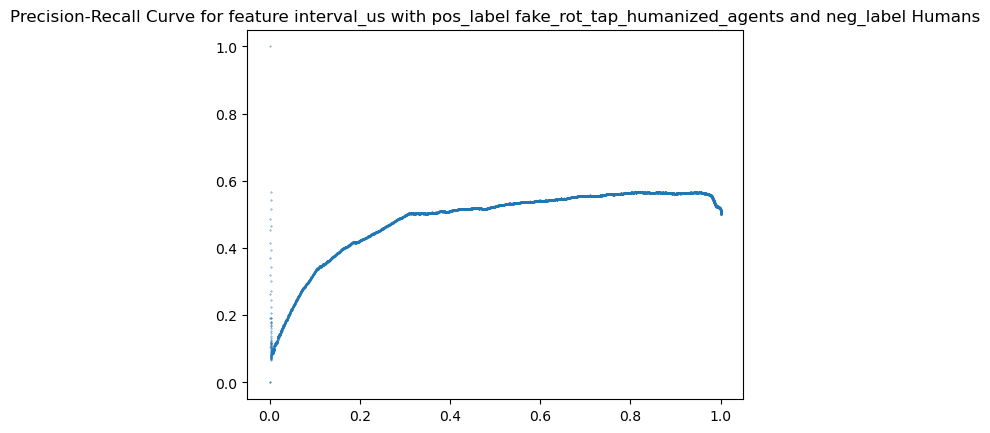

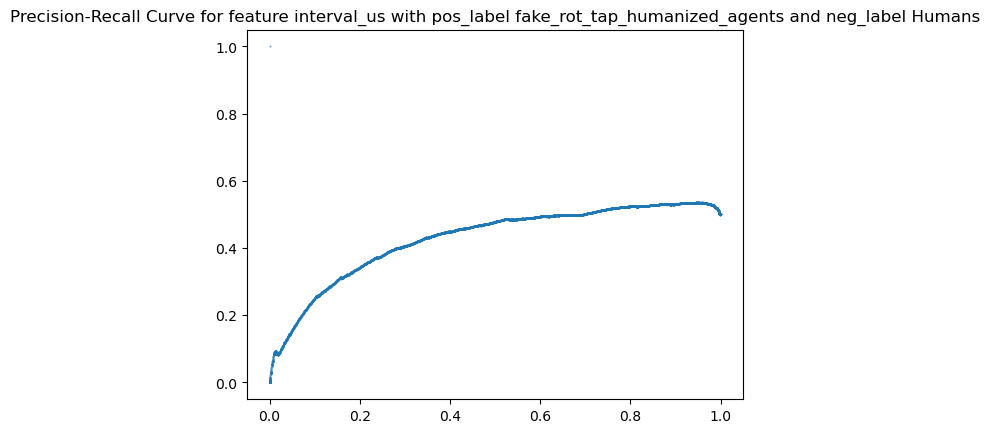

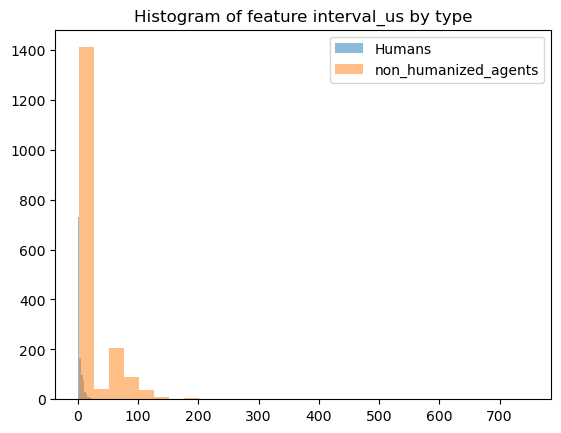

5.873154
-4.87272


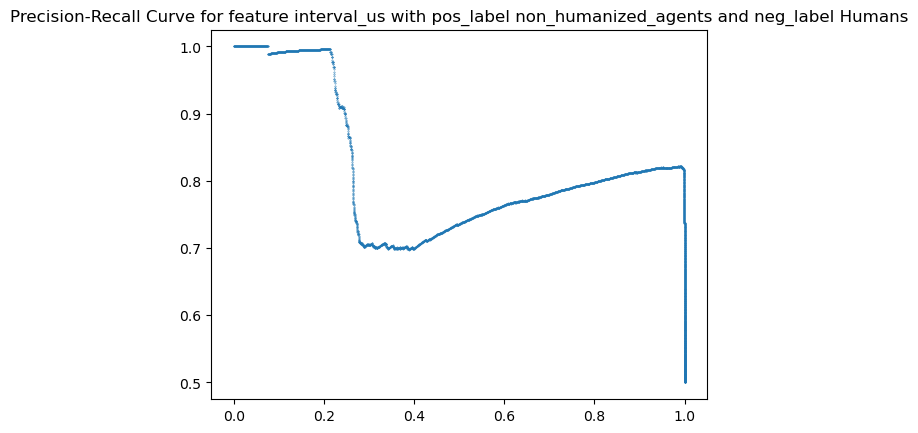

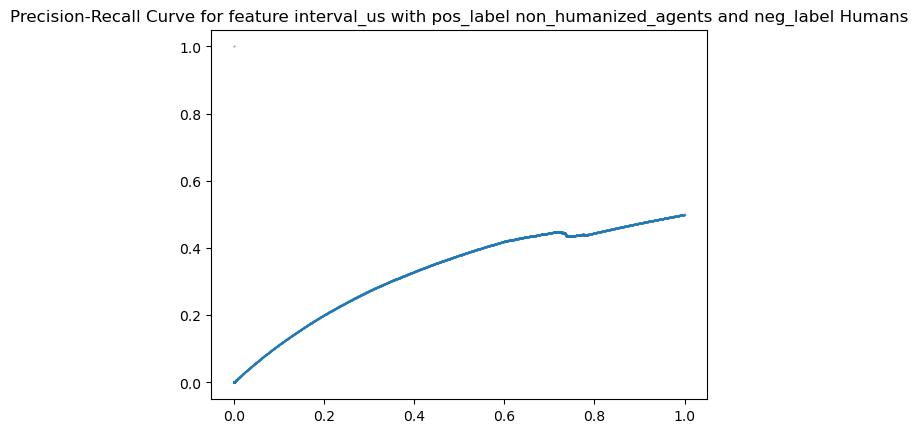

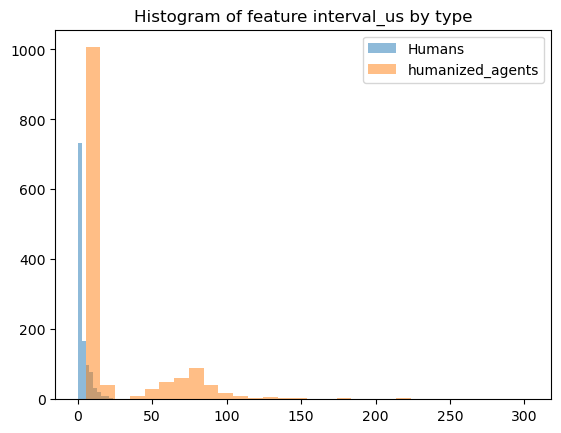

5.957152
-4.957115


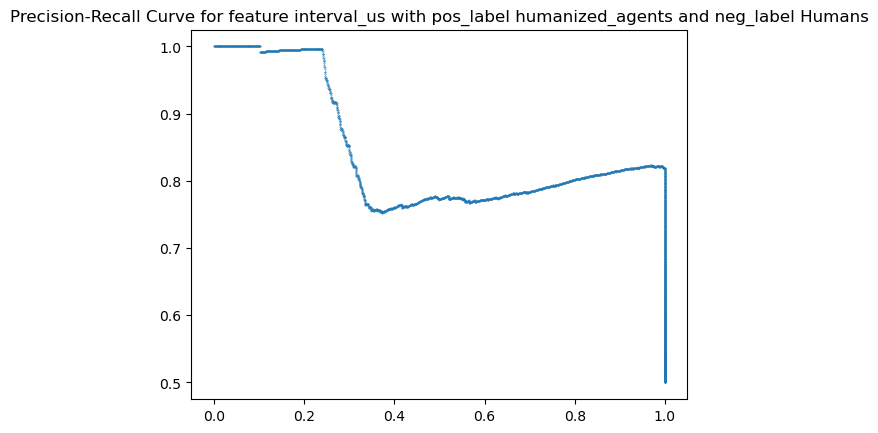

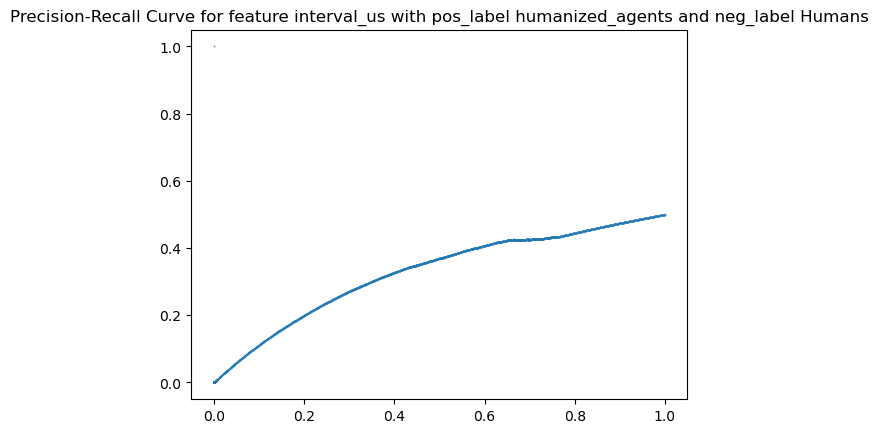

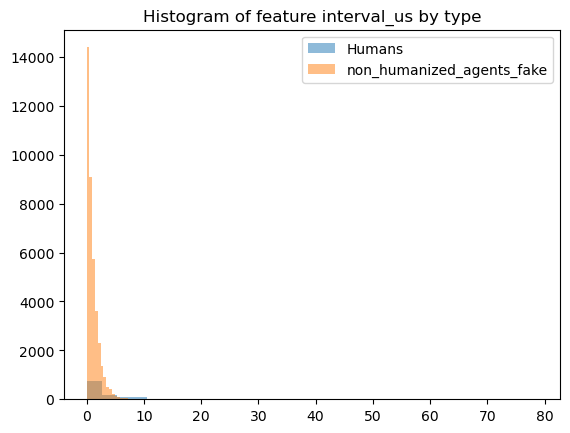

0.924554
0.07552199999999998


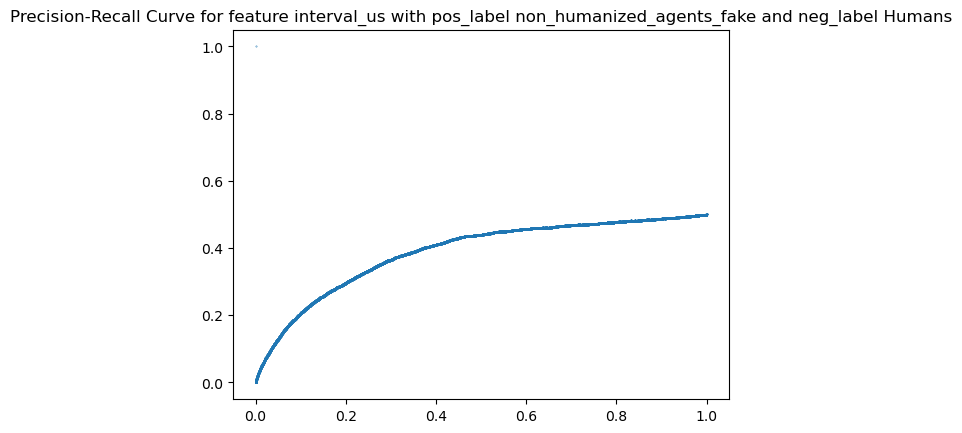

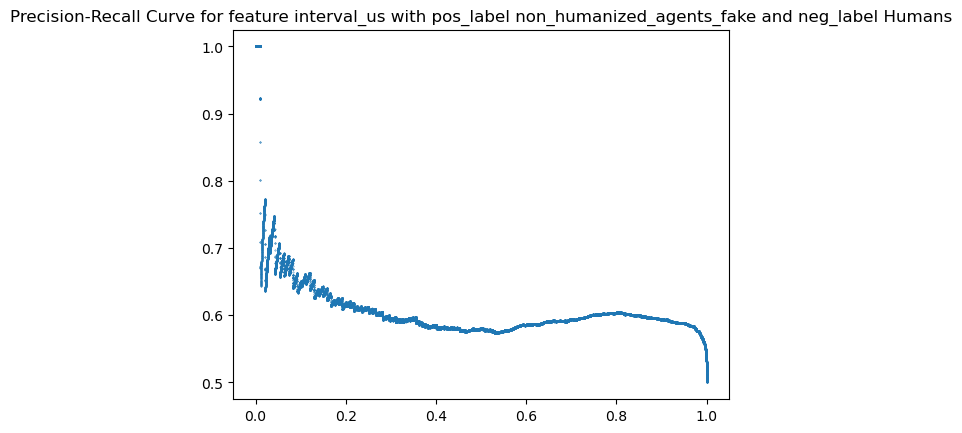

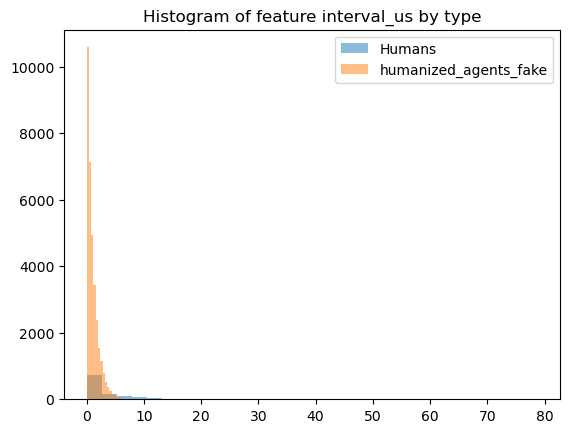

0.929444
0.07056700000000005


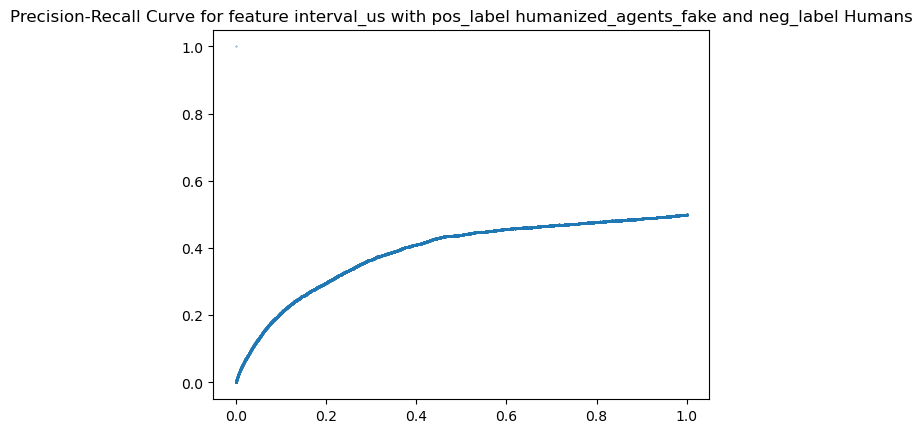

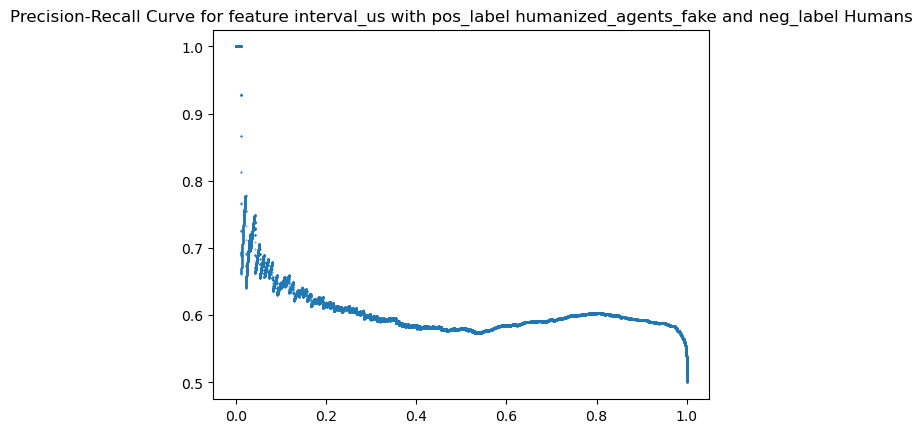

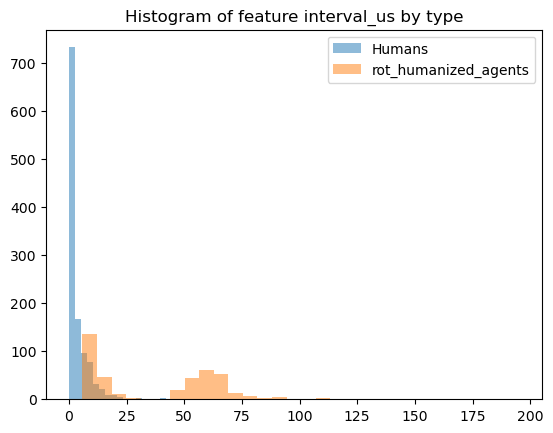

7.68862
-6.669009


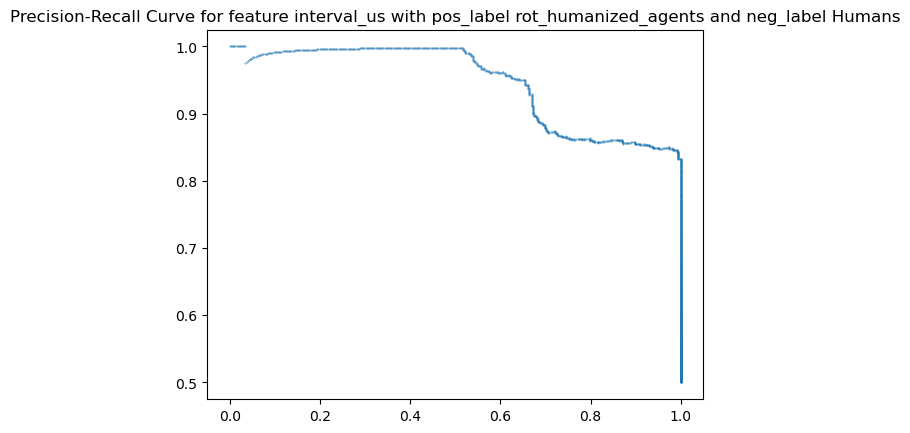

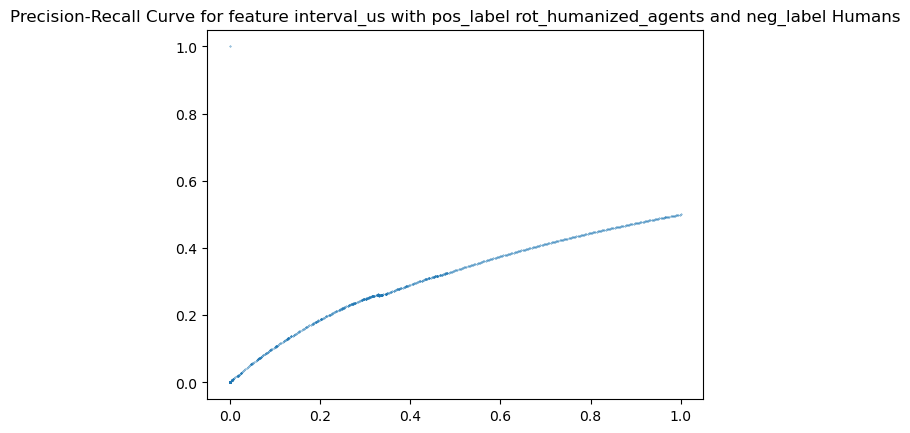

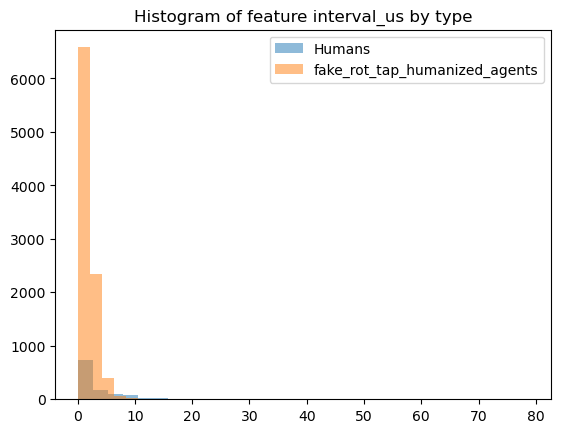

Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.


1.375197
-0.3745019999999999


Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_155555.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_155747.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260121_203545.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 9 complete samples from all 10 samples in the generated trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_223459.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 8. Discarding the last incomplete trace.
Error processing file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_002

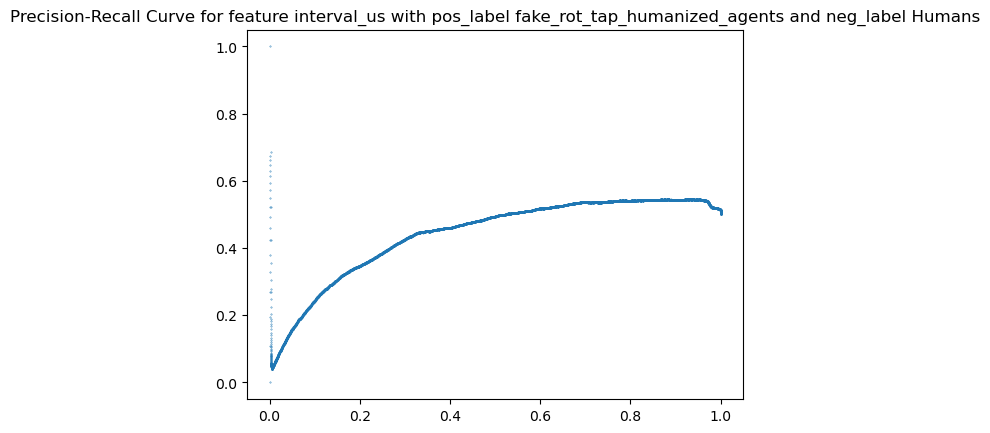

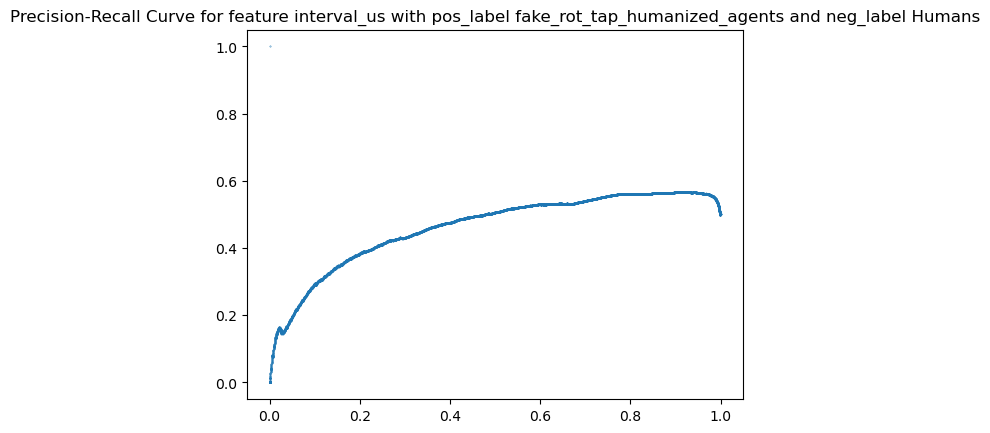

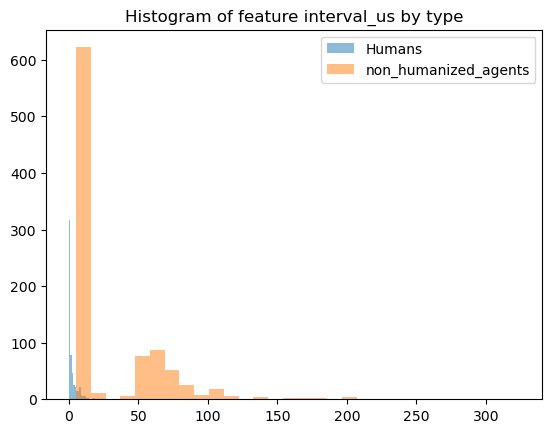

5.542215
-4.541314


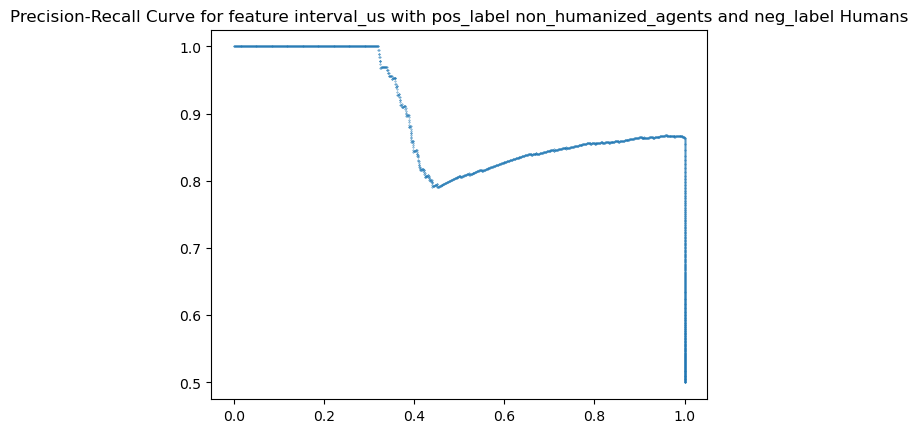

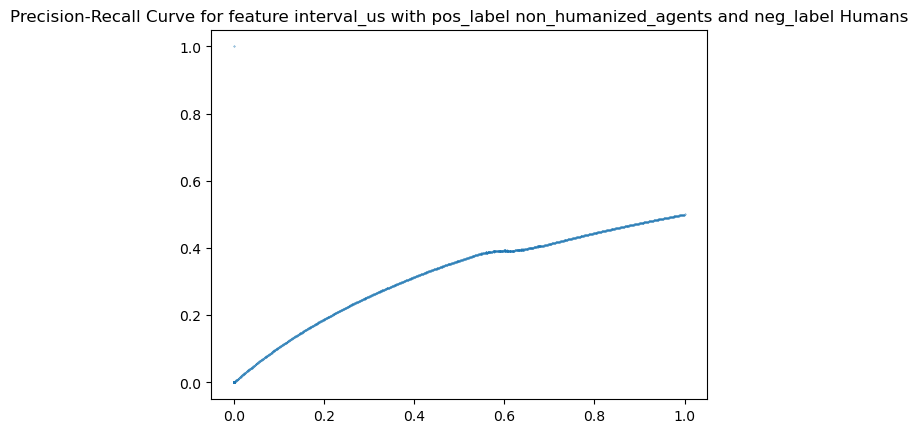

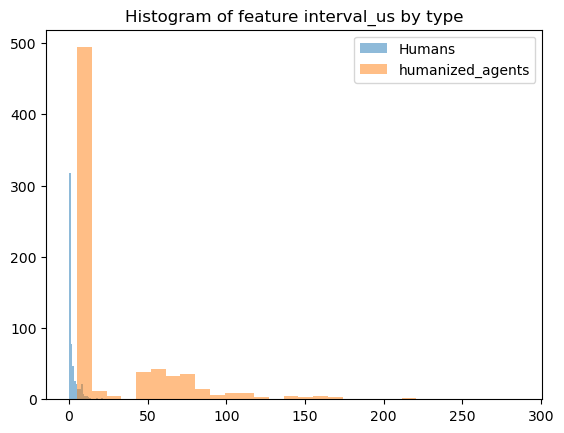

5.670071
-4.67002


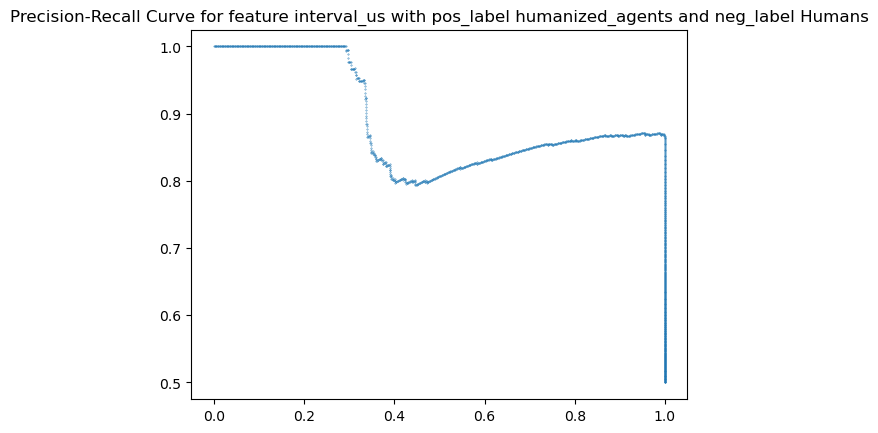

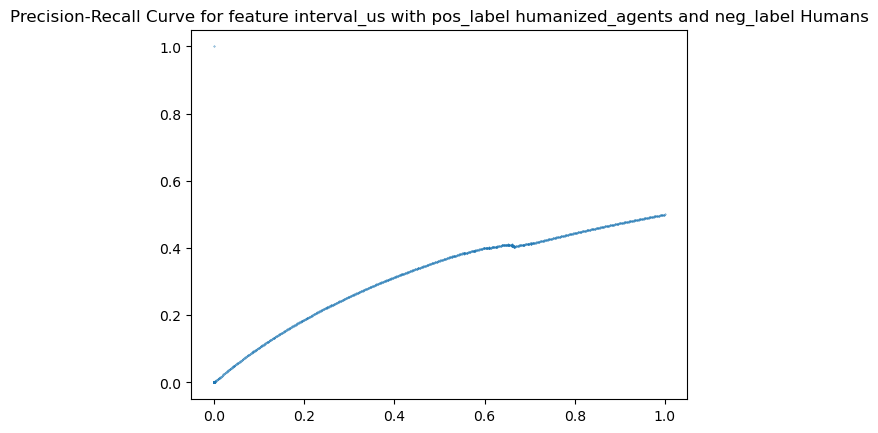

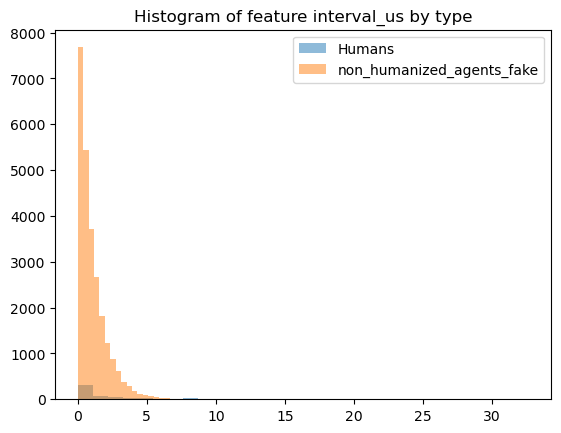

0.767939
0.232101


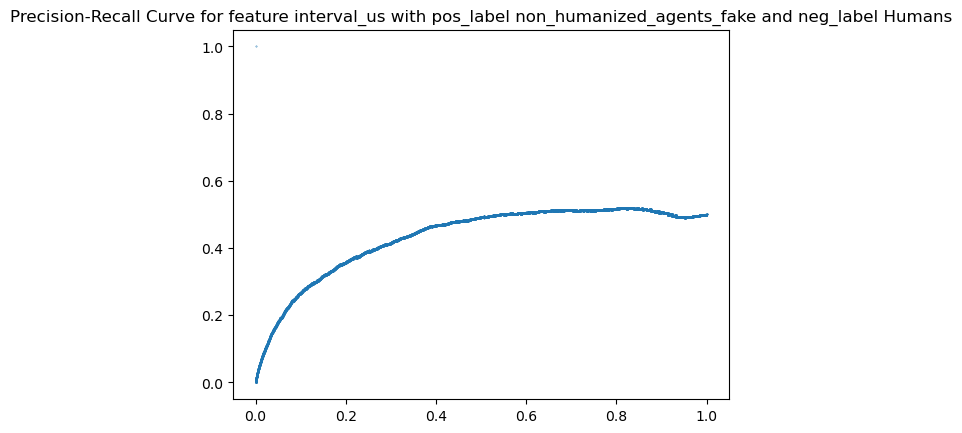

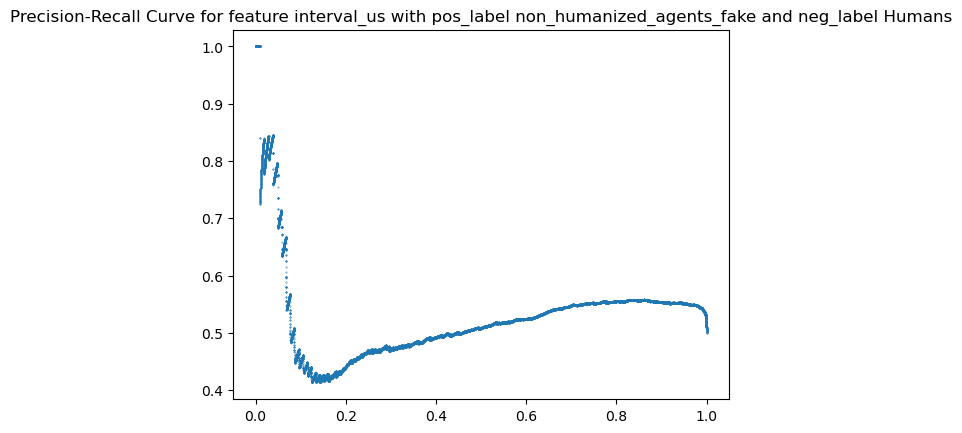

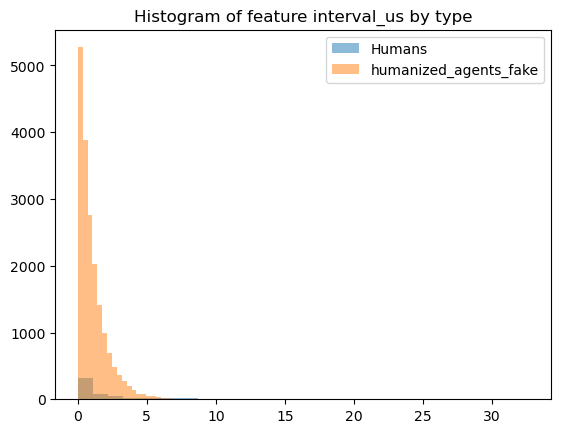

0.765561
0.23471799999999998


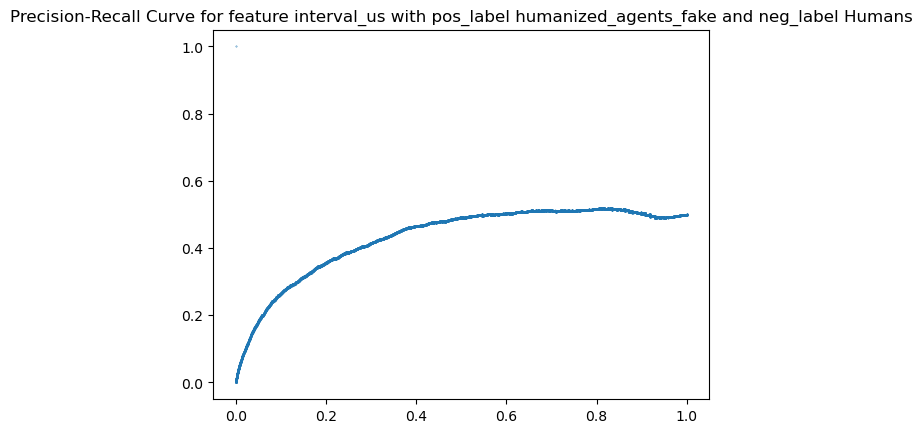

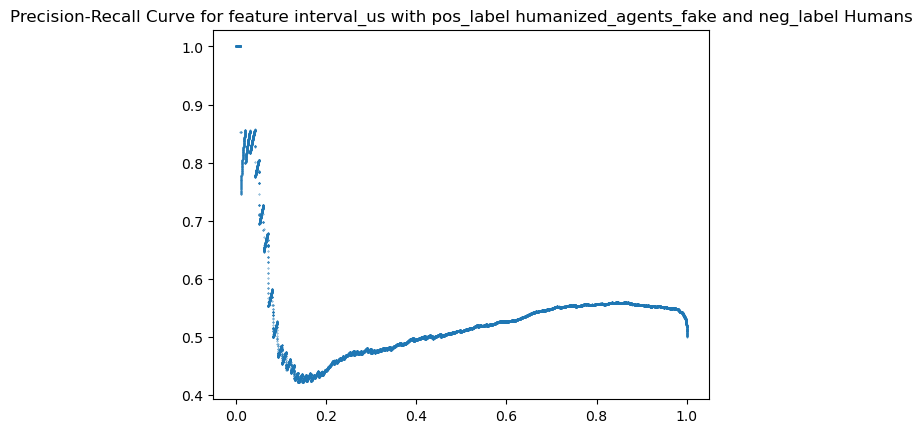

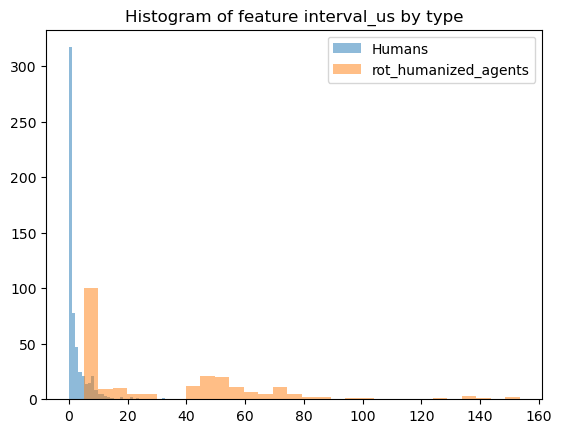

6.642696
-5.624616


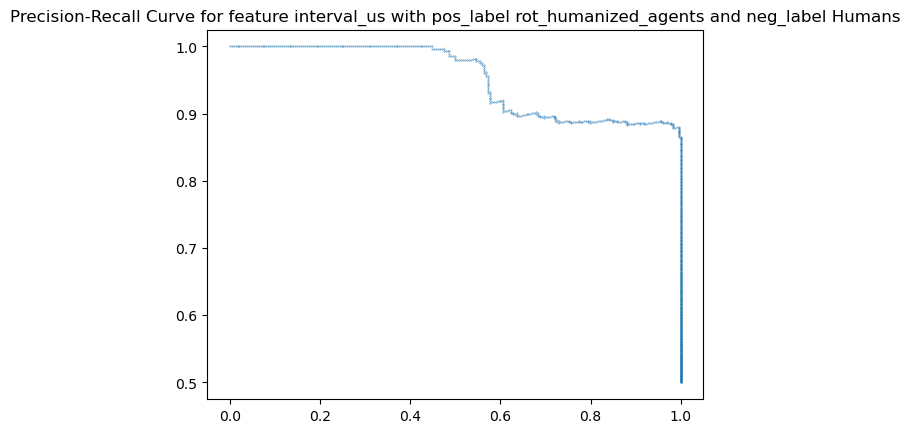

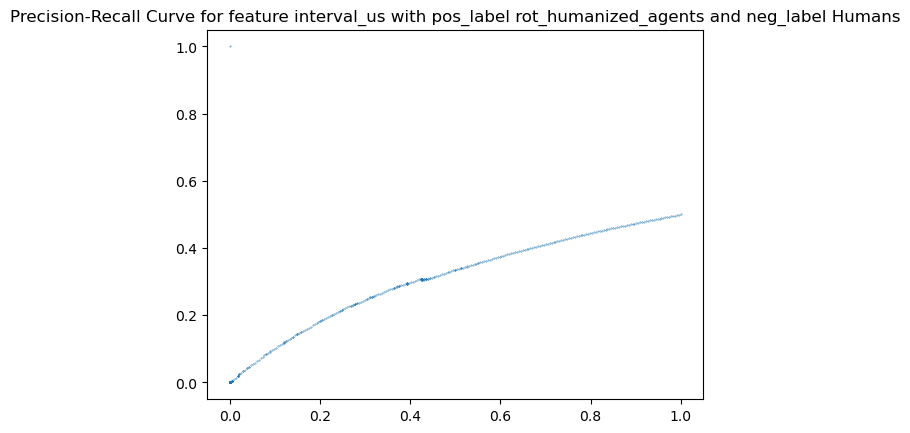

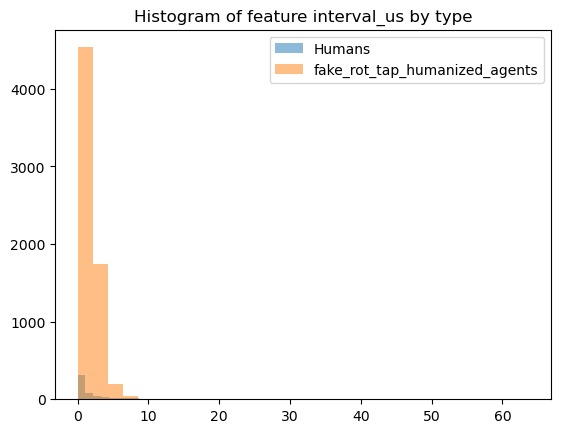

1.164694
-0.16455700000000006


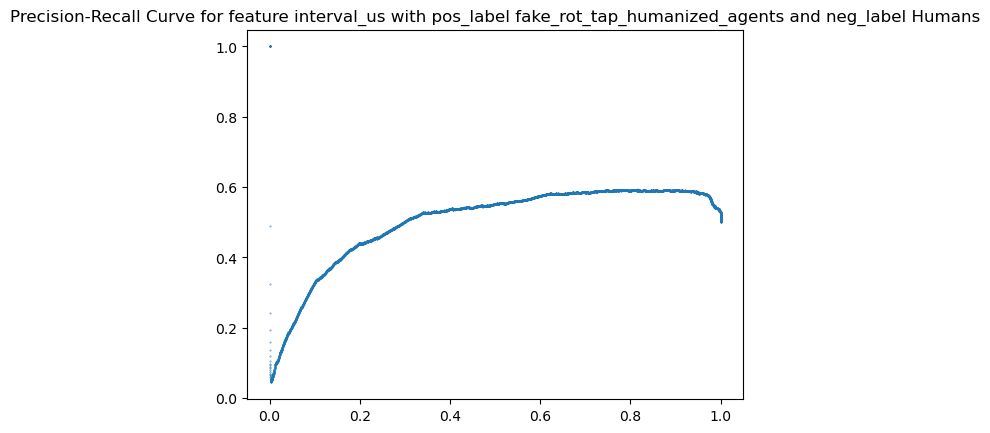

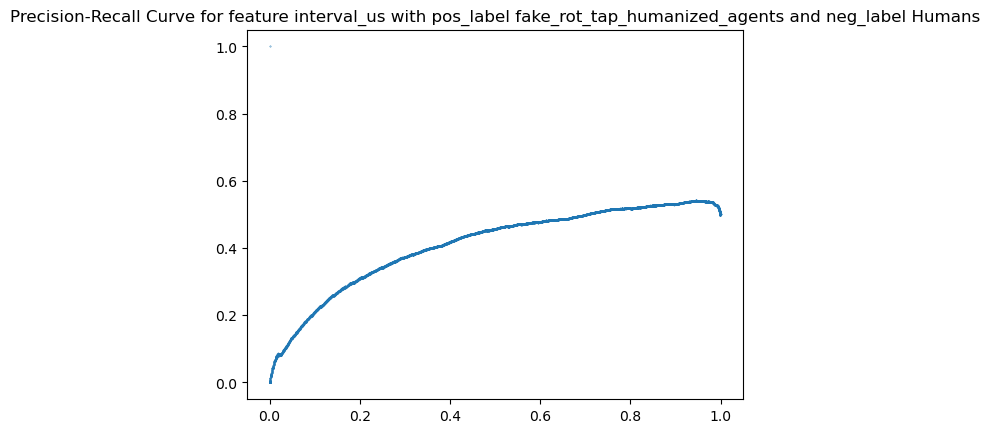

In [71]:
#量化action interval特征在各个场景下的检测准确率
from typing import List, Tuple
from analysis.lib.motionevent_classes import FingerEvent
from analysis.processing.interval_extract import build_intervals_dataframe
from analysis.lib.gesture_log_reader_utils import ranged_batched_modified_generator_with_session_timestamp
from analysis.lib.motionevent_classes import SessionType
from analysis.processing.calculate_roc_auc_from_feature import compute_acc_per_feature_using_break_even_point as compute_acc_per_feature
from analysis.processing.calculate_roc_auc_from_feature import ThresholdPosterior
from analysis.processing.interval_extract import build_intervals_dataframe, faking_intervals_between_gestures

import seaborn as sns
def execute_interval_of_participants_per_index(index_range: Optional[List[int]] = None) -> pd.DataFrame:
    """
    Docstring for execute_interval_of_participants_per_index
    
    :param index_range: Description
    :type index_range: Optional[List[int]]
    :return: A dataframe containing the intervals of participants per index in seconds not microseconds
    :rtype: Any
    """    

    fake_ranged_generator: Callable[[List[str], Optional[Callable[[List[FingerEvent]], List[FingerEvent]]]], List[SessionType]] = partial(
        ranged_batched_modified_generator_with_session_timestamp,
        formated_data_timestamps=formated_data_timestamps,
        batched_filtering_and_modification_function=partial(
            faking_intervals_between_gestures,
            target_expected_interval_us=int(1e6 * 1.1),
        ),
        index_range=index_range
    )

    ui_tars_list = ['ui-tars no humanity', 'ui-tars available humanity']
    
    all_agents_list = non_humanized_agents + humanized_agents
    mobile_agent_e_list = [
        'Mobile-agent-e gpt-4o available humanity',
        'Mobile-agent-e claude-sonnet-3.7 available humanity',
        'gpt4o no humanity',
        'claude no humanity',
    ]
    cpm_gui_agent_list = ['cpm_gui_agent raw', 'cpm_gui_agent available humanity']

    ranged_raw_generator_with_session_timestamp:  Callable[[List[str], Optional[Callable[[List[FingerEvent]], List[FingerEvent]]]], List[SessionType]] = partial(ranged_batched_modified_generator_with_session_timestamp, formated_data_timestamps=formated_data_timestamps, index_range=index_range, batched_filtering_and_modification_function=None)

    generator_list: List[Tuple[str, List[SessionType]]] = [
        ("Humans", ranged_raw_generator_with_session_timestamp(participants=humans)),
        # ("ui_tars_no_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[0]])), ("ui_tars_available_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[1]])),
        ("non_humanized_agents", ranged_raw_generator_with_session_timestamp(participants=non_humanized_agents)),
        ("humanized_agents", ranged_raw_generator_with_session_timestamp(participants=humanized_agents)),
        ("non_humanized_agents_fake", fake_ranged_generator(participants=non_humanized_agents)),
        ("humanized_agents_fake", fake_ranged_generator(participants=humanized_agents)),
        ("rot_humanized_agents", ranged_raw_generator_with_session_timestamp(participants=rot_humanized_agents)),
        ("fake_rot_tap_humanized_agents", ranged_raw_generator_with_session_timestamp(participants=fake_rot_tap_humanized_agents)),
    ]
    duration_df = build_intervals_dataframe(generator_list)
    if True:
        duration_df["interval_us"] /= 1e6
        # convert to log scale
        # duration_df["interval_us"] = duration_df["interval_us"].apply(lambda x: np.log10(x) if x > 0 else None)
    # calculate the 
    return duration_df


# build a dataframe 
"""

| task cluster | raw accuracy | humanized accuracy | raw_fake_accuracy | humanized_fake_accuracy |
| ------------ | ------------ | ------------------ | ----------------- | ----------------------- |
| 0            |              |                    |                   |                         |
| 1            |              |                    |                   |                         |
| 2            |              |                    |                   |                         |
| 3            |              |                    |                   |                         |
| 4            |              |                    |                   |                         |


"""

def calculate_interval_accuracies_per_task_cluster() -> Tuple[pd.DataFrame, Dict[int, ThresholdPosterior]]:
    """
    Docstring for calculate_interval_accuracies_per_task_cluster

    :return: A tuple containing a dataframe of accuracies per task cluster and a dictionary of humanity classifiers across clusters in microseconds
    """

    result_interval = pd.DataFrame(columns=["task_cluster", "raw_accuracy", "humanized_accuracy"])

    humanity_classifier_across_clusters: Dict[int, ThresholdPosterior] = {}
    for cluster_idx, task_list in enumerate(task_clusters):
        duration_df = execute_interval_of_participants_per_index(index_range=task_list)

        # duration_df.to_csv(f"results1220/intervals_task_cluster_{cluster_idx}.csv", index=False)

        accuracy_raw, _ = compute_acc_per_feature(duration_df, pos_label="non_humanized_agents", neg_label="Humans", plot_plt=True)

        accuracy_online_humanity, online_humanity_classifier = compute_acc_per_feature(duration_df, pos_label="humanized_agents", neg_label="Humans", plot_plt=True)
        online_humanity_classifier = online_humanity_classifier["interval_us"]
        # this classifier is in seconds, convert to microseconds
        online_humanity_classifier.threshold *= 1e6  # convert to microseconds  # convert to microseconds
        humanity_classifier_across_clusters[cluster_idx] = online_humanity_classifier

        accuracy_fake_raw, _ = compute_acc_per_feature(duration_df, pos_label="non_humanized_agents_fake", neg_label="Humans", plot_plt=True)

        accuracy_fake_humanized, _ = compute_acc_per_feature(duration_df, pos_label="humanized_agents_fake", neg_label="Humans", plot_plt=True)

        accuracy_rot_humanized, _ = compute_acc_per_feature(duration_df, pos_label="rot_humanized_agents", neg_label="Humans", plot_plt=True)
        accuracy_fake_rot_tap_humanized, _ = compute_acc_per_feature(duration_df, pos_label="fake_rot_tap_humanized_agents", neg_label="Humans", plot_plt=True)

        result_interval = pd.concat([
            result_interval, pd.DataFrame({
                "task_cluster": [cluster_idx],
                "raw_accuracy": [accuracy_raw.loc[0, "acc"] if not accuracy_raw.empty else None],
                "humanized_accuracy": [accuracy_online_humanity.loc[0, "acc"] if not accuracy_online_humanity.empty else None],
                "raw_fake_accuracy": [accuracy_fake_raw.loc[0, "acc"] if not accuracy_fake_raw.empty else None],
                "humanized_fake_accuracy": [accuracy_fake_humanized.loc[0, "acc"] if not accuracy_fake_humanized.empty else None],
                "rot_humanized_accuracy": [accuracy_rot_humanized.loc[0, "acc"] if not accuracy_rot_humanized.empty else None],
                "fake_rot_tap_humanized_accuracy": [accuracy_fake_rot_tap_humanized.loc[0, "acc"] if not accuracy_fake_rot_tap_humanized.empty else None],
            })
        ], ignore_index=True)
    
    result_interval.to_csv("results0125/interval_based_accuracies_per_task_cluster.csv", index=False)

    return result_interval, humanity_classifier_across_clusters

result_interval_df, interval_classifier_microseconds_across_clusters = calculate_interval_accuracies_per_task_cluster()

In [73]:
for col in result_interval_df.columns[1:]:
    result_interval_df[col] = result_interval_df[col].astype(float)
    result_interval_df[col] = result_interval_df[col].apply(lambda x: max(x, 1 - x) if pd.notna(x) else x)

In [74]:
result_interval_df

,task_cluster,raw_accuracy,humanized_accuracy,raw_fake_accuracy,humanized_fake_accuracy,rot_humanized_accuracy,fake_rot_tap_humanized_accuracy
0,0,0.871741,0.863166,0.506894,0.505540,0.892332,0.560800
1,1,0.891076,0.882176,0.523213,0.523208,0.909424,0.555402
2,2,0.904673,0.896815,0.547305,0.548170,0.900485,0.532577
3,3,0.797160,0.802206,0.583876,0.583683,0.861093,0.507875
4,4,0.859239,0.867910,0.510558,0.512337,0.884040,0.563432


In [77]:
interval_humanity_mapper = {
    "raw_accuracy": [1, 3, 4, 9, 11, 15, ],
    "humanized_accuracy": [2, 5, 6, ],
    "raw_fake_accuracy": [7, 10, 12, 13, 14, 16],
    "humanized_fake_accuracy": [8, ],
    "rot_humanized_accuracy": [5,],
    "fake_rot_tap_humanized_accuracy": [16,]
}


# initialize a column dataframe
columns = pd.DataFrame(columns=["interval"], index=range(16 * 5))

# for each cluster, 
for cluster_idx in range(5):
    for key, cluster_list in interval_humanity_mapper.items():
        for interval_idx in cluster_list:
            row_idx = cluster_idx * 16 + (interval_idx - 1)
            columns.loc[row_idx, "interval"] = result_interval_df_copy.loc[cluster_idx, key]

columns.T


,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
interval,0.871741,0.863166,0.871741,0.871741,0.892332,0.863166,0.506894,0.50554,0.871741,0.506894,...,0.510558,0.512337,0.859239,0.510558,0.859239,0.510558,0.510558,0.510558,0.859239,0.563432


## swipe vs taps

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_114522.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_114522.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_115003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_ge

Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251208_143445.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251214_160137.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251214_160137.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191303.log. This may indicate an 

Kept 4 complete samples from all 5 samples in the generated trace.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_140248.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_140248.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_141003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_141003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_142228.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recordi

Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_010704.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_042819.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_042819.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Multitouch event found in file logs/gesture_recording_2025111x/gestur

Kept 5 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_093034.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 5 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251201_194046.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251201_194046.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2

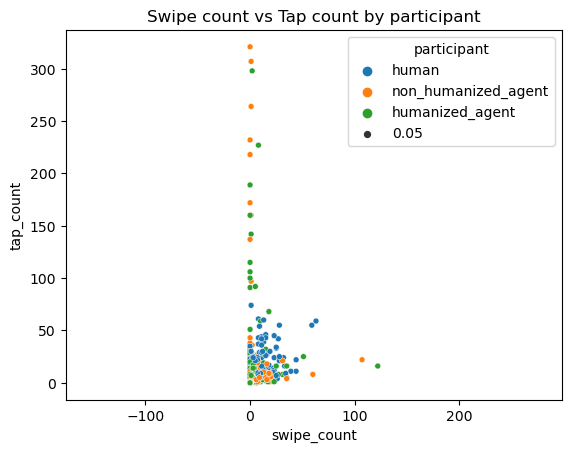

In [79]:
#探索性分析，分析是否人类的swipe和tap有自然的比例分布
from typing import List, Tuple
import seaborn as sns
def execute_swipe_vs_tap_individual_participants():
    all_participants = humans + non_humanized_agents + humanized_agents
    result: List[Tuple[str, int, int]] = []
    for task in range(TASK_COUNT):
        for participant in all_participants:
            swipe_generator = ranged_swipe_generator(participants=[participant], index_range=[task])
            tap_generator = ranged_tap_generator(participants=[participant], index_range=[task])
            swipe_count = len(swipe_generator)
            tap_count = len(tap_generator)

            if participant in humans:
                participant_group_namer = "human"
            elif participant in non_humanized_agents:
                participant_group_namer = "non_humanized_agent"
            else:
                participant_group_namer = "humanized_agent" 

            result.append((participant_group_namer, swipe_count, tap_count))
    df_result = pd.DataFrame(result, columns=["participant", "swipe_count", "tap_count"])
    ax = sns.scatterplot(data=df_result, x="swipe_count", y="tap_count", hue="participant", alpha=1.0, size=0.05)
    ax.set_xlabel("swipe_count")
    ax.set_ylabel("tap_count")
    ax.set_title("Swipe count vs Tap count by participant")
    ax.set_xlim(None, None)
    ax.set_ylim(None, None)
    ax.set_aspect('equal', adjustable='datalim')
    return df_result
swipe_vs_tap_result = execute_swipe_vs_tap_individual_participants()


In [80]:
swipe_vs_tap_result

,participant,swipe_count,tap_count
0,human,18,15
1,human,44,22
2,human,8,15
3,non_humanized_agent,15,6
4,non_humanized_agent,0,0
...,...,...,...
1271,non_humanized_agent,0,0
1272,humanized_agent,0,0
1273,humanized_agent,4,14
1274,humanized_agent,3,14


## human duration vs length for filtering

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

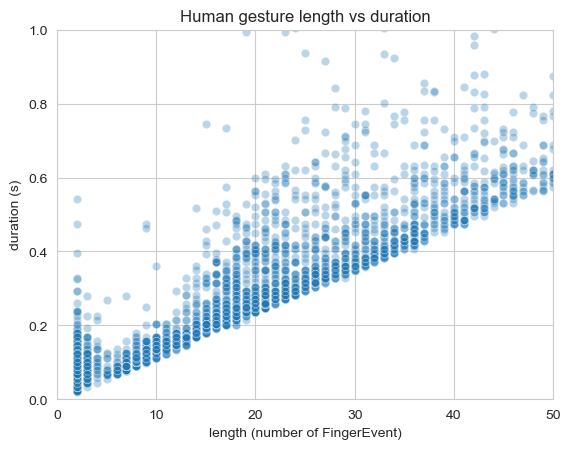

In [281]:
#这个格子的目的是画Figure 8——人类手势的length（FingerEvent数量）vs duration（持续时间）的散点图
#用来确定一个过滤阈值：多短的手势算tap、多长的算swipe。这是数据预处理的可视化验证步骤。

def _gesture_start_end_us(gesture):
    start_us = gesture[0].timestamp_us
    end_us = gesture[-1].timestamp_us
    return start_us, end_us
 #"""重新实现：返回手势的起始和结束时间戳（微秒）"""
def execute_human_duration_vs_length_filtering():
    human_generator = ranged_raw_generator(participants=humans)
    points: List[Tuple[int, float]] = []
    for gesture in human_generator:
        start_us, end_us = _gesture_start_end_us(gesture)
        length = len(gesture)
        points.append((length, (end_us - start_us) / 1e6))
    df_points = pd.DataFrame(points, columns=["length", "duration_s"])
    ax = sns.scatterplot(data=df_points, x="length", y="duration_s", alpha=0.3)
    ax.set_xlabel("length (number of FingerEvent)")
    ax.set_ylabel("duration (s)")
    ax.set_title("Human gesture length vs duration")
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 1.0)

execute_human_duration_vs_length_filtering()

In [ ]:
def countdown(n):
   while n > 0:
       yield n
       n -= 1
# Using the generator
gen = countdown(5)
for value in gen:
   print(value)
for value in gen:
   print(value)

In [84]:
a = (range(10))
for i in a:
    print(i)
for i in a:
    print(i)

0
1
2
3
4
5
6
7
8
9
0
1
2
3
4
5
6
7
8
9


## Success rate

In [85]:
online_humanized_correctness = formated_data_timestamps.columns[11]
RAW_correctness = formated_data_timestamps.columns[18]
only_swipe_correctness = formated_data_timestamps.columns[27]
fake_rot_tap_correctness = formated_data_timestamps.columns[32]
online_humanized_correctness, RAW_correctness, only_swipe_correctness, fake_rot_tap_correctness

('Online humanity best effort count',
 'No humanity Best effort count',
 'only swipe success rate',
 'rot_tap_fake success rate')

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


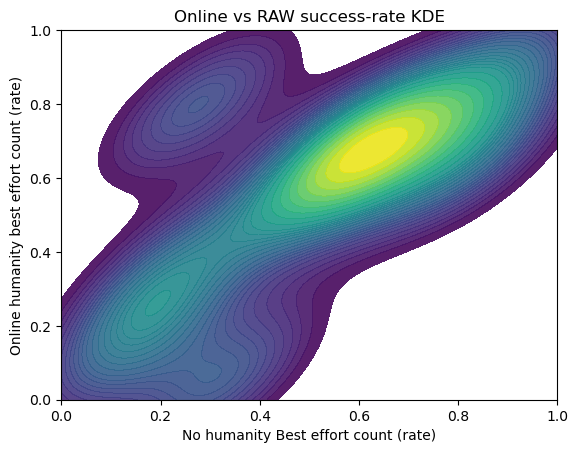

In [86]:
import re
import seaborn as sns

def _parse_ratio_to_tuple(text: str) -> Optional[Tuple[float, float]]:
    if text is None:
        return None
    s = str(text).strip()
    # find the first "num/den" like 1.5/3, 0/2, possibly with extra text/newlines
    m = re.search(r'([0-9]+(?:\.[0-9]+)?)\s*/\s*([0-9]+(?:\.[0-9]+)?)', s)
    if not m:
        return None
    num = float(m.group(1))
    den = float(m.group(2))
    if den == 0:
        return None
    return (num, den)

def build_success_rate_pairs(df: pd.DataFrame, col_names: List[str]):
    pairs: List[Tuple[Tuple[float, float], ...]] = []
    rates: List[Tuple[float, ...]] = []
    for _, row in df.iterrows():
        list_tuples = [_parse_ratio_to_tuple(row.get(col_name)) for col_name in col_names]

        if any(p is None for p in list_tuples):
            continue
        
        list_tuples = [p for p in list_tuples if p is not None]

        pairs.append(tuple(list_tuples))

        rates.append(tuple(p[0] / p[1] for p in list_tuples))
    return pairs, rates

def plot_kde_success_rates(bw_adjust=0.8):
    extracted_pairs, rates_tuples = build_success_rate_pairs(
        formated_data_timestamps, [online_humanized_correctness, RAW_correctness, only_swipe_correctness, fake_rot_tap_correctness]
    )
    if not rates_tuples:
        print("No valid success-rate tuples found.")
        return extracted_pairs, rates_tuples

    # unpack for plotting: x=RAW, y=Online
    online_rates = [t[0] for t in rates_tuples]
    raw_rates = [t[1] for t in rates_tuples]

    ax = sns.kdeplot(
        x=raw_rates, y=online_rates,
        fill=True, cmap="viridis", levels=30, thresh=0.05,
        bw_adjust=bw_adjust, clip=((0, 1), (0, 1)), alpha=0.9
    )
    # optional scatter overlay for reference
    # sns.scatterplot(x=raw_rates, y=online_rates, s=10, alpha=0.25, color="black", ax=ax)

    ax.set_xlabel(f"{RAW_correctness} (rate)")
    ax.set_ylabel(f"{online_humanized_correctness} (rate)")
    ax.set_title("Online vs RAW success-rate KDE")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    return extracted_pairs, rates_tuples



# Run with adjustable kernel size (smaller -> more detail, larger -> smoother)
extracted_pairs, rates_tuples = plot_kde_success_rates(bw_adjust=0.8)



In [294]:
# 看看这四列里有多少非空数据
cols = [online_humanized_correctness, RAW_correctness, only_swipe_correctness, fake_rot_tap_correctness]
for col in cols:
    non_null = formated_data_timestamps[col].notna().sum()
    non_empty = formated_data_timestamps[col].apply(lambda x: isinstance(x, str) and x.strip() != '' and x.strip() != 'nan').sum()
    print(f"{col}: {non_empty} non-empty rows")

Online humanity best effort count: 35 non-empty rows
No humanity Best effort count: 36 non-empty rows
only swipe success rate: 9 non-empty rows
rot_tap_fake success rate: 9 non-empty rows


In [87]:
extracted_pairs, rates_tuples

([((2.6, 4.0), (3.3, 4.0), (1.5, 2.0), (1.5, 2.0)),
  ((0.6, 4.0), (0.6, 4.0), (1.4, 2.0), (0.6, 4.0)),
  ((0.2, 4.0), (1.3, 4.0), (1.3, 4.0), (1.7, 4.0)),
  ((3.2, 4.0), (1.1, 4.0), (1.9, 2.0), (1.2, 2.0)),
  ((2.5, 4.0), (2.1, 4.0), (1.0, 2.0), (0.0, 2.0)),
  ((2.5, 4.0), (2.5, 4.0), (2.0, 2.0), (1.0, 2.0)),
  ((1.35, 4.0), (0.8, 4.0), (0.4, 2.0), (0.5, 2.0)),
  ((2.9, 4.0), (2.5, 4.0), (1.6, 2.0), (1.2, 2.0)),
  ((3.5, 4.0), (3.5, 4.0), (2.0, 2.0), (0.6, 2.0))],
 [(0.65, 0.825, 0.75, 0.75),
  (0.15, 0.15, 0.7, 0.15),
  (0.05, 0.325, 0.325, 0.425),
  (0.8, 0.275, 0.95, 0.6),
  (0.625, 0.525, 0.5, 0.0),
  (0.625, 0.625, 1.0, 0.5),
  (0.3375, 0.2, 0.2, 0.25),
  (0.725, 0.625, 0.8, 0.6),
  (0.875, 0.875, 1.0, 0.3)])

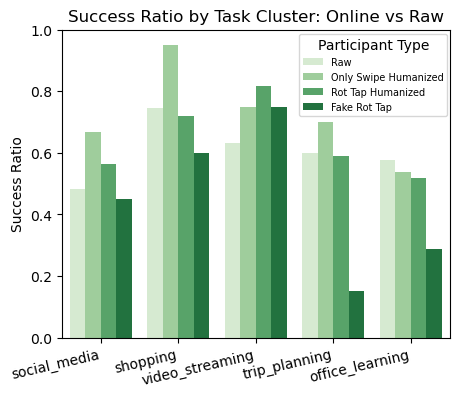

In [88]:
import matplotlib.pyplot as plt

cluster_names = list(task_cluster_by_name.keys())
cluster_plot_data = []



for i, indices in enumerate(task_clusters):
    name = cluster_names[i]
    for label, col in [("Raw", RAW_correctness),  ("Only Swipe Humanized", only_swipe_correctness), ("Rot Tap Humanized", online_humanized_correctness), ("Fake Rot Tap", fake_rot_tap_correctness)]:
        success_sum, total_sum = 0, 0
        for idx in indices:
            res = _parse_ratio_to_tuple(formated_data_timestamps.iloc[idx][col])
            if res:
                success_sum += res[0]
                total_sum += res[1]
        if total_sum > 0:
            cluster_plot_data.append({"Cluster": name, "Type": label, "Success Ratio": success_sum / total_sum, "idx": i})

df_cluster_stats = pd.DataFrame(cluster_plot_data)
plt.figure(figsize=(5, 4))
# choose a classy palette
sns.barplot(data=df_cluster_stats, x="Cluster", y="Success Ratio", hue="Type", palette="Greens")
plt.ylim(0, 1)
plt.title("Success Ratio by Task Cluster: Online vs Raw")
plt.ylabel("Success Ratio")
# rotate xlabel by 45 degrees and align right
plt.xticks(rotation=13, ha='right')

# make xlabel disappear
plt.xlabel("")

# make legend box smaller
plt.legend(title="Participant Type", bbox_to_anchor=(0.60, 1), loc='upper left', fontsize=7)


plt.show()


In [89]:
df_cluster_stats

,Cluster,Type,Success Ratio,idx
0,social_media,Raw,0.483333,0
1,social_media,Only Swipe Humanized,0.666667,0
2,social_media,Rot Tap Humanized,0.562500,0
3,social_media,Fake Rot Tap,0.450000,0
4,shopping,Raw,0.745161,1
5,shopping,Only Swipe Humanized,0.950000,1
6,shopping,Rot Tap Humanized,0.718182,1
7,shopping,Fake Rot Tap,0.600000,1
8,video_streaming,Raw,0.633333,2
9,video_streaming,Only Swipe Humanized,0.750000,2


In [90]:
# initialize a column dataframe

utility_humanity_mapper = {
    "Raw": [1, 3, 4, 7, 9, 10, 11, 12, 13, 14, 15, ],
    "Rot Tap Humanized": [2, 6, 8, ],
    "Only Swipe Humanized": [5,],
    "Fake Rot Tap": [16,],
}

columns = pd.DataFrame(columns=["utility"], index=range(16 * 5))

# for each cluster, 
for cluster_idx in range(5):
    for key, cluster_list in utility_humanity_mapper.items():
        for interval_idx in cluster_list:
            row_idx = cluster_idx * 16 + (interval_idx - 1)

            # find the corresponding row in df_cluster_stats
            df_cluster_stats_row = df_cluster_stats[
                (df_cluster_stats["idx"] == cluster_idx) &
                (df_cluster_stats["Type"] == key)
            ]
            if df_cluster_stats_row.empty:
                continue    

            columns.loc[row_idx, "utility"] = df_cluster_stats_row["Success Ratio"].values[0]

columns.T

,0,1,2,3,4,5,6,7,8,9,...,70,71,72,73,74,75,76,77,78,79
utility,0.483333,0.5625,0.483333,0.483333,0.666667,0.5625,0.483333,0.5625,0.483333,0.483333,...,0.575,0.516667,0.575,0.575,0.575,0.575,0.575,0.575,0.575,0.2875


In [91]:
extracted_pairs, rates_tuples

([((2.6, 4.0), (3.3, 4.0), (1.5, 2.0), (1.5, 2.0)),
  ((0.6, 4.0), (0.6, 4.0), (1.4, 2.0), (0.6, 4.0)),
  ((0.2, 4.0), (1.3, 4.0), (1.3, 4.0), (1.7, 4.0)),
  ((3.2, 4.0), (1.1, 4.0), (1.9, 2.0), (1.2, 2.0)),
  ((2.5, 4.0), (2.1, 4.0), (1.0, 2.0), (0.0, 2.0)),
  ((2.5, 4.0), (2.5, 4.0), (2.0, 2.0), (1.0, 2.0)),
  ((1.35, 4.0), (0.8, 4.0), (0.4, 2.0), (0.5, 2.0)),
  ((2.9, 4.0), (2.5, 4.0), (1.6, 2.0), (1.2, 2.0)),
  ((3.5, 4.0), (3.5, 4.0), (2.0, 2.0), (0.6, 2.0))],
 [(0.65, 0.825, 0.75, 0.75),
  (0.15, 0.15, 0.7, 0.15),
  (0.05, 0.325, 0.325, 0.425),
  (0.8, 0.275, 0.95, 0.6),
  (0.625, 0.525, 0.5, 0.0),
  (0.625, 0.625, 1.0, 0.5),
  (0.3375, 0.2, 0.2, 0.25),
  (0.725, 0.625, 0.8, 0.6),
  (0.875, 0.875, 1.0, 0.3)])

In [93]:
sum_raw, sum_humanized = 0.0, 0.0
# calculate the average of online success rate and RAW success rate
for online_pair, raw_pair, *_ in extracted_pairs:
    online_rate = online_pair[0] / online_pair[1]
    raw_rate = raw_pair[0] / raw_pair[1]
    sum_raw += raw_rate
    sum_humanized += online_rate

average_raw = sum_raw / len(extracted_pairs)
average_humanized = sum_humanized / len(extracted_pairs)
average_raw, average_humanized

(0.49166666666666675, 0.5375000000000001)

In [94]:
print(f"参与计算的样本数: {len(extracted_pairs)}")
print(f"Excel总行数: {len(formated_data_timestamps)}")

参与计算的样本数: 9
Excel总行数: 116


## print table comparing all data

In [173]:
from analysis.processing.extract_feature_of_swipes import build_features_dataframe

all_iterators = [
    ("humans", ranged_swipe_generator(participants=humans)),
    ("humanized_agents", ranged_swipe_generator(participants=humanized_agents)),
    ("non_humanized_agents", ranged_swipe_generator(participants=non_humanized_agents)),
    ("fake_humanized_agents", ranged_swipe_generator(participants=non_humanized_agents, humanity_disturbance=static_fit_effort_provider.humanity_disturbance)),
]
generator_all_iterators = all_iterators

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191019.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191303.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_194143.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

Kept 98 complete samples from all 99 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_200814.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 4 complete samples from all 5 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_201717.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_205852.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 4 complete samples from all 6 samples in the generated trace.
Incomplete sampl

Kept 3 complete samples from all 4 samples in the generated trace.


In [177]:
features_df = build_features_dataframe(generator_all_iterators)

In [178]:
features_df.columns

Index(['type', 'duration', 'startX', 'startY', 'endX', 'endY', 'displacement',
       'meanResultantLength', 'direction', 'v20', 'v50', 'v80', 'a20', 'a50',
       'a80', 'v_last3_median', 'maxDevSigned', 'dev20', 'dev50', 'dev80',
       'avgDirection', 'length', 'ratio_end_to_length', 'speed',
       'acc_first5pct_median'],
      dtype='object')

In [179]:
features_df[["type", "maxDevSigned"]].to_csv("results0125/swipe_maxDevSigned_features.csv", index=False)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


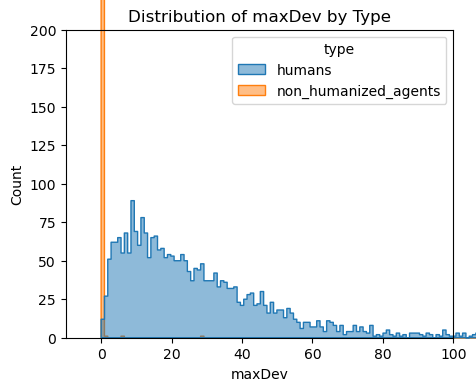

<Figure size 640x480 with 0 Axes>

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
ax = sns.histplot(data=features_df[(features_df["type"] == "humans") | (features_df["type"] == "non_humanized_agents")], x="maxDevSigned", hue="type", bins=1000, element="step", alpha=0.5, common_norm=False)
ax.set_title("Distribution of maxDev by Type")

# Disable clipping so the data can "poke out" of the defined ylim
for artist in ax.collections + ax.lines + ax.patches:
    artist.set_clip_on(False)

# Adjust xlim here to zoom into specific ranges
ax.set_xlabel("maxDev")
ax.set_xlim(-10,100)
ax.set_ylim(0, 200)

plt.show()

# save the fig with cropping
plt.savefig("asdf.png", bbox_inches='tight', dpi=300)

In [189]:
features_df.to_csv("results1202/labels_and_extracted_features.csv", index=False)

In [ ]:
# Note: these os.system calls are superseded by Section 1.11 (make_feature_and_learner_table)
# They may silently fail in environments where the module path is not a valid script path
# Results are instead generated via the notebook's in-process analysis pipeline

## remove ui-tars

In [111]:
#这个1.9作者希望看专门看移除UI-TARS后特征排名的变化
all_iterators = [
    ("humans", ranged_swipe_generator(participants=humans, index_range=None)),
    ("humanized_agents", ranged_swipe_generator(participants=humanized_agents[1:], index_range=None)),
    ("non_humanized_agents", ranged_swipe_generator(participants=non_humanized_agents[1:], index_range=None)),
]
generator_all_iterators = (ited for ited in all_iterators)

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251115_175245.log, which is unexpected and currently not supported. Skipping this file.

SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_102514.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_102956.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/gesture_recording_2025111x/gesture_recording_20251112_104231.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found i

Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251214_160137.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251214_182707.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file logs/gesture_recording_o_2025_10_2026_01/gesture_recording_20251214_182822.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.


In [112]:
build_features_dataframe(generator_all_iterators).to_csv("no_ui_tars_labels_and_extracted_features.csv", index=False)

In [115]:
#公开版本的build_features_dataframe只保留了24个核心特征，去掉了很多中间特征。
no_ui_tars_df = pd.read_csv("no_ui_tars_labels_and_extracted_features.csv")
print(f"样本数: {len(no_ui_tars_df)}")

result_no_ui_tars, _ = compute_acc_per_feature_using_max_precision(
    no_ui_tars_df, pos_label="humanized_agents", neg_label="humans"
)
result_no_ui_tars.sort_values("acc", ascending=False).head(15)

样本数: 2763


,feature,acc,n,n_pos,n_neg
11,a20,0.798517,2308,489,1819
5,displacement,0.770678,2308,489,1819
12,a50,0.766409,2308,489,1819
14,v_last3_median,0.705050,2308,489,1819
20,length,0.697837,2308,489,1819
21,ratio_end_to_length,0.657040,2308,489,1819
3,endX,0.649047,2308,489,1819
7,direction,0.648481,2308,489,1819
13,a80,0.642882,2308,489,1819
6,meanResultantLength,0.612304,2308,489,1819


## previous final table

legacy code
```python
from analysis.processing.calculate_roc_auc_from_feature import filter_df, compute_auc_per_feature, numeric_feature_columns



def calculate_svm_and_xgboost(features_csv: pd.DataFrame, pos_label: str, neg_label: str):
    filtered = filter_df(df=features_csv, pos_label=pos_label, neg_label=neg_label)

    # compute svm and xgboost on the filtered data
    from sklearn.model_selection import train_test_split
    from sklearn.svm import SVC
    from xgboost import XGBClassifier
    from sklearn.metrics import roc_auc_score
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score
    # prepare features and labels
    feature_cols = numeric_feature_columns(filtered)
    X = (
        filtered.loc[:, feature_cols]
        .apply(pd.to_numeric, errors="coerce")
        .replace([float("inf"), float("-inf")], pd.NA)
        .fillna(0.0)
    )
    y = (filtered["type"].astype(str) == pos_label).astype(int)

    svm_acc, xgb_acc = None, None
    if not X.empty and y.nunique() == 2:
        if (y.value_counts().min() < 2):
            return {"svm_accuracy": None, "xgb_accuracy": None}
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        # ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
        
        
        # SVM with scaling
        svm_clf = make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=False, random_state=42))
        svm_clf.fit(X_train, y_train)
        y_pred_svm = svm_clf.predict(X_test)
        svm_acc = accuracy_score(y_test, y_pred_svm)

        # XGBoost
        xgb_clf = XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            n_jobs=4,
            random_state=42,
            eval_metric="logloss",
        )
        xgb_clf.fit(X_train, y_train)
        y_pred_xgb = xgb_clf.predict(X_test)
        xgb_acc = accuracy_score(y_test, y_pred_xgb)

    return {"svm_accuracy": svm_acc, "xgb_accuracy": xgb_acc}



result_csv = pd.DataFrame()

for task in range(TASK_COUNT):
    task_specific_iterators = [
        ("humans", ranged_swipe_generator(humans, [task])),
        ("humanized_agents", ranged_swipe_generator(humanized_agents, [task])),
        ("non_humanized_agents", ranged_swipe_generator(non_humanized_agents, [task])),
    ]
    generator_task_specific_iterators = (ited for ited in task_specific_iterators)
    features_csv = build_features_dataframe(generator_task_specific_iterators)

    
        


    # non_humanized_agents_vs_humans
    filtered = filter_df(features_csv, "non_humanized_agents", "humans")
    res = compute_auc_per_feature(filtered, "non_humanized_agents", "humans")

    if not res.empty:
        res.set_index(keys="feature", inplace=True)
        auc_oriented = res[["auc_oriented"]] # use the named index as columns
        result_csv[[(task, "RAW")]] = auc_oriented
        clf_res_unhumanized = calculate_svm_and_xgboost(features_csv, "non_humanized_agents", "humans")
        print(clf_res_unhumanized)
        result_csv.loc["svm", [(task, "RAW")]] = clf_res_unhumanized["svm_accuracy"]
        result_csv.loc["xgboost", [(task, "RAW")]] = clf_res_unhumanized["xgb_accuracy"]

    # humanized_agents_vs_humans
    filtered = filter_df(features_csv, "humanized_agents", "humans")
    res = compute_auc_per_feature(filtered, "humanized_agents", "humans")

    if not res.empty:
        res.set_index(keys="feature", inplace=True)
        # print(res)
        auc_oriented = res[["auc_oriented"]] # use the named index as columns
        # print(auc_oriented)
        result_csv[[(task, "rotation_and_match")]] = auc_oriented
        # print(result_csv)
        clf_res = calculate_svm_and_xgboost(features_csv, "humanized_agents", "humans")
        print(clf_res)
        result_csv.loc["svm", [(task, "rotation_and_match")]] = clf_res["svm_accuracy"]
        result_csv.loc["xgboost", [(task, "rotation_and_match")]] = clf_res["xgb_accuracy"]
```

## construct final table

In [193]:

from typing import List, Tuple
from analysis.processing.calculate_roc_auc_from_feature import make_feature_and_learner_table
result_csv = pd.DataFrame()



for cluster_idx, task_cluster in enumerate(task_clusters):
    list_to_concat: List[pd.DataFrame] = []

    try:
        non_humanized_result_csv = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="RAW",
            pos_iterator=("non_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents,  index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(non_humanized_result_csv)
    except ValueError:
        print("Warning: No valid data for non_humanized_agents vs humans for task", task_cluster)
    try:
        humanized_result_csv = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match",
            pos_iterator=("humanized_agents", ranged_swipe_generator(
                participants=humanized_agents, index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(humanized_result_csv)
    except ValueError:
        print("Warning: No valid data for humanized_agents vs humans for task", task_cluster)

    try:
        fake_humanized_result_csv = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match_disturbance",
            pos_iterator=("fake_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=static_fit_effort_provider.humanity_disturbance
                )),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv)
    except ValueError:
        print("Warning: No valid data for fake_humanized_agents vs humans for task", task_cluster)

    try:
        fake_humanized_result_csv_2 = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="b_spline_disturbance",
            pos_iterator=("fake_humanized_agents_b_spline", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=b_spline_faker
                )),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv_2)
    except ValueError:
        print("Warning: No valid data for fake_humanized_agents_b_spline vs humans for task", task_cluster)
        
    # directly join the three result csvs to results
    result_csv = pd.concat(
        [result_csv] + list_to_concat,
        axis=1
    )
result_csv.T.to_csv("results1220/final_auc_and_learner_results_1220.csv")




Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

{'svm_accuracy': 0.9876543209876543, 'xgb_accuracy': 0.9938271604938271, 'svm_test_metrics': BinaryClassificationMetrics(TP=59, FP=2, TN=101, FN=0), 'xgb_test_metrics': BinaryClassificationMetrics(TP=58, FP=0, TN=103, FN=1)}


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251201_194046.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_073155.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_093034.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 5 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gest

{'svm_accuracy': 0.9323308270676691, 'xgb_accuracy': 0.9924812030075187, 'svm_test_metrics': BinaryClassificationMetrics(TP=22, FP=1, TN=102, FN=8), 'xgb_test_metrics': BinaryClassificationMetrics(TP=29, FP=0, TN=103, FN=1)}


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

...

{'svm_accuracy': 0.9627329192546584, 'xgb_accuracy': 0.9627329192546584, 'svm_test_metrics': BinaryClassificationMetrics(TP=75, FP=5, TN=80, FN=1), 'xgb_test_metrics': BinaryClassificationMetrics(TP=74, FP=4, TN=81, FN=2)}


Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155555.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155747.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture

{'svm_accuracy': 0.944, 'xgb_accuracy': 0.992, 'svm_test_metrics': BinaryClassificationMetrics(TP=34, FP=1, TN=84, FN=6), 'xgb_test_metrics': BinaryClassificationMetrics(TP=39, FP=0, TN=85, FN=1)}


Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155555.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155747.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture

{'svm_accuracy': 0.984, 'xgb_accuracy': 0.992, 'svm_test_metrics': BinaryClassificationMetrics(TP=39, FP=1, TN=84, FN=1), 'xgb_test_metrics': BinaryClassificationMetrics(TP=40, FP=1, TN=84, FN=0)}


In [195]:
print(type(result_csv.columns))
print(result_csv.columns[:8])

<class 'pandas.core.indexes.base.Index'>
Index([                           (0, 'RAW'),
                   (0, 'rotation_and_match'),
       (0, 'rotation_and_match_disturbance'),
                 (0, 'b_spline_disturbance'),
                                  (1, 'RAW'),
                   (1, 'rotation_and_match'),
       (1, 'rotation_and_match_disturbance'),
                 (1, 'b_spline_disturbance')],
      dtype='object')


In [196]:
# 提取Social Media cluster (cluster 0) 的四种方法
cols_cluster0 = [c for c in result_csv.columns if c[0] == 0]
social_media = result_csv[cols_cluster0].copy()
social_media.columns = ['RAW', 'On.RM', 'Off.RM', 'BS']

# 按RAW列降序排列（跟论文Table 2一样）
social_media_sorted = social_media.sort_values('RAW', ascending=False)
print(social_media_sorted.round(4).to_string())
###### table 2复现

                         RAW   On.RM  Off.RM      BS
feature                                             
svm_tpr               1.0000  0.7333  0.9322  1.0000
maxDevSigned          0.9998  0.6118  0.6340  0.8217
meanResultantLength   0.9997  0.6167  0.5015  0.5163
ratio_end_to_length   0.9997  0.6212  0.5121  0.6224
xgb_accuracy          0.9938  0.9925  1.0000  0.9938
svm_accuracy          0.9877  0.9323  0.9568  0.9815
xgb_tpr               0.9831  0.9667  1.0000  1.0000
a80                   0.9372  0.5759  0.5136  0.8308
v80                   0.9137  0.7042  0.6467  0.9028
acc_first5pct_median  0.9075  0.5665  0.5010  0.8950
v50                   0.8431  0.7240  0.6646  0.8438
duration              0.8374  0.5729  0.5059  0.8522
speed                 0.8286  0.7322  0.6636  0.8267
a20                   0.7994  0.6982  0.6176  0.7258
v20                   0.6904  0.7316  0.6448  0.7066
v_last3_median        0.6716  0.6394  0.5536  0.6625
endX                  0.6422  0.6164  0.6394  

In [197]:
# 构建完整的跨cluster对比表
cluster_names = {
    0: 'Social Media',
    1: 'Shopping', 
    2: 'VideoStreaming',
    3: 'Trip Planning',
    4: 'Office & Learning'
}

method_names = ['RAW', 'On.RM', 'Off.RM', 'BS']

# 提取所有cluster并拼在一起
all_clusters = []
for cluster_idx in range(5):
    cols = [c for c in result_csv.columns if c[0] == cluster_idx]
    df = result_csv[cols].copy()
    df.columns = method_names
    df.columns = pd.MultiIndex.from_tuples(
        [(cluster_names[cluster_idx], m) for m in method_names]
    )
    all_clusters.append(df)

full_table = pd.concat(all_clusters, axis=1)
full_table_sorted = full_table.sort_values((cluster_names[0], 'RAW'), ascending=False)
print(full_table_sorted.round(4).to_string())

                     Social Media                         Shopping                         VideoStreaming                         Trip Planning                         Office & Learning                        
                              RAW   On.RM  Off.RM      BS      RAW   On.RM  Off.RM      BS            RAW   On.RM  Off.RM      BS           RAW   On.RM  Off.RM      BS               RAW   On.RM  Off.RM      BS
feature                                                                                                                                                                                                          
svm_tpr                    1.0000  0.7333  0.9322  1.0000   0.9808  0.8077  0.7500  0.9231         1.0000  0.8611  0.8627  0.9412        0.9901  0.8333  0.9208  0.9703            1.0000  0.9868  0.8500  0.9750
maxDevSigned               0.9998  0.6118  0.6340  0.8217   0.9994  0.7435  0.5503  0.8333         1.0000  0.7876  0.5863  0.8315        0.9980  0.5547  0.5157 

In [198]:
#Table 7/8的完整对比表
full_table_sorted.round(4).to_csv("results1220/table7_8_all_clusters.csv")

In [199]:

from typing import List, Tuple
from analysis.processing.calculate_roc_auc_from_feature import make_feature_and_learner_table
result_csv = pd.DataFrame()



for cluster_idx, task_cluster in enumerate(task_clusters):
    list_to_concat: List[pd.DataFrame] = []

    try:
        non_humanized_result_csv = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="RAW",
            pos_iterator=("non_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents,  index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(non_humanized_result_csv)
    except ValueError:
        print("Warning: No valid data for non_humanized_agents vs humans for task", task_cluster)
    try:
        humanized_result_csv = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match",
            pos_iterator=("humanized_agents", ranged_swipe_generator(
                participants=humanized_agents, index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(humanized_result_csv)
    except ValueError:
        print("Warning: No valid data for humanized_agents vs humans for task", task_cluster)

    try:
        fake_humanized_result_csv = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match_disturbance",
            pos_iterator=("fake_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=static_fit_effort_provider.humanity_disturbance
                )),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv)
    except ValueError:
        print("Warning: No valid data for fake_humanized_agents vs humans for task", task_cluster)

    try:
        fake_humanized_result_csv_2 = make_feature_and_learner_table(
            task_cluster_id=cluster_idx,
            method_name="b_spline_disturbance",
            pos_iterator=("fake_humanized_agents_b_spline", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=b_spline_faker
                )),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv_2)
    except ValueError:
        print("Warning: No valid data for fake_humanized_agents_b_spline vs humans for task", task_cluster)
        
    # directly join the three result csvs to results
    result_csv = pd.concat(
        [result_csv] + list_to_concat,
        axis=1
    )
result_csv.T.to_csv("results1220/final_auc_and_learner_results_1220.csv")




Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

{'svm_accuracy': 0.9876543209876543, 'xgb_accuracy': 0.9938271604938271, 'svm_test_metrics': BinaryClassificationMetrics(TP=59, FP=2, TN=101, FN=0), 'xgb_test_metrics': BinaryClassificationMetrics(TP=58, FP=0, TN=103, FN=1)}


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_073155.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_093034.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 5 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251204_020956.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 7 complete samples from all 8 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gest

{'svm_accuracy': 0.9323308270676691, 'xgb_accuracy': 0.9924812030075187, 'svm_test_metrics': BinaryClassificationMetrics(TP=22, FP=1, TN=102, FN=8), 'xgb_test_metrics': BinaryClassificationMetrics(TP=29, FP=0, TN=103, FN=1)}


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

...

{'svm_accuracy': 0.9627329192546584, 'xgb_accuracy': 0.9627329192546584, 'svm_test_metrics': BinaryClassificationMetrics(TP=75, FP=5, TN=80, FN=1), 'xgb_test_metrics': BinaryClassificationMetrics(TP=74, FP=4, TN=81, FN=2)}


Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155555.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155747.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture

{'svm_accuracy': 0.936, 'xgb_accuracy': 0.992, 'svm_test_metrics': BinaryClassificationMetrics(TP=33, FP=1, TN=84, FN=7), 'xgb_test_metrics': BinaryClassificationMetrics(TP=39, FP=0, TN=85, FN=1)}


Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155555.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155747.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture

{'svm_accuracy': 0.984, 'xgb_accuracy': 0.984, 'svm_test_metrics': BinaryClassificationMetrics(TP=39, FP=1, TN=84, FN=1), 'xgb_test_metrics': BinaryClassificationMetrics(TP=40, FP=2, TN=83, FN=0)}


In [202]:
result_coloring = pd.DataFrame(0, index=result_csv.index, columns=result_csv.columns)

added_value: List[Tuple[float, float, str, int]] = []

for cluster_idx, task_cluster in enumerate(task_clusters):
    # check whether (task, "RAW") is in result_csv columns
    if (cluster_idx, "RAW") not in result_csv.columns:
        print(f"Task {cluster_idx} with RAW method is missing in result_csv")
        continue
    else:
        print(f"exists: ", (cluster_idx, "RAW"))

    methods = ["rotation_and_match", "rotation_and_match_disturbance", "b_spline_disturbance"]
    # Iterate over each column and compare the values to "RAW". If any method has lower AUC than RAW, write a 1
    for method in methods:
        if (cluster_idx, method) not in result_csv.columns:
            print(f"Task {cluster_idx} with method {method} is missing in result_csv")
            continue
        for feature in result_csv.index:
            raw_value = result_csv.loc[feature, [(cluster_idx, "RAW")]].item()
            method_value = result_csv.loc[feature, [(cluster_idx, method)]].item()
            if pd.isna(raw_value) or pd.isna(method_value):
                continue
            if method_value < raw_value:
                # print(f"Task {task}, Feature {feature}, Method {method}: {method_value} < {raw_value}")
                result_coloring.loc[feature, [(cluster_idx, method)]] = 1
    
    for feature in result_csv.index:
        raw_value = result_csv.loc[feature, [(cluster_idx, "RAW")]].item()
        min_value = float('inf')
        for method in methods:
            if (cluster_idx, method) not in result_csv.columns:
                continue
            
            method_value = result_csv.loc[feature, [(cluster_idx, method)]].item()
            
            min_value = min(min_value, method_value)
        added_value.append((raw_value, raw_value - min_value, feature, cluster_idx))
result_coloring.T.to_csv("results1220/final_auc_and_learner_results_coloring_1220.csv")

exists:  (0, 'RAW')
exists:  (1, 'RAW')
exists:  (2, 'RAW')
exists:  (3, 'RAW')
exists:  (4, 'RAW')


Text(0.5, 1.0, 'AUC/acc decrease w.r.t to RAW method')

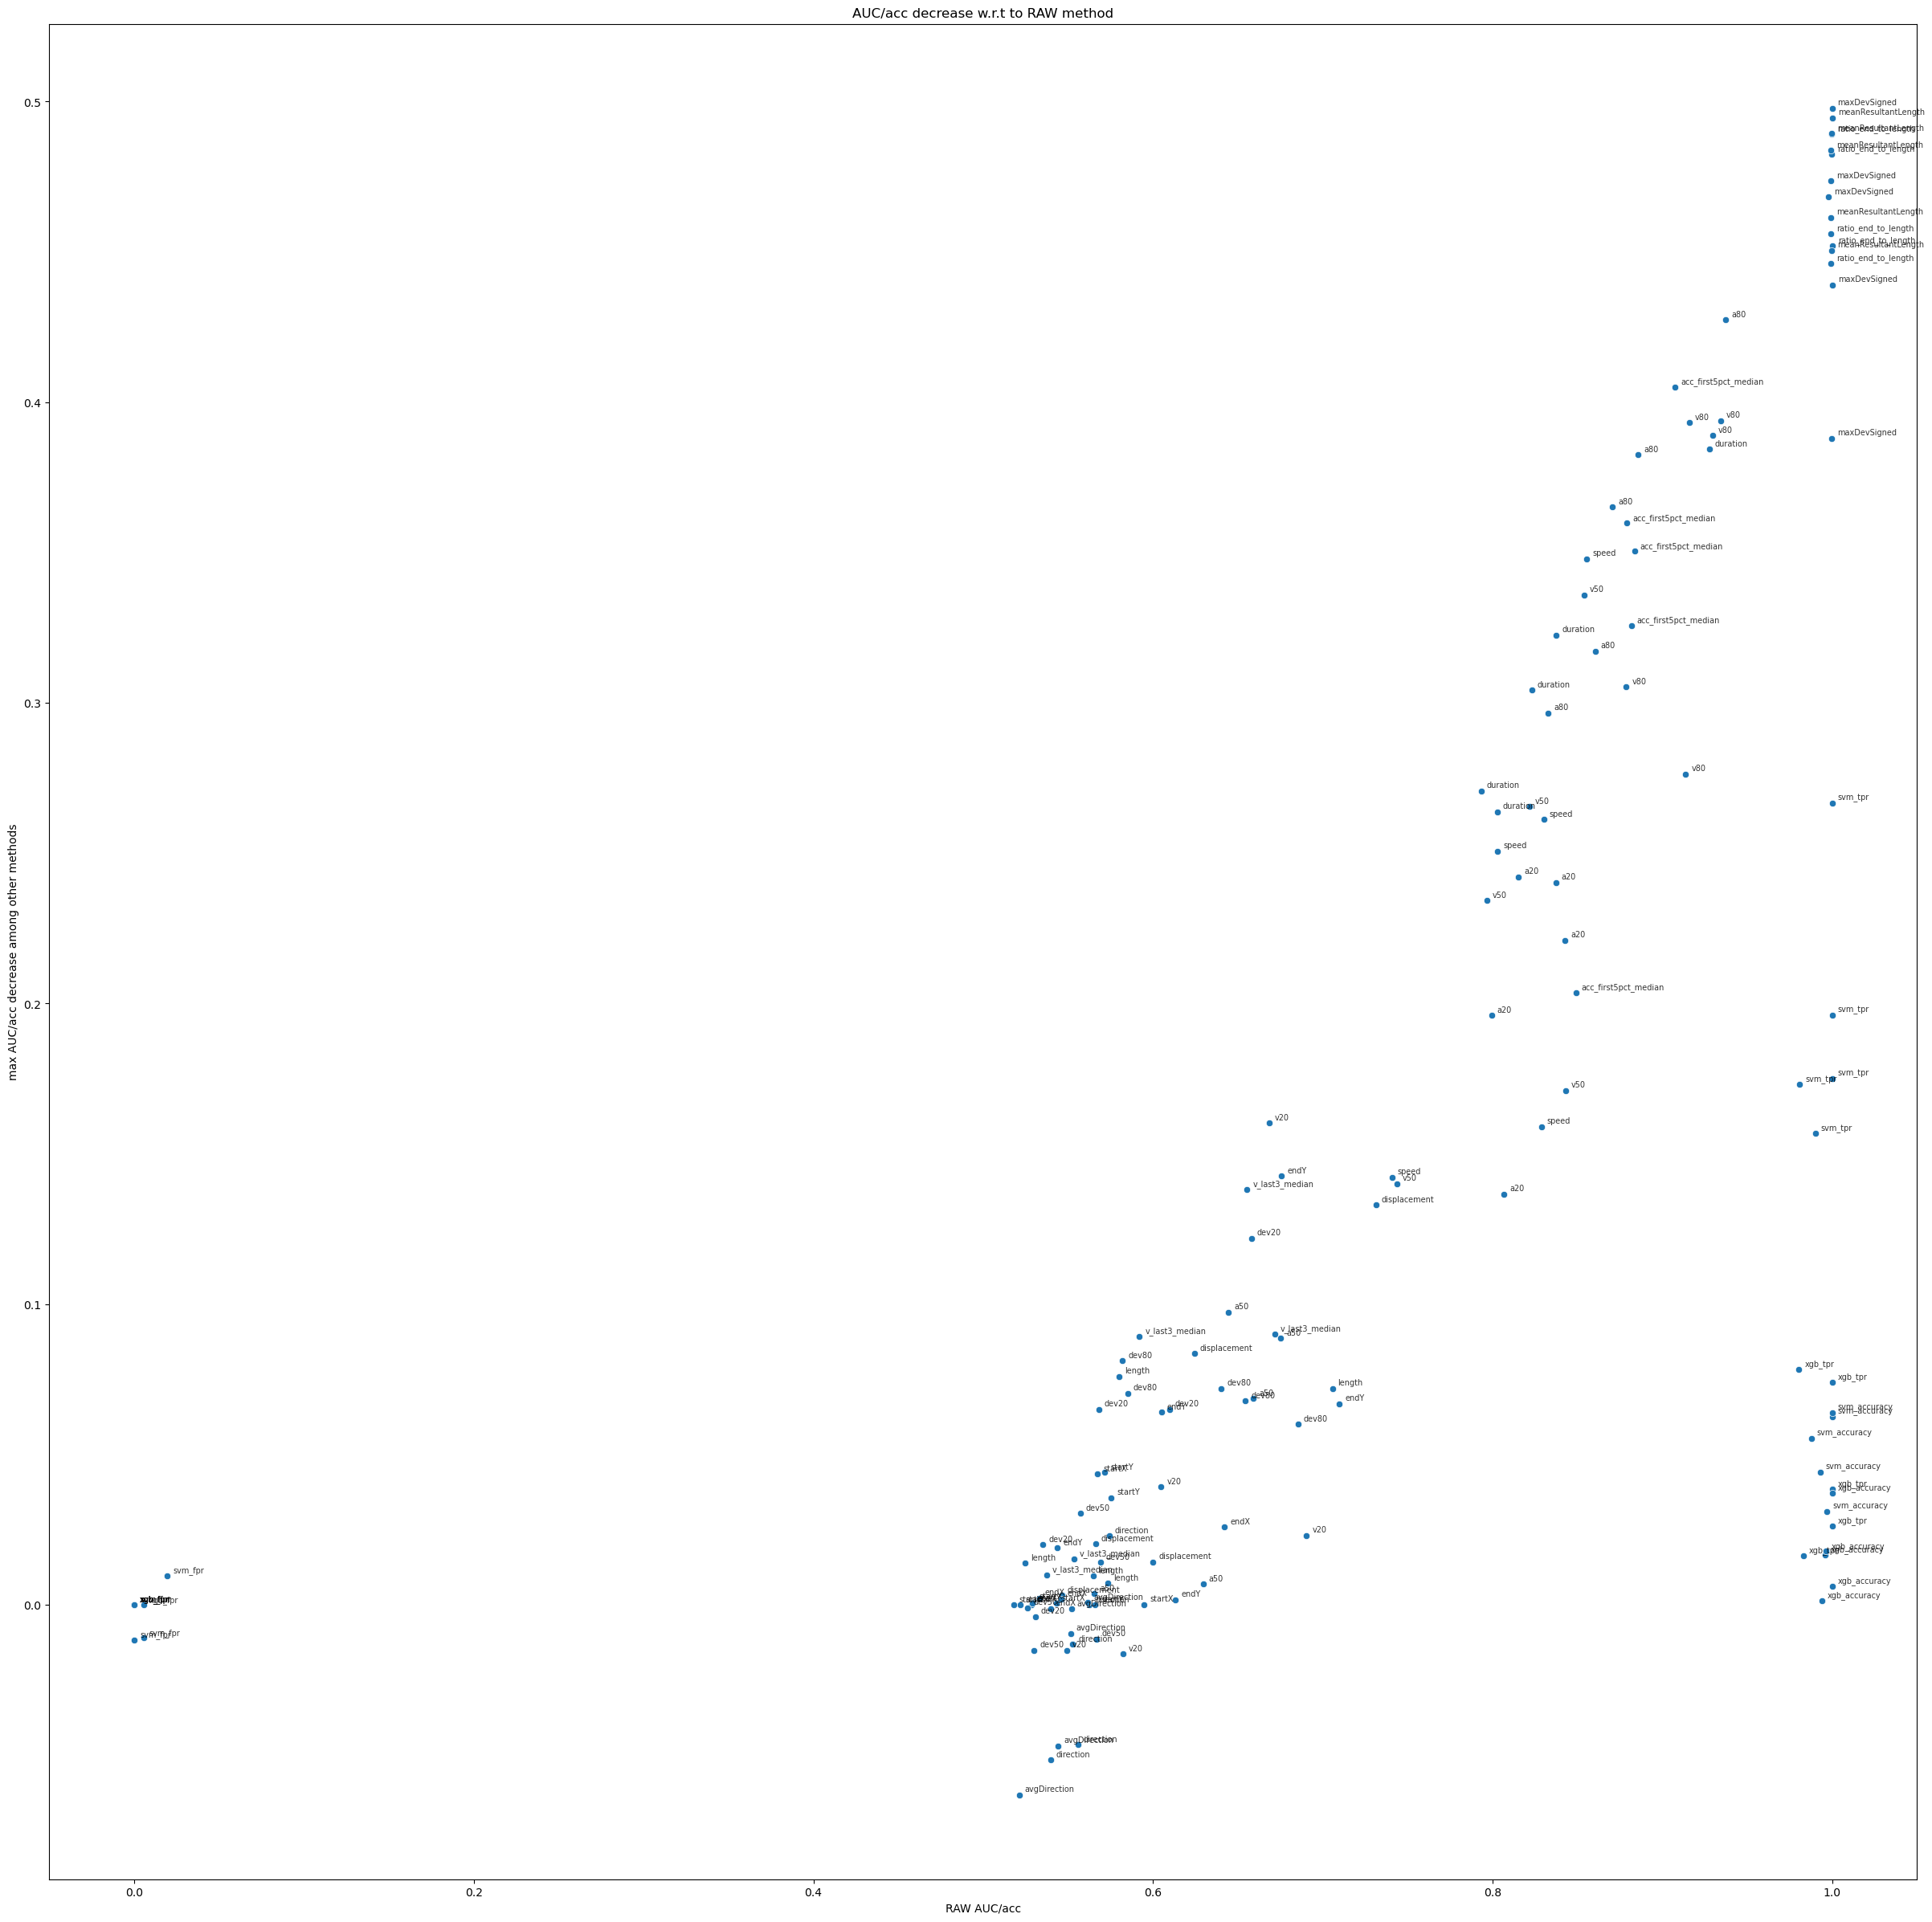

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(30, 30))
# plot the scatterplot, with x as the first element of added_value, y as the second element of added_value and label each point with the third element of added_value
# label each point with the third element of added_value
ax = sns.scatterplot(x=[v[0] for v in added_value], y=[v[1] for v in added_value])
for x, y, label, cluster_idx in added_value:
    ax.annotate(str(label), (x, y), textcoords="offset points", xytext=(5, 3), ha="left", fontsize=7, alpha=0.8)
plt.xlabel("RAW AUC/acc")
plt.ylabel("max AUC/acc decrease among other methods")
plt.title("AUC/acc decrease w.r.t to RAW method")

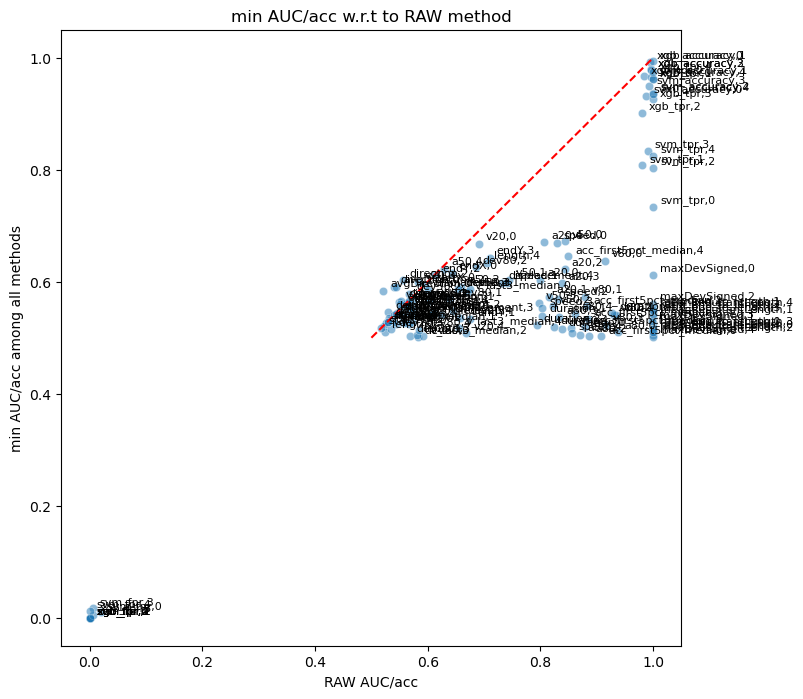

In [204]:
## Exploratory scatter plot — intermediate visualization of added_value
# Final Figure 4 reproduction is in the paired bar chart cell below
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 8))
# plot the scatterplot, with x as the first element of added_value, y as the second element of added_value and label each point with the third element of added_value
# label each point with the third element of added_value
ax = sns.scatterplot(x=[v[0] for v in added_value], y=[v[0] - v[1] for v in added_value], alpha=0.5)
for x, y, label, cluster_idx in added_value:
    ax.annotate(str(label) + "," + str(cluster_idx), (x, x - y), textcoords="offset points", xytext=(5, 3), ha="left", fontsize=8, alpha=1)
plt.xlabel("RAW AUC/acc")
plt.ylabel("min AUC/acc among all methods")
plt.title("min AUC/acc w.r.t to RAW method")
# draw a diagonal line y=x
plt.plot([0.5, 1], [0.5, 1], color='red', linestyle='--')

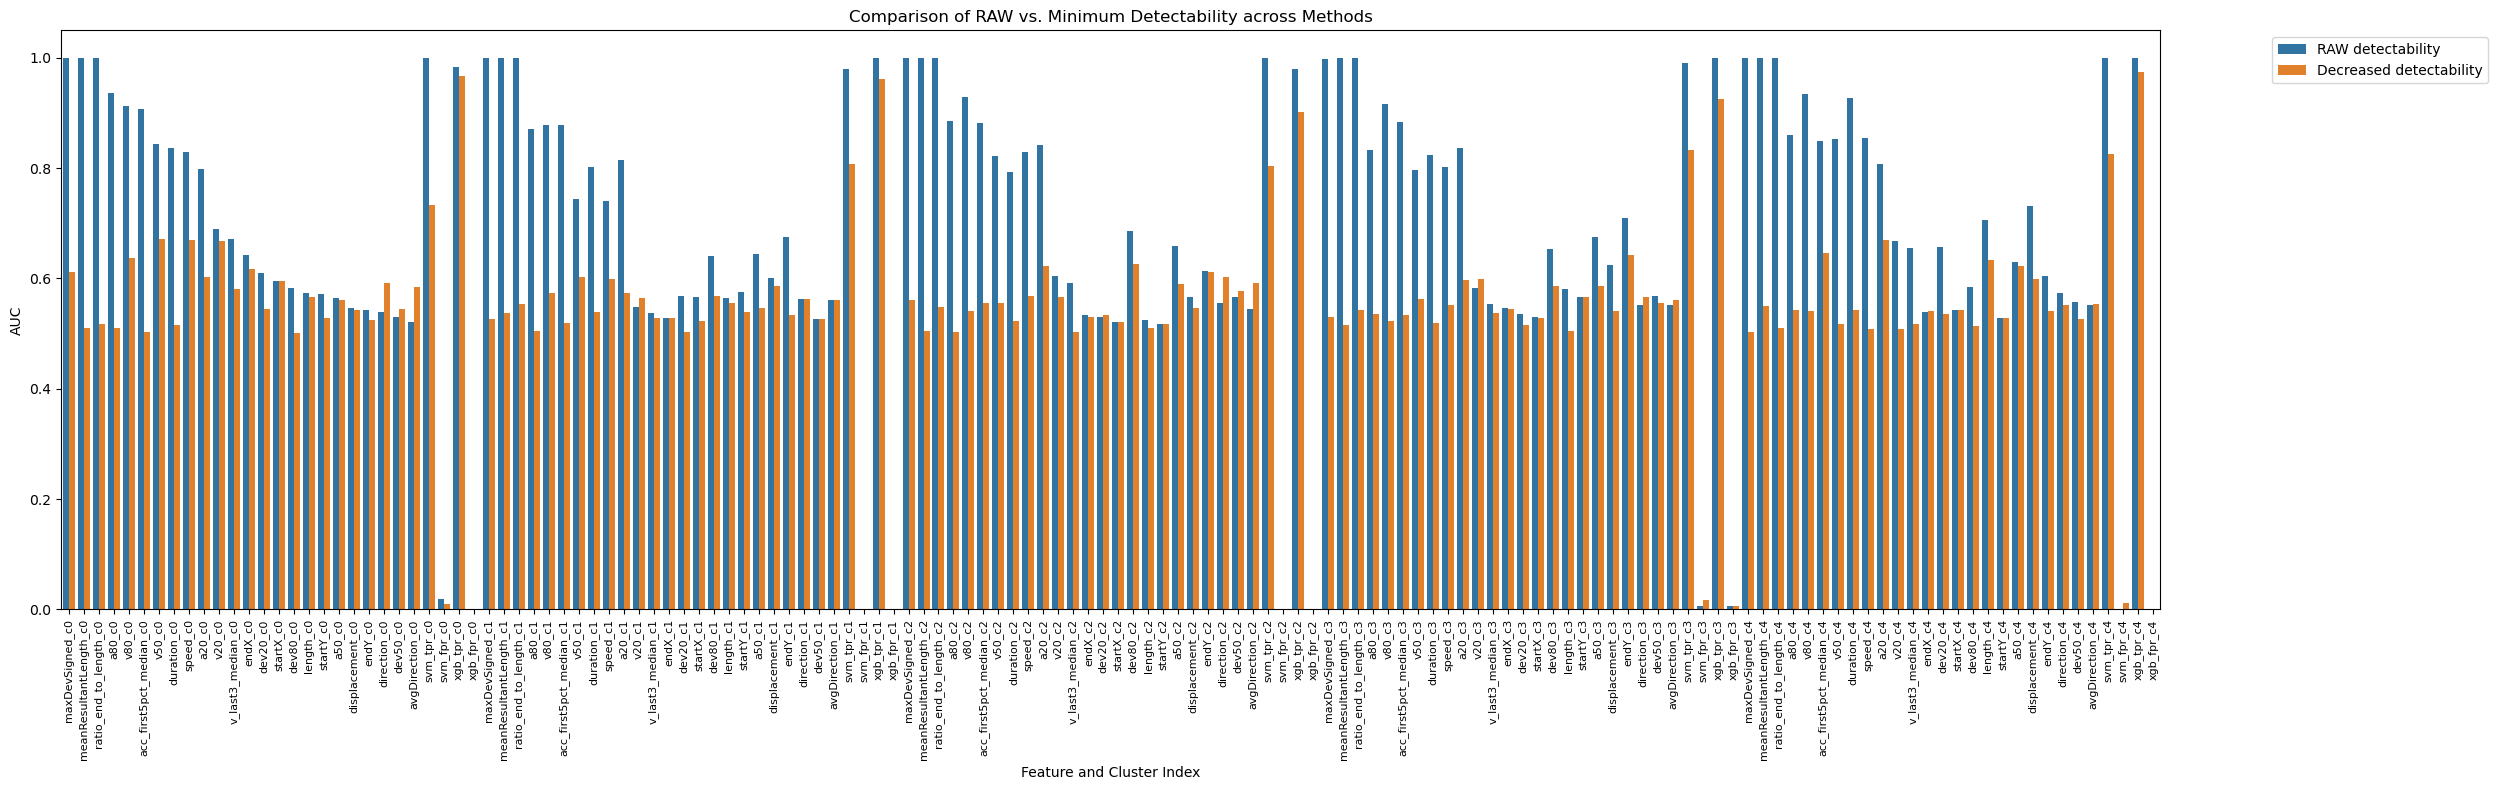

In [205]:
# Prepare the data for plotting
#ylim从0开始，用途：最直观地看每个特征的RAW detectability和下降幅度
plot_data = []
for raw_val, diff, feature, cluster_idx in added_value:
    label = f"{feature}_c{cluster_idx}"
    # skip the heavy classifiers xgb_accuracy and svm_accuracy
    if (feature == "xgb_accuracy") or (feature == "svm_accuracy"):
        continue
    plot_data.append({"label": label, "Value": raw_val, "Type": "RAW detectability"})
    plot_data.append({"label": label, "Value": raw_val - diff, "Type": "Decreased detectability"})

df_plot = pd.DataFrame(plot_data)

# Create the paired bar plot
plt.figure(figsize=(25, 8))
ax = sns.barplot(data=df_plot, x="label", y="Value", hue="Type")

plt.xticks(rotation=90, fontsize=8)
plt.xlabel("Feature and Cluster Index")
plt.ylabel("AUC")
plt.title("Comparison of RAW vs. Minimum Detectability across Methods")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



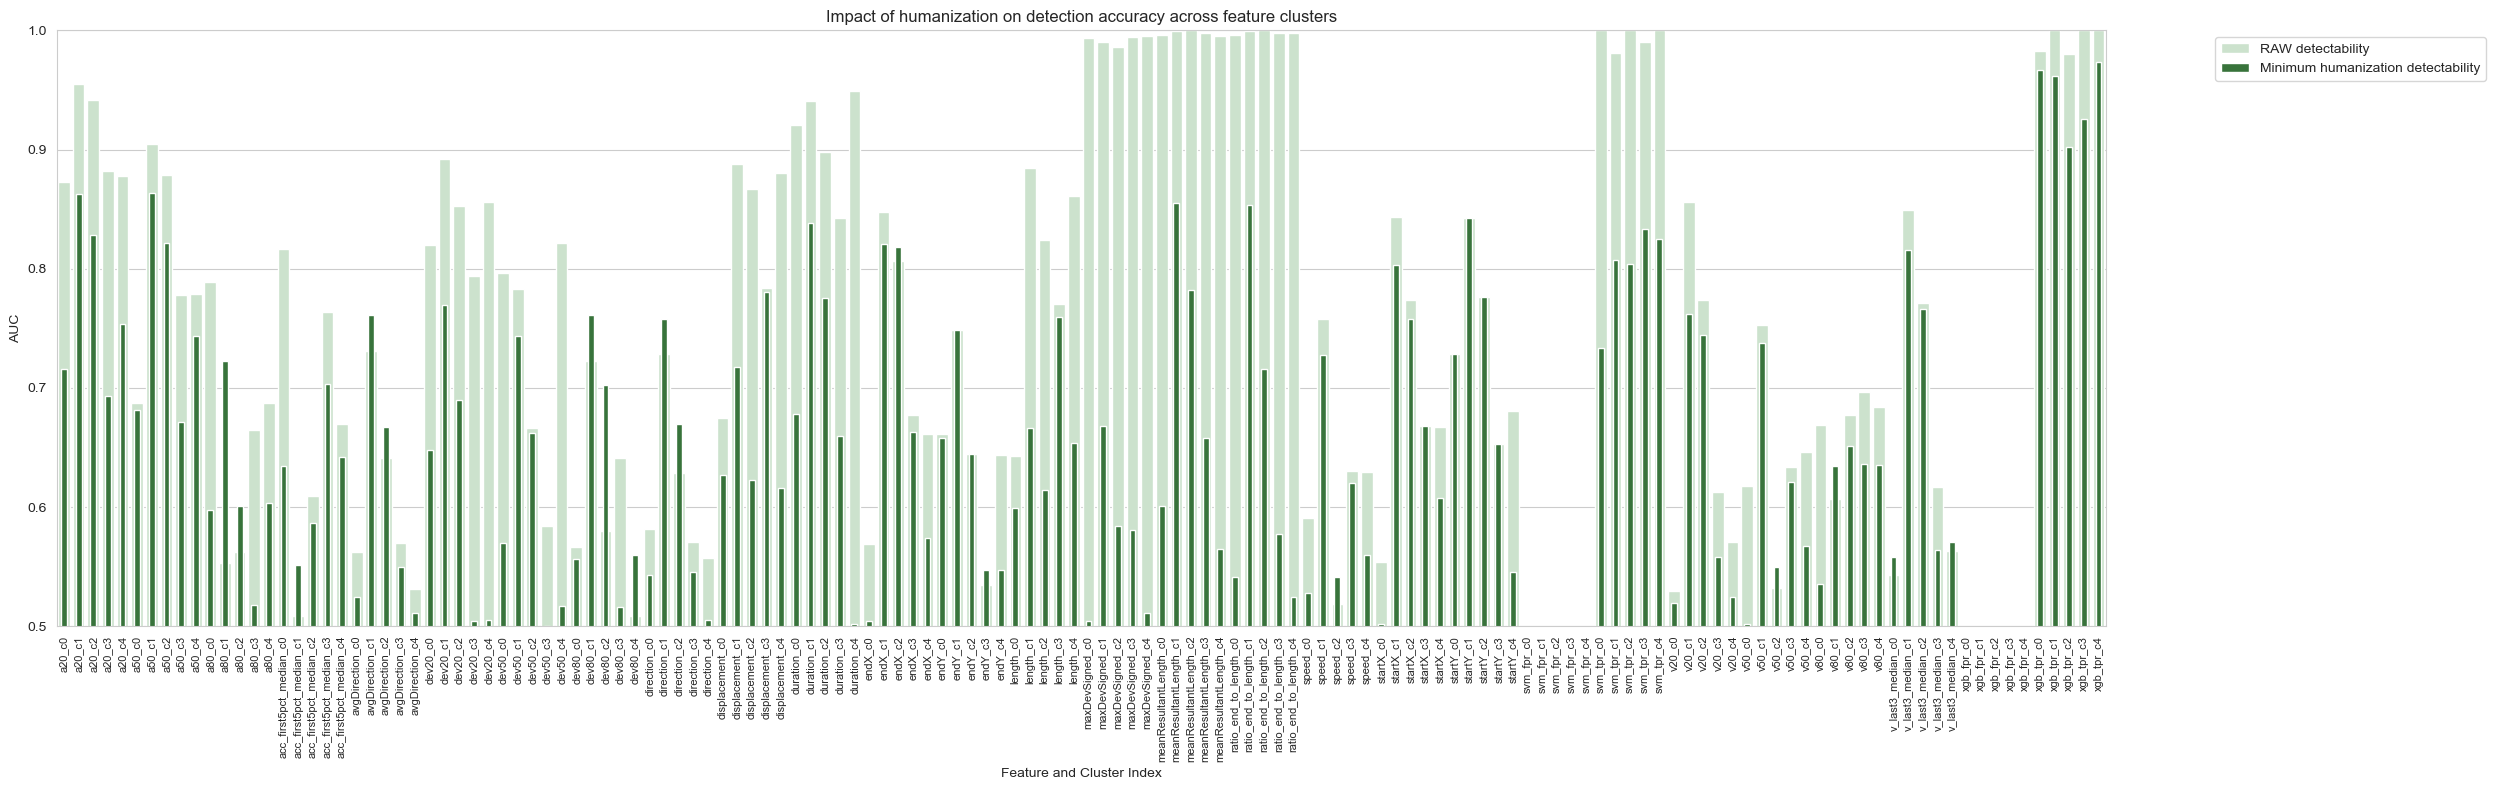

In [233]:
# Prepare the data for plotting
#Figure 4复现，ylim从0.5开始，聚焦在有意义的区间
plot_data = []
for raw_val, diff, feature, cluster_idx in added_value:
    label = f"{feature}_c{cluster_idx}"
    # skip the heavy classifiers xgb_accuracy and svm_accuracy
    if (feature == "xgb_accuracy") or (feature == "svm_accuracy"):
        continue
    plot_data.append({"label": label, "Value": raw_val, "Type": "RAW detectability"})
    plot_data.append({"label": label, "Value": raw_val - diff, "Type": "Decreased detectability"})
# sort plot_data by label
plot_data.sort(key=lambda x: x["label"])

df_plot = pd.DataFrame(plot_data)

# Create the paired bar plot
plt.figure(figsize=(25, 8))
ax = sns.barplot(
    data=df_plot[df_plot["Type"] == "RAW detectability"], 
    x="label", y="Value", 
    color="#c8e6c9",  # 浅绿
    label="RAW detectability"
)
sns.barplot(
    data=df_plot[df_plot["Type"] == "Decreased detectability"], 
    x="label", y="Value", 
    color="#2e7d32",  # 深绿
    label="Minimum humanization detectability",
    width=0.4
)
plt.ylim(0.5, 1.0)
plt.xticks(rotation=90, fontsize=8)
plt.xlabel("Feature and Cluster Index")
plt.ylabel("AUC")
plt.title("Impact of humanization on detection accuracy across feature clusters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [209]:
plt.savefig("results1202/figure4_reproduced.png", dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

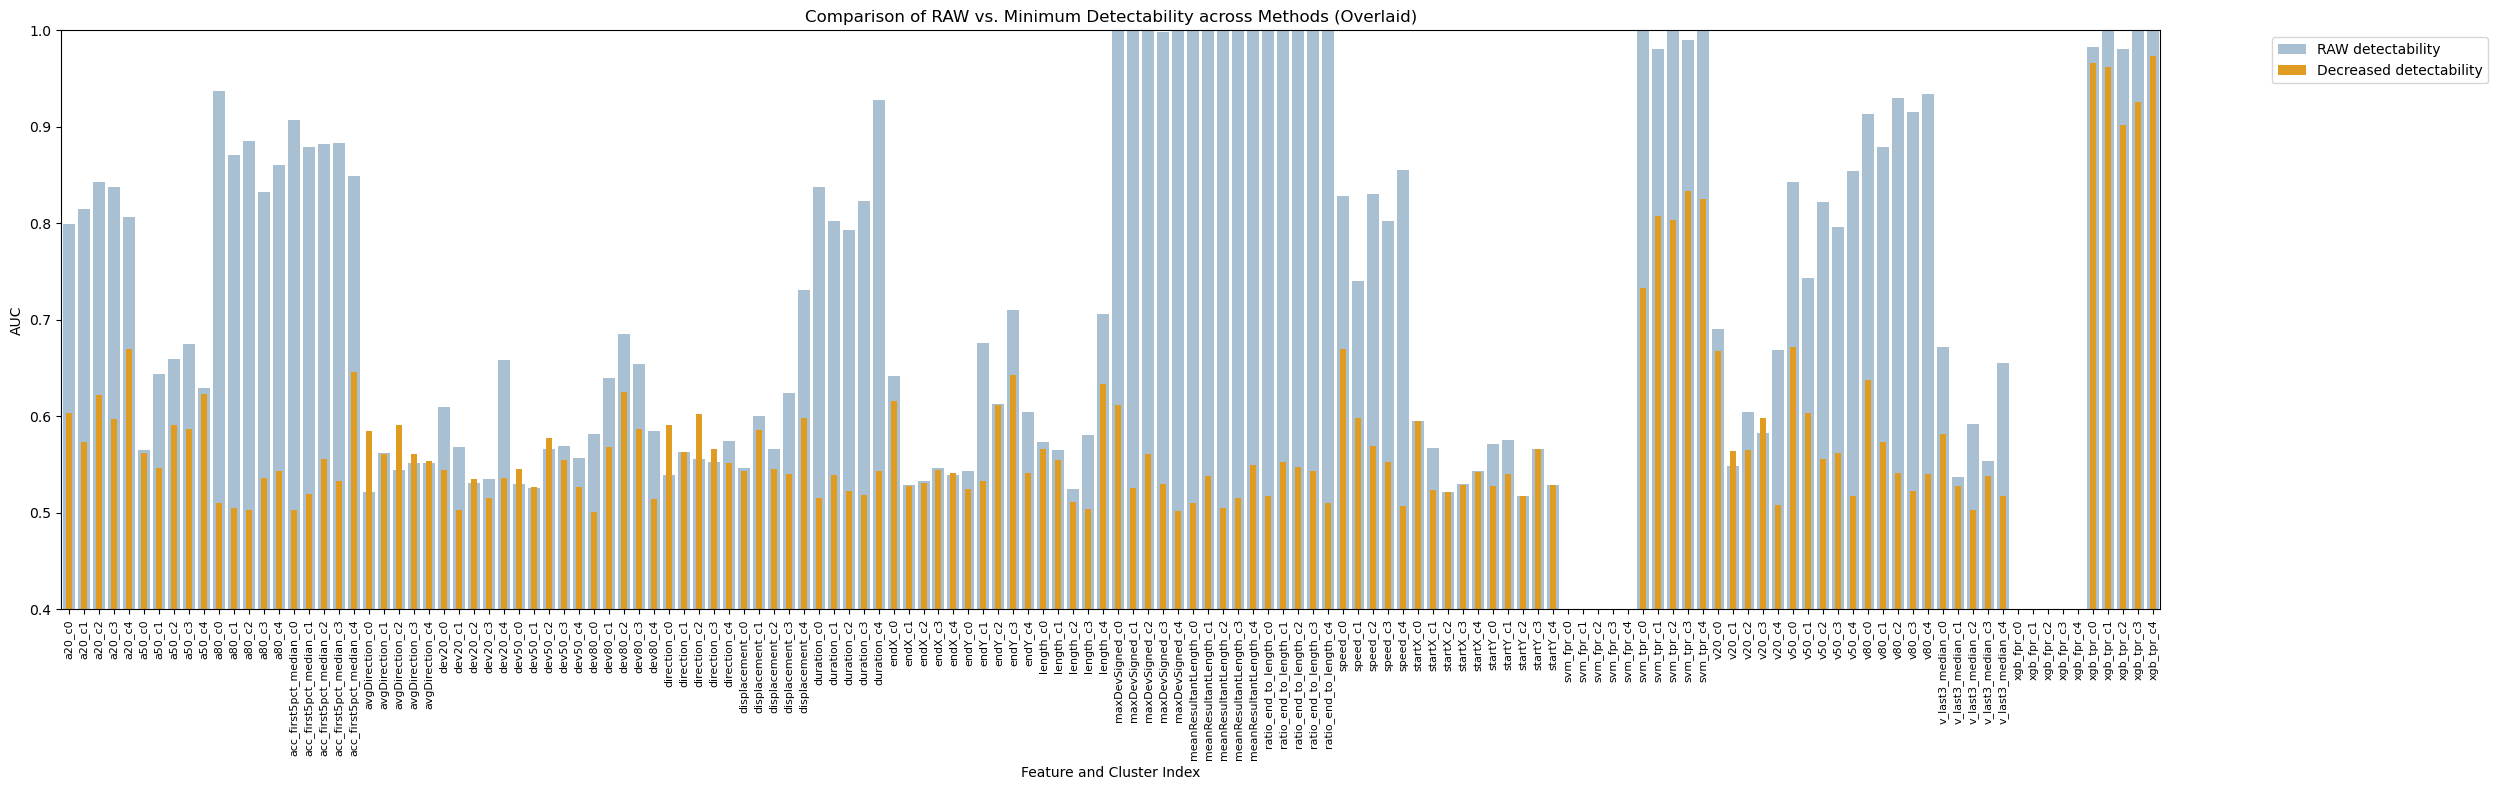

In [220]:
# Prepare the data for plotting
#ylim从0.4开始，作者自己的overlaid版本探索，介于第一和第二张之间
plot_data = []
for raw_val, diff, feature, cluster_idx in added_value:
    label = f"{feature}_c{cluster_idx}"
    # skip the heavy classifiers xgb_accuracy and svm_accuracy
    if (feature == "xgb_accuracy") or (feature == "svm_accuracy"):
        continue
    plot_data.append({"label": label, "Value": raw_val, "Type": "RAW detectability"})
    plot_data.append({"label": label, "Value": raw_val - diff, "Type": "Decreased detectability"})

df_plot = pd.DataFrame(plot_data)
df_plot.sort_values("label", inplace=True)

# Create the overlaid bar plot
plt.figure(figsize=(25, 8))

# Plot RAW detectability (wider bars in the background)
sns.barplot(
    data=df_plot[df_plot["Type"] == "RAW detectability"], 
    x="label", y="Value", color="steelblue", label="RAW detectability", alpha=0.5
)

# Plot Decreased detectability (narrower bars in the foreground)
# Using a smaller width ensures visibility even if Decreased > RAW (diff < 0)
sns.barplot(
    data=df_plot[df_plot["Type"] == "Decreased detectability"], 
    x="label", y="Value", color="orange", label="Decreased detectability", width=0.4
)

plt.xticks(rotation=90, fontsize=8)
plt.xlabel("Feature and Cluster Index")
plt.ylabel("AUC")
plt.title("Comparison of RAW vs. Minimum Detectability across Methods (Overlaid)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.4, 1)
plt.tight_layout()
plt.show()


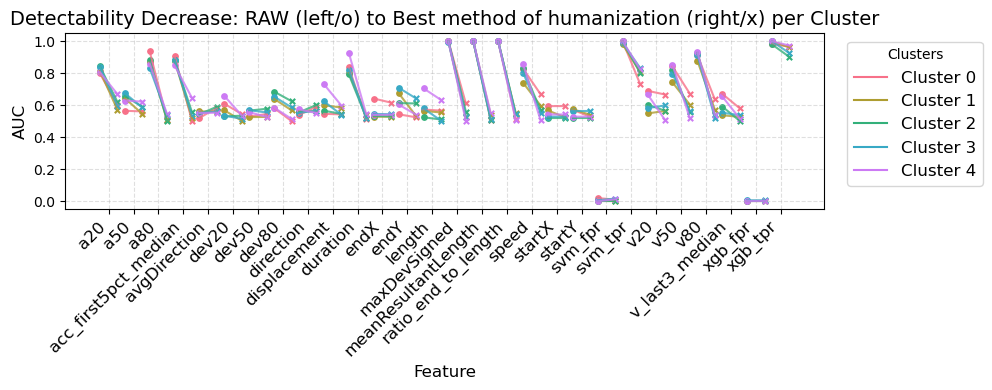

In [221]:
#slope chart的优势是能更直观地看出每个特征"下降了多少"（线段长度），而不只是看绝对值。
import seaborn as sns
import matplotlib.pyplot as plt

# Filter and prepare data
filtered_data = [v for v in added_value if v[2] not in ["xgb_accuracy", "svm_accuracy"]]
features = sorted(list(set(v[2] for v in filtered_data)))
feature_map = {feat: i for i, feat in enumerate(features)}
num_clusters = len(task_clusters)
colors = sns.color_palette("husl", num_clusters)

plt.figure(figsize=(10, 4))

# Plot segments for each cluster with a small horizontal offset
for cluster_idx in range(num_clusters):
    cluster_points = [v for v in filtered_data if v[3] == cluster_idx]
    if not cluster_points:
        continue
        
    # Calculate offset x-coordinates for this cluster
    center_offset = (cluster_idx - (num_clusters - 1) / 2) * 0.15
    slope_half_width = 0.35  # Controls the horizontal spread of the slope line

    x_starts, x_ends, y_starts, y_ends = [], [], [], []

    for v in cluster_points:
        feat_idx = feature_map[v[2]]
        raw_val = v[0]
        min_val = v[0] - v[1]
        
        # Define start (RAW) and end (Min) x-coordinates to create a slope
        x_start = feat_idx + center_offset * 0 - slope_half_width
        x_end = feat_idx + center_offset * 0 + slope_half_width
        
        # Draw the connecting line (slope)
        plt.plot([x_start, x_end], [raw_val, min_val], color=colors[cluster_idx], alpha=0.8, linewidth=1.5)
        
        x_starts.append(x_start)
        x_ends.append(x_end)
        y_starts.append(raw_val)
        y_ends.append(min_val)
    
    # Add markers at the ends
    plt.scatter(x_starts, y_starts, color=colors[cluster_idx], s=15, marker='o') # RAW
    plt.scatter(x_ends, y_ends, color=colors[cluster_idx], s=15, marker='x')   # Min Other

    # Dummy plot for legend
    plt.plot([], [], color=colors[cluster_idx], label=f"Cluster {cluster_idx}")

# Adjustable wrap width for long feature names
wrap_width = 100
def wrap_under_wrap_width(label: str, wrap_width: int) -> str:
    if len(label) <= wrap_width:
        return label
    return label[:wrap_width] + '\n' + wrap_under_wrap_width(label[wrap_width:], wrap_width)

wrapped_labels = [wrap_under_wrap_width(f, wrap_width) for f in features]
plt.xticks(range(len(features)), wrapped_labels, rotation=45,  fontsize=12, horizontalalignment='right')
plt.xlabel("Feature", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.title("Detectability Decrease: RAW (left/o) to Best method of humanization (right/x) per Cluster", fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Clusters", fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


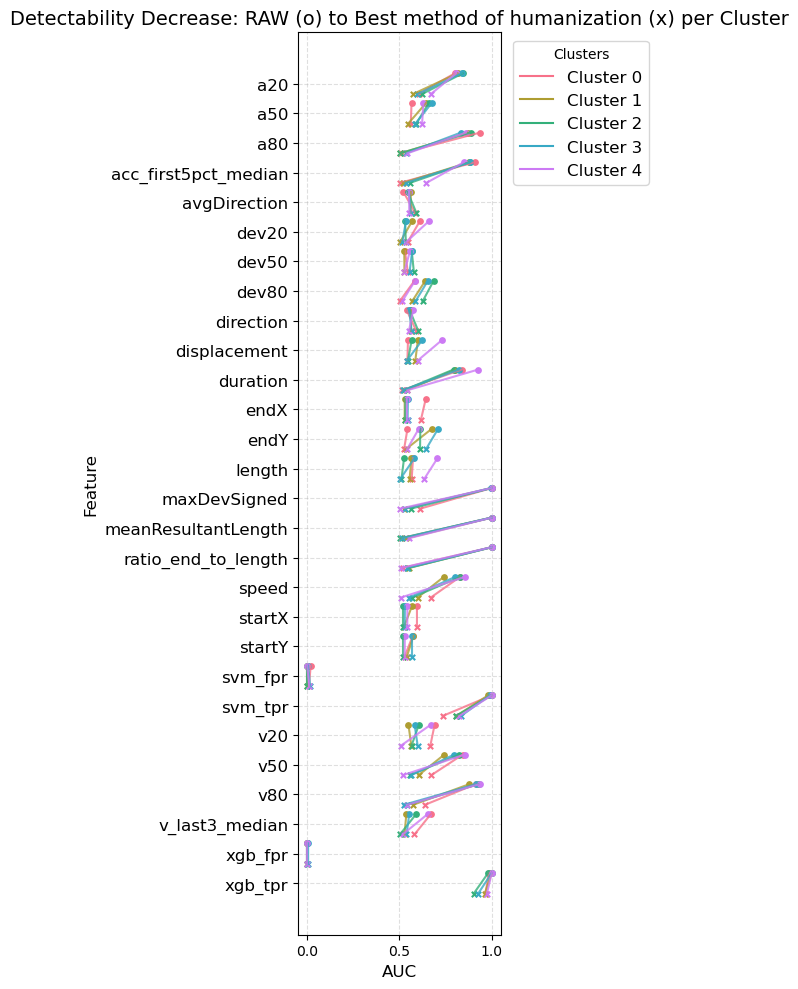

In [222]:
#把x轴和y轴互换了，特征名放在y轴，AUC值放在x轴，这样特征名可以水平显示，更容易阅读。
import seaborn as sns
import matplotlib.pyplot as plt

# Filter and prepare data
filtered_data = [v for v in added_value if v[2] not in ["xgb_accuracy", "svm_accuracy"]]
features = sorted(list(set(v[2] for v in filtered_data)))
feature_map = {feat: i for i, feat in enumerate(features)}
num_clusters = len(task_clusters)
colors = sns.color_palette("husl", num_clusters)

# Swapped figsize for vertical orientation
plt.figure(figsize=(6, 10))

# Plot segments for each cluster with a small vertical offset
for cluster_idx in range(num_clusters):
    cluster_points = [v for v in filtered_data if v[3] == cluster_idx]
    if not cluster_points:
        continue
        
    # Calculate offset y-coordinates for this cluster
    center_offset = (cluster_idx - (num_clusters - 1) / 2) * 0.15
    slope_half_height = 0.35  # Controls the vertical spread of the slope line

    x_starts, x_ends, y_starts, y_ends = [], [], [], []

    for v in cluster_points:
        feat_idx = feature_map[v[2]]
        raw_val = v[0]
        min_val = v[0] - v[1]
        
        # Define start (RAW) and end (Min) y-coordinates to create a slope
        # Swapping logic: feat_idx is now on the Y axis
        y_start = feat_idx + center_offset * 0 - slope_half_height
        y_end = feat_idx + center_offset * 0 + slope_half_height
        
        # Draw the connecting line (slope)
        plt.plot([raw_val, min_val], [y_start, y_end], color=colors[cluster_idx], alpha=0.8, linewidth=1.5)
        
        x_starts.append(raw_val)
        x_ends.append(min_val)
        y_starts.append(y_start)
        y_ends.append(y_end)
    
    # Add markers at the ends (swapped x and y)
    plt.scatter(x_starts, y_starts, color=colors[cluster_idx], s=15, marker='o') # RAW
    plt.scatter(x_ends, y_ends, color=colors[cluster_idx], s=15, marker='x')   # Min Other

    # Dummy plot for legend
    plt.plot([], [], color=colors[cluster_idx], label=f"Cluster {cluster_idx}")

# Adjustable wrap width for long feature names
wrap_width = 20
def wrap_under_wrap_width(label: str, wrap_width: int) -> str:
    if len(label) <= wrap_width:
        return label
    return label[:wrap_width] + '\n' + wrap_under_wrap_width(label[wrap_width:], wrap_width)

wrapped_labels = [wrap_under_wrap_width(f, wrap_width) for f in features]
plt.yticks(range(len(features)), wrapped_labels, fontsize=12)
plt.gca().invert_yaxis() # Invert to keep the first features at the top
plt.ylabel("Feature", fontsize=12)
plt.xlabel("AUC", fontsize=12)
plt.title("Detectability Decrease: RAW (o) to Best method of humanization (x) per Cluster", fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Clusters", fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


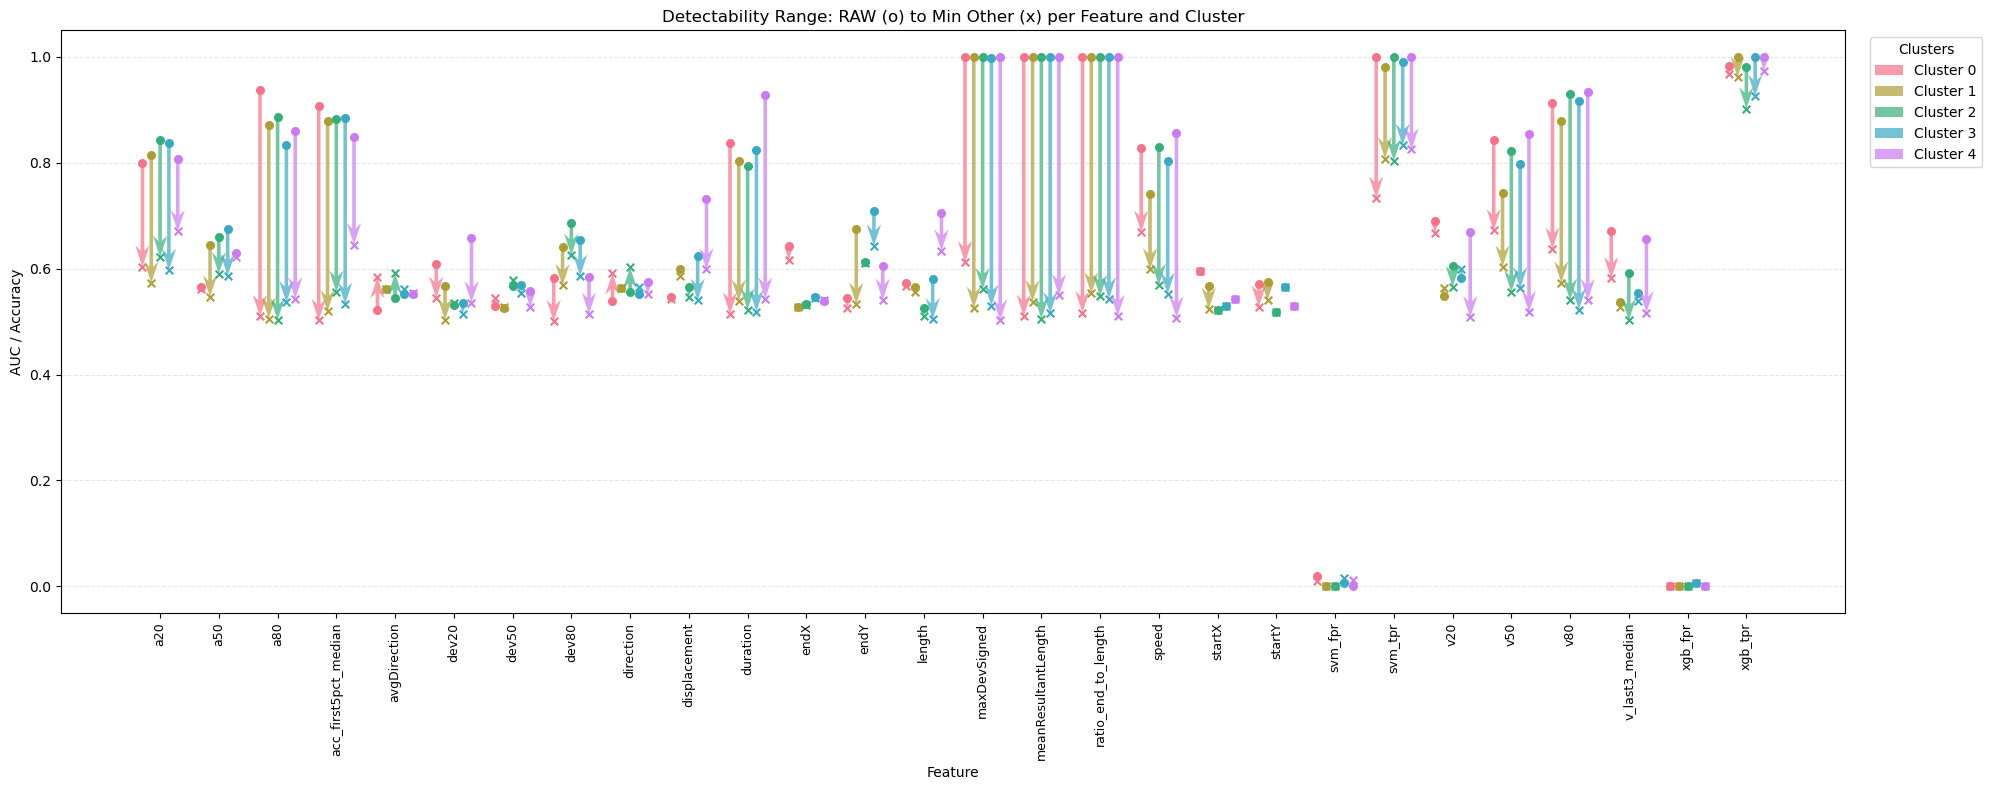

In [223]:
# Filter out heavy classifiers
#第三种可视化变体
filtered_data = [v for v in added_value if v[2] not in ["xgb_accuracy", "svm_accuracy"]]
features = sorted(list(set(v[2] for v in filtered_data)))
feature_to_idx = {feat: i for i, feat in enumerate(features)}
num_clusters = len(task_clusters)
colors = sns.color_palette("husl", num_clusters)

plt.figure(figsize=(20, 8))

for cluster_idx in range(num_clusters):
    cluster_subset = [v for v in filtered_data if v[3] == cluster_idx]
    if not cluster_subset:
        continue
    
    # Apply a small horizontal offset so clusters for the same feature are distinguishable
    x_offset = (cluster_idx - (num_clusters - 1) / 2) * 0.15
    
    x_coords = [feature_to_idx[v[2]] + x_offset for v in cluster_subset]
    y_raw = [v[0] for v in cluster_subset]
    y_min = [v[0] - v[1] for v in cluster_subset]
    
    # Use quiver to draw arrows from RAW (top) to Min Other (bottom) to stress the decrease
    dy = [ymin - yraw for ymin, yraw in zip(y_min, y_raw)]
    plt.quiver(x_coords, y_raw, [0]*len(x_coords), dy, 
               angles='xy', scale_units='xy', scale=1, color=colors[cluster_idx], 
               width=0.002, headwidth=4, headlength=6, alpha=0.7, label=f"Cluster {cluster_idx}")
    
    # Mark the endpoints: 'o' for RAW (top), 'x' for Min Other (bottom)
    plt.scatter(x_coords, y_raw, color=colors[cluster_idx], s=30, marker='o')
    plt.scatter(x_coords, y_min, color=colors[cluster_idx], s=30, marker='x')

plt.xticks(range(len(features)), features, rotation=90, fontsize=9)
plt.xlabel("Feature")
plt.ylabel("AUC / Accuracy")
plt.title("Detectability Range: RAW (o) to Min Other (x) per Feature and Cluster")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Clusters")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


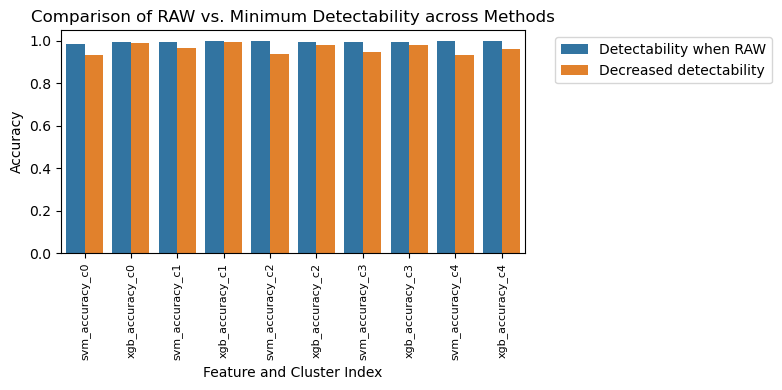

In [224]:
# Prepare the data for plotting
#专门展示"综合分类器在最优humanization下依然保持高检测率"这个发现。
plot_data = []
for raw_val, diff, feature, cluster_idx in added_value:
    label = f"{feature}_c{cluster_idx}"
    # skip the heavy classifiers xgb_accuracy and svm_accuracy
    if (feature == "xgb_accuracy") or (feature == "svm_accuracy"):
        plot_data.append({"label": label, "Value": raw_val, "Type": "Detectability when RAW"})
        plot_data.append({"label": label, "Value": raw_val - diff, "Type": "Decreased detectability"})

df_plot = pd.DataFrame(plot_data)

# Create the paired bar plot
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=df_plot, x="label", y="Value", hue="Type")

plt.xticks(rotation=90, fontsize=8)
plt.xlabel("Feature and Cluster Index")
plt.ylabel("Accuracy")
plt.title("Comparison of RAW vs. Minimum Detectability across Methods")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'AUC/acc decrease w.r.t to RAW method')

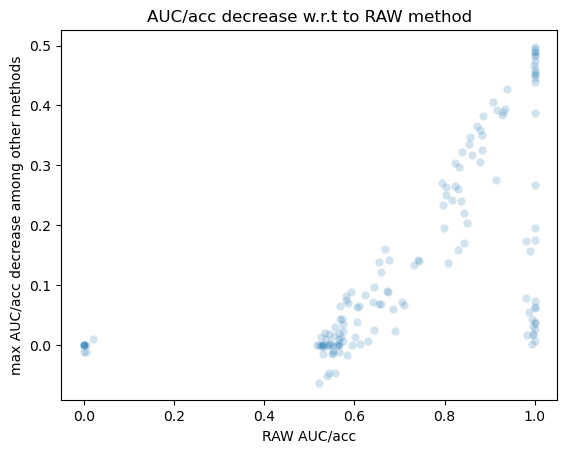

In [225]:
#保留散点本身，加了alpha=0.2让密度分布更清楚。
sns.scatterplot(x=[x[0] for x in added_value], y=[x[1] for x in added_value], alpha=0.2)
plt.xlabel("RAW AUC/acc")
plt.ylabel("max AUC/acc decrease among other methods")
plt.title("AUC/acc decrease w.r.t to RAW method")

## svm and xgboost accuracy goes up as more feature is added

In [ ]:
# Skipped: Figure 5 data generation
# Requires ~1200 SVM/XGBoost training runs (computationally prohibitive)
# Also depends on draw_motion_event2 module not included in public release

## tap comparison

In [270]:
#更聚焦地验证：人性化后的agent在tap duration分布上是否更接近人类，去掉了RAW agent（因为RAW的分布太极端，会压缩其他曲线的可读性）。
ranged_swipe_generator

functools.partial(<function ranged_modified_generator_without_session_timestamp at 0x14d3d2e80>, formated_data_timestamps=    app                                          task_name            user1  \
0    jd                   搜索“无线耳机”，打开一个非自营卖家的商品页面，查看其一条评价。  20251012_104825   
1    jd              找一个价格在50到100元之间的移动电源，加入购物车，然后从购物车中移除。  20251012_105107   
2    jd                  使用应用的对比功能，比较两个不同品牌的手机壳，重点关注价格和材质。  20251012_105412   
3    jd                     找到“百亿补贴”专区，选择一个补贴商品，查看其折扣价与原价。  20251012_105701   
4    jd            选择一种日用品（例如洗发水），添加收货地址，进入订单确认页面，但不要提交支付。  20251012_105947   
..   ..                                                ...              ...   
111  知乎              搜索“编程猫”，搜索用户，并进入结果中一个用户的主页，查看其最新发布的文章  20251115_185627   
112  知乎  搜索“编程猫”，搜索用户，并进入结果中一个用户的主页，查看其最新发布的文章，点赞该文章，点击...  20251115_185802   
113  知乎                                         搜索“人工智能”专栏  20251115_190001   
114  知乎              搜索“人工智能”专栏，查看一篇专栏中的文章并评论“hello world”  20251115_190056   
115  知乎  

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191019.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_191303.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_194143.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

Text(0.5, 1.0, 'Tap duration distribution by type (overlaid)')

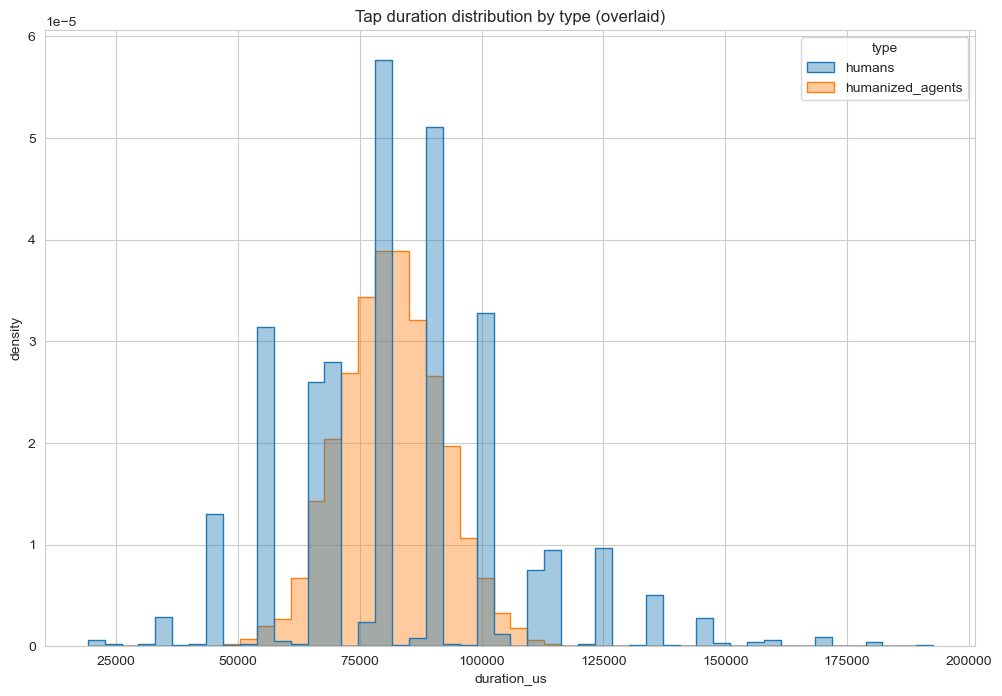

In [271]:
#humanized agents的tap duration分布从原来的near-zero spike（RAW时几乎贴着0）变成了更接近正态分布的形状，跟human的分布显著重叠——这正是论文里humanization策略有效性的直接证据之一。
from analysis.processing.tap_duration_extract import leave_taps


tap_filtering_and_modification_function=partial(leave_taps, tap_len_max=3)


all_human_iterator = (ranged_tap_generator(participants=humans))
all_rotate_fit_iterator = (ranged_tap_generator(
    participants=humanized_agents))



from analysis.lib.motionevent_classes import FingerEvent
def yield_label_together() -> List[Tuple[str, List[List[FingerEvent]]]]:
    return [("humans", all_human_iterator), ("humanized_agents", all_rotate_fit_iterator)]

from analysis.processing.tap_duration_extract import build_durations_dataframe
df_durations = build_durations_dataframe(yield_label_together())
plt.figure(figsize=(12, 8))
sns.histplot(
    data=df_durations[df_durations["duration_us"] < 200_000],
    x="duration_us",
    hue="type",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.4,
)
plt.xlabel("duration_us")
plt.ylabel("density")
plt.title("Tap duration distribution by type (overlaid)")

## Plot acc instead of auc


In [227]:
# 是Section 3.5的ACC版本的变体版本 - 使用ACC替代AUC，保存分类器供后续使用，ACC同样也是Figure 4的复现
# Note: draw_motion_event2 not included in public release, import removed
from typing import Dict, List, Tuple
from analysis.processing.calculate_roc_auc_from_feature import make_feature_and_learner_table_but_acc as make_feature_and_learner_table_acc
from analysis.processing.calculate_roc_auc_from_feature import compute_acc_per_feature_using_x_1_x_point_on_roc_auc as acc_obtain_function
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import sklearn

make_feature_and_learner_table_acc = partial(make_feature_and_learner_table_acc, acc_obtain_function=acc_obtain_function)

result_csv_acc = pd.DataFrame()

raw_swipe_classifiers_to_use_for_clusters: Dict[int, Tuple[Pipeline, XGBClassifier]] = {}
humanized_swipe_classifiers_to_use_for_clusters: Dict[int, Tuple[Pipeline, XGBClassifier]] = {}

for cluster_idx, task_cluster in enumerate(task_clusters):
    list_to_concat: List[pd.DataFrame] = []

    try:
        non_humanized_result_csv_acc, svm_pipeline, xgb_pipeline = make_feature_and_learner_table_acc(
            task_cluster_id=cluster_idx,
            method_name="RAW",
            pos_iterator=("non_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(non_humanized_result_csv_acc)
        raw_swipe_classifiers_to_use_for_clusters[cluster_idx] = (svm_pipeline, xgb_pipeline)
    except ValueError:
        print("Warning: No valid data for non_humanized_agents vs humans for task", task_cluster)

    try:
        humanized_result_csv_acc, svm_pipeline, xgb_pipeline = make_feature_and_learner_table_acc(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match",
            pos_iterator=("humanized_agents", ranged_swipe_generator(
                participants=humanized_agents, index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(humanized_result_csv_acc)
        humanized_swipe_classifiers_to_use_for_clusters[cluster_idx] = (svm_pipeline, xgb_pipeline)
    except ValueError:
        print("Warning: No valid data for humanized_agents vs humans for task", task_cluster)

    try:
        fake_humanized_result_csv_acc, _, _ = make_feature_and_learner_table_acc(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match_disturbance",
            pos_iterator=("fake_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=static_fit_effort_provider.humanity_disturbance)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv_acc)
    except ValueError:
        print("Warning: No valid data for fake_humanized_agents vs humans for task", task_cluster)

    try:
        fake_humanized_result_csv_acc_2, _, _ = make_feature_and_learner_table_acc(
            task_cluster_id=cluster_idx,
            method_name="b_spline_disturbance",
            pos_iterator=("fake_humanized_agents_b_spline", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=b_spline_faker)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv_acc_2)
    except ValueError:
        print("Warning: No valid data for fake_humanized_agents_b_spline vs humans for task", task_cluster)

    try:
        unhumanized_result_csv_acc, _, _ = make_feature_and_learner_table_acc(
            task_cluster_id=cluster_idx,
            method_name="unhumanized_agents",
            pos_iterator=("unhumanized_agents", ranged_swipe_generator(
                participants=humanized_agents, index_range=task_cluster,
                humanity_disturbance=raw_faker)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        ) 
        list_to_concat.append(unhumanized_result_csv_acc)
    except (ValueError, TypeError):
        print("Skipped unhumanized_agents: raw_faker signature incompatible with current bot_line_fit API")

    try:
        rot_humanized_result_csv_acc, _, _ = make_feature_and_learner_table_acc(
            task_cluster_id=cluster_idx,
            method_name="rotated_humanized_agents",
            pos_iterator=("rotated_humanized_agents", ranged_swipe_generator(
                participants=rot_humanized_agents, index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(rot_humanized_result_csv_acc)
    except ValueError:
        print("Warning: No valid data for rotated_humanized_agents vs humans for task", task_cluster)

    try:
        fake_rot_tap_result_csv_acc, _, _ = make_feature_and_learner_table_acc(
            task_cluster_id=cluster_idx,
            method_name="fake_rotated_tap_humanized_agents",
            pos_iterator=("fake_rotated_tap_humanized_agents", ranged_swipe_generator(
                participants=fake_rot_tap_humanized_agents, index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_rot_tap_result_csv_acc)
    except ValueError:
        print("Warning: No valid data for fake_rotated_tap_humanized_agents vs humans for task", task_cluster)

    result_csv_acc = pd.concat(
        [result_csv_acc] + list_to_concat,
        axis=1
    )

result_csv_acc.T.to_csv("results0125/final_acc_and_learner_results_0125.csv")
print("Done. Shape:", result_csv_acc.shape)

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

{'svm_accuracy': 0.9876543209876543, 'xgb_accuracy': 0.9938271604938271, 'svm_test_metrics': BinaryClassificationMetrics(TP=59, FP=2, TN=101, FN=0), 'xgb_test_metrics': BinaryClassificationMetrics(TP=58, FP=0, TN=103, FN=1)}


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_073155.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 6 complete samples from all 7 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_093034.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 5 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251204_020956.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 7 complete samples from all 8 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gest

{'svm_accuracy': 0.9323308270676691, 'xgb_accuracy': 0.9924812030075187, 'svm_test_metrics': BinaryClassificationMetrics(TP=22, FP=1, TN=102, FN=8), 'xgb_test_metrics': BinaryClassificationMetrics(TP=29, FP=0, TN=103, FN=1)}


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

...

{'svm_accuracy': 0.984, 'xgb_accuracy': 0.984, 'svm_test_metrics': BinaryClassificationMetrics(TP=39, FP=1, TN=84, FN=1), 'xgb_test_metrics': BinaryClassificationMetrics(TP=40, FP=2, TN=83, FN=0)}
Skipped unhumanized_agents: raw_faker signature incompatible with current bot_line_fit API


Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260121_203545.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 9 complete samples from all 10 samples in the generated trace.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155555.log, which is unexpected and cu

{'svm_accuracy': 0.9789473684210527, 'xgb_accuracy': 0.9894736842105263, 'svm_test_metrics': BinaryClassificationMetrics(TP=8, FP=0, TN=85, FN=2), 'xgb_test_metrics': BinaryClassificationMetrics(TP=9, FP=0, TN=85, FN=1)}


Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260124_223459.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 8. Discarding the last incomplete trace.
Error processing file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260125_002007.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 00000000, len(current_gesture): 12. Discarding the last incomplete trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20260123_055135.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 97 complete samples from all 98 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_2026012

{'svm_accuracy': 0.9974657881398885, 'xgb_accuracy': 0.9989863152559554, 'svm_test_metrics': BinaryClassificationMetrics(TP=1885, FP=1, TN=83, FN=4), 'xgb_test_metrics': BinaryClassificationMetrics(TP=1888, FP=1, TN=83, FN=1)}
Done. Shape: (30, 30)


In [228]:
result_csv_acc

,"(0, RAW)","(0, rotation_and_match)","(0, rotation_and_match_disturbance)","(0, b_spline_disturbance)","(0, rotated_humanized_agents)","(0, fake_rotated_tap_humanized_agents)","(1, RAW)","(1, rotation_and_match)","(1, rotation_and_match_disturbance)","(1, b_spline_disturbance)",...,"(3, rotation_and_match_disturbance)","(3, b_spline_disturbance)","(3, rotated_humanized_agents)","(3, fake_rotated_tap_humanized_agents)","(4, RAW)","(4, rotation_and_match)","(4, rotation_and_match_disturbance)","(4, b_spline_disturbance)","(4, rotated_humanized_agents)","(4, fake_rotated_tap_humanized_agents)"
feature,,,,,,,,,,,,,,,,,,,,,
meanResultantLength,0.995760,0.716616,0.604256,0.600675,0.634035,0.999747,0.999464,0.874357,0.855010,0.893040,...,0.658331,0.660252,0.843122,0.999182,0.995380,0.565156,0.623226,0.582988,0.890216,0.999672
ratio_end_to_length,0.995760,0.712843,0.567758,0.541270,0.615635,0.999750,0.999464,0.879308,0.862741,0.853144,...,0.656405,0.577564,0.843122,0.999195,0.997696,0.590979,0.630075,0.524370,0.871527,0.999672
maxDevSigned,0.993479,0.646362,0.504031,0.604183,0.748521,0.878824,0.990314,0.667739,0.841054,0.673387,...,0.648656,0.581156,0.830266,0.685529,0.994960,0.562228,0.722769,0.510936,0.802901,0.825726
duration,0.920443,0.812118,0.677792,0.891332,0.615635,0.918194,0.940671,0.838518,0.862295,0.957015,...,0.659292,0.882896,0.862023,0.895891,0.949041,0.501874,0.745767,0.961684,0.923514,0.842172
a20,0.872514,0.873524,0.716155,0.806035,0.533261,0.927331,0.955008,0.937588,0.862741,0.930271,...,0.693151,0.813184,0.883508,0.821737,0.877467,0.768016,0.753236,0.850146,0.961703,0.875407
dev20,0.819816,0.755586,0.647792,0.701981,0.635231,0.955673,0.891908,0.796079,0.769816,0.840054,...,0.504646,0.604681,0.746320,0.927249,0.856342,0.505619,0.597473,0.716877,0.883850,0.943259
acc_first5pct_median,0.816365,0.712843,0.634103,0.780929,0.674693,0.995627,0.508759,0.768516,0.860950,0.551524,...,0.703216,0.704007,0.821514,0.989258,0.669771,0.642221,0.787448,0.673236,0.878517,0.988607
dev50,0.796237,0.709028,0.569620,0.666255,0.599918,0.955412,0.783312,0.743550,0.757697,0.837023,...,0.500000,0.593315,0.722985,0.951166,0.821342,0.516837,0.599857,0.698845,0.841133,0.943125
a80,0.789002,0.747118,0.630646,0.597462,0.747037,0.989490,0.553018,0.845948,0.845005,0.722350,...,0.692229,0.517549,0.831044,0.972886,0.687252,0.644042,0.663257,0.603509,0.865658,0.987252


In [229]:
max_single_feature_swipe = result_csv_acc.drop(labels=["xgb_accuracy", "svm_accuracy"]).max(axis=0)
max_single_feature_swipe

(0, RAW)                                  1.000000
(0, rotation_and_match)                   0.966667
(0, rotation_and_match_disturbance)       0.983051
(0, b_spline_disturbance)                 1.000000
(0, rotated_humanized_agents)             1.000000
(0, fake_rotated_tap_humanized_agents)    1.000000
(1, RAW)                                  1.000000
(1, rotation_and_match)                   0.980769
(1, rotation_and_match_disturbance)       0.961538
(1, b_spline_disturbance)                 1.000000
(1, rotated_humanized_agents)             0.978050
(1, fake_rotated_tap_humanized_agents)    0.999628
(2, RAW)                                  1.000000
(2, rotation_and_match)                   0.948695
(2, rotation_and_match_disturbance)       0.921569
(2, b_spline_disturbance)                 0.941176
(2, rotated_humanized_agents)             0.991251
(2, fake_rotated_tap_humanized_agents)    0.999207
(3, RAW)                                  1.000000
(3, rotation_and_match)        

In [230]:
svm_xgboost = result_csv_acc.loc[["svm_accuracy", "xgb_accuracy"], :].T
svm_xgboost

feature,svm_accuracy,xgb_accuracy
"(0, RAW)",0.987654,0.993827
"(0, rotation_and_match)",0.932331,0.992481
"(0, rotation_and_match_disturbance)",0.956790,0.993827
"(0, b_spline_disturbance)",0.975309,0.993827
"(0, rotated_humanized_agents)",0.958580,0.994083
"(0, fake_rotated_tap_humanized_agents)",0.998753,0.999688
"(1, RAW)",0.996894,1.000000
"(1, rotation_and_match)",0.968944,0.996894
"(1, rotation_and_match_disturbance)",0.968944,0.993789
"(1, b_spline_disturbance)",0.987578,1.000000


In [231]:
result_csv_read = result_csv_acc  # 使用ACC版本 # 直接用已有的result_csv替代

result_coloring = pd.DataFrame(0, index=result_csv_read.index, columns=result_csv_read.columns)
from typing import List, Tuple
added_value: List[Tuple[float, float, str, int]] = []
for cluster_idx, task_cluster in enumerate(task_clusters):
    if (cluster_idx, "RAW") not in result_csv_read.columns:
        print(f"Task {cluster_idx} with RAW method is missing in result_csv_read")
        continue
    else:
        print(f"exists: ", (cluster_idx, "RAW"))
    methods = ["rotation_and_match", "rotation_and_match_disturbance", "b_spline_disturbance"]
    for method in methods:
        if (cluster_idx, method) not in result_csv_read.columns:
            print(f"Task {cluster_idx} with method {method} is missing in result_csv_read")
            continue
        for feature in result_csv_read.index:
            raw_value = result_csv_read.loc[feature, [(cluster_idx, "RAW")]].item()
            method_value = result_csv_read.loc[feature, [(cluster_idx, method)]].item()
            if pd.isna(raw_value) or pd.isna(method_value):
                continue
            if method_value < raw_value:
                result_coloring.loc[feature, [(cluster_idx, method)]] = 1
    
    for feature in result_csv_read.index:
        raw_value = result_csv_read.loc[feature, [(cluster_idx, "RAW")]].item()
        min_value = float('inf')
        for method in methods:
            if (cluster_idx, method) not in result_csv_read.columns:
                continue
            method_value = result_csv_read.loc[feature, [(cluster_idx, method)]].item()
            min_value = min(min_value, method_value)
        added_value.append((raw_value, raw_value - min_value, feature, cluster_idx))

result_coloring.T.to_csv("results1220/final_auc_and_learner_results_coloring_1220.csv")
print(f"added_value generated: {len(added_value)} entries")

exists:  (0, 'RAW')
exists:  (1, 'RAW')
exists:  (2, 'RAW')
exists:  (3, 'RAW')
exists:  (4, 'RAW')
added_value generated: 150 entries


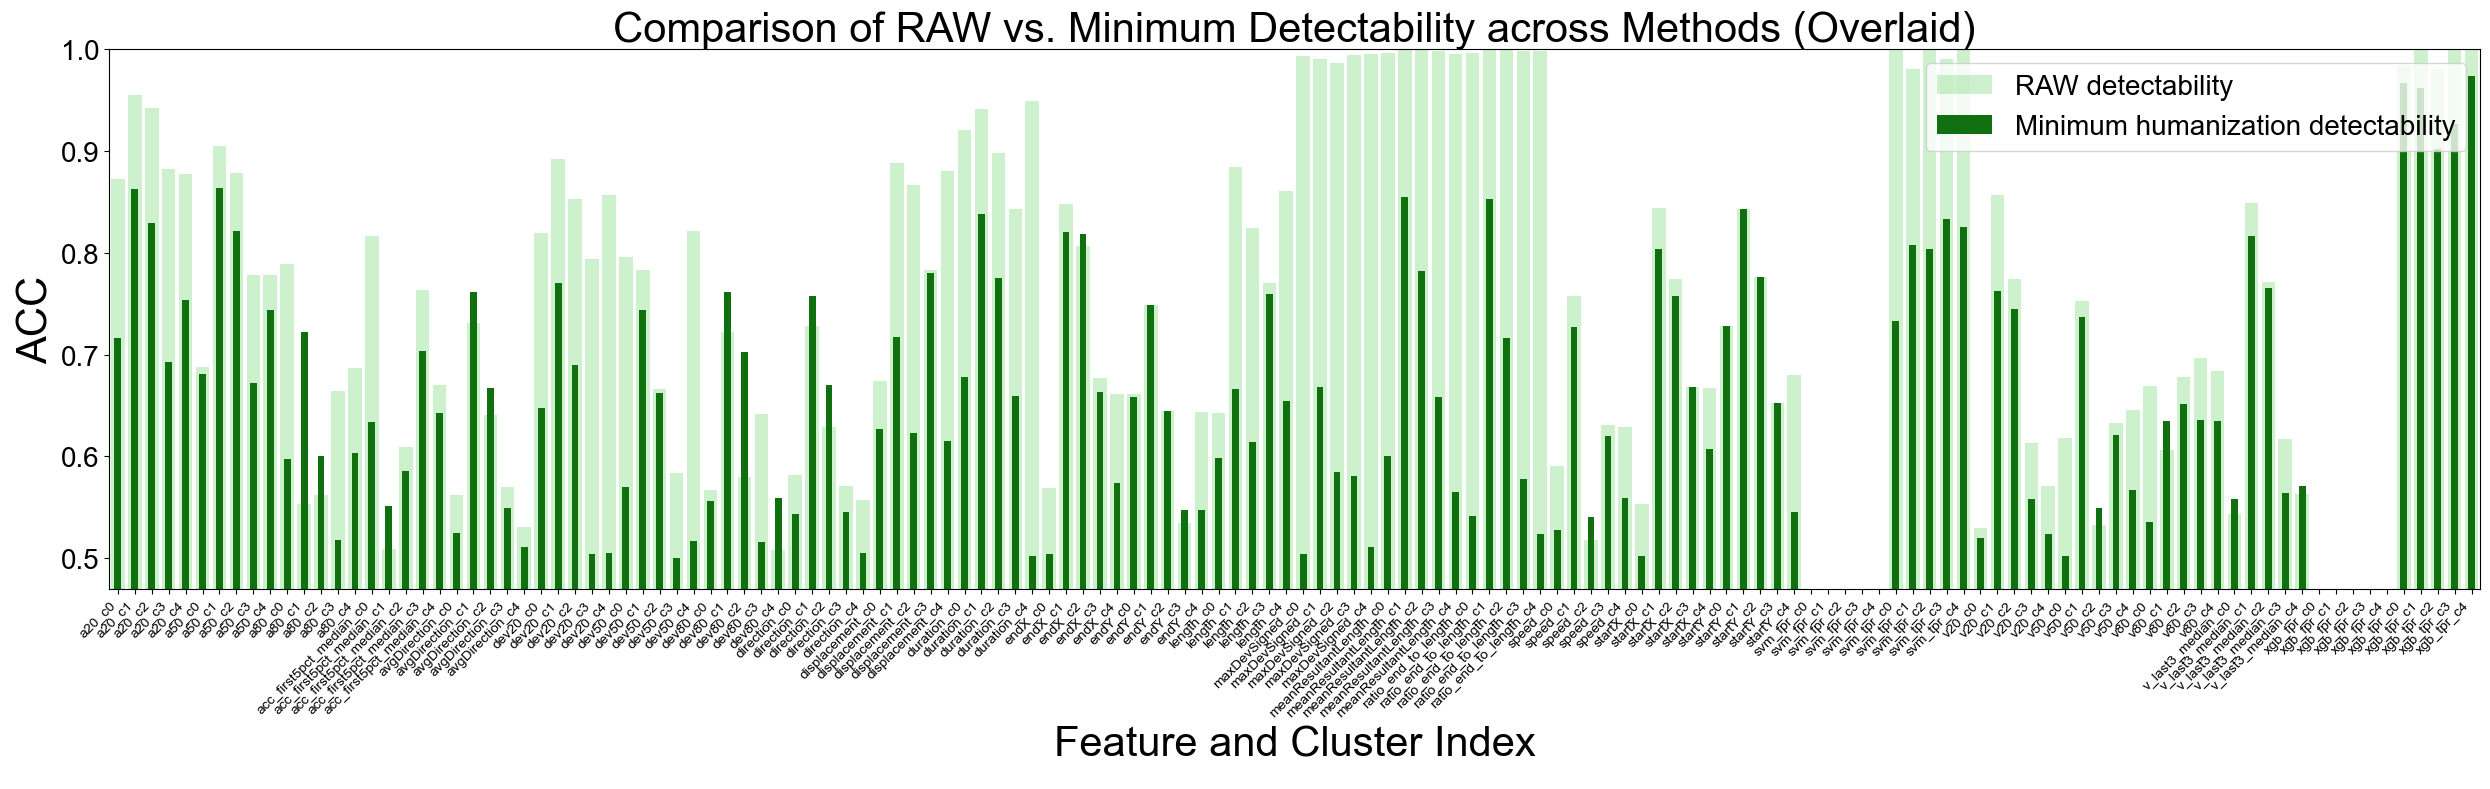

In [232]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for plotting
plot_data = []
for raw_val, diff, feature, cluster_idx in added_value:
    label = f"{feature}_c{cluster_idx}"
    # skip the heavy classifiers xgb_accuracy and svm_accuracy
    if (feature == "xgb_accuracy") or (feature == "svm_accuracy"):
        continue
    plot_data.append({"label": label, "Value": raw_val, "Type": "RAW detectability"})
    plot_data.append({"label": label, "Value": raw_val - diff, "Type": "Decreased detectability"})

df_plot = pd.DataFrame(plot_data)
df_plot.sort_values("label", inplace=True)

# Create the overlaid bar plot
plt.figure(figsize=(25, 8))

# Plot RAW detectability (wider bars in the background)
sns.barplot(
    data=df_plot[df_plot["Type"] == "RAW detectability"], 
    x="label", y="Value", color="lightgreen", label="RAW detectability", alpha=0.5
)

# Plot Decreased detectability (narrower bars in the foreground)
# Using a smaller width ensures visibility even if Decreased > RAW (diff < 0)
sns.barplot(
    data=df_plot[df_plot["Type"] == "Decreased detectability"], 
    x="label", y="Value", color="green", label="Minimum humanization detectability", width=0.4
)

plt.xticks(rotation=45, fontsize=10, horizontalalignment='right')
plt.xlabel("Feature and Cluster Index", fontsize=30)
plt.ylabel("ACC", fontsize=30)
plt.yticks(fontsize=20)
plt.title("Comparison of RAW vs. Minimum Detectability across Methods (Overlaid)", fontsize=30)
plt.legend(loc='upper right', fontsize=20)
plt.ylim(0.47, 1)
plt.tight_layout()
sns.set_style("whitegrid")
plt.show()
# set lightgrid for sns



## Collect all the classifiers and make big comparison

In [246]:
#把swipe分类器、tap分类器、interval分类器整合成一个"UltimateClassifier"，然后对每个session实时计算"是人类的概率"随时间的变化曲线。
import importlib
import analysis.processing.judge_library as judge_library
importlib.reload(judge_library)
from analysis.processing.judge_library import UltimateClassifier # or just use judge_library.UltimateClassifier

In [247]:
raw_tap_classifier_us_across_clusters

{0: ThresholdPosterior(metrics=BinaryClassificationMetrics(TP=13, FP=3667, TN=0, FN=598), threshold=5000.0, lesser_than_threshold_agent_log_odds=-3.8501476017100584, greater_than_threshold_agent_log_odds=inf),
 1: ThresholdPosterior(metrics=BinaryClassificationMetrics(TP=102, FP=3667, TN=0, FN=1211), threshold=5000.0, lesser_than_threshold_agent_log_odds=-2.5550970610185253, greater_than_threshold_agent_log_odds=inf),
 2: ThresholdPosterior(metrics=BinaryClassificationMetrics(TP=24, FP=3667, TN=0, FN=398), threshold=5000.0, lesser_than_threshold_agent_log_odds=-2.8669514836880663, greater_than_threshold_agent_log_odds=inf),
 3: ThresholdPosterior(metrics=BinaryClassificationMetrics(TP=30, FP=3667, TN=0, FN=1663), threshold=5000.0, lesser_than_threshold_agent_log_odds=-4.03306000047098, greater_than_threshold_agent_log_odds=inf),
 4: ThresholdPosterior(metrics=BinaryClassificationMetrics(TP=15, FP=3667, TN=0, FN=788), threshold=5000.0, lesser_than_threshold_agent_log_odds=-3.98030451284

In [248]:
humanized_swipe_classifiers_to_use_for_clusters
raw_tap_classifier_us_across_clusters
interval_classifier_microseconds_across_clusters

# save these classifiers to disk using joblib
import joblib
import numpy as np
from typing import Callable, List, Optional, Tuple
from functools import partial

# save the classifiers
joblib.dump(humanized_swipe_classifiers_to_use_for_clusters, "humanized_swipe_classifiers.pkl")
joblib.dump(raw_tap_classifier_us_across_clusters, "raw_tap_classifier_us_across_clusters.pkl")
joblib.dump(interval_classifier_microseconds_across_clusters, "interval_classifier_microseconds_across_clusters.pkl")

from analysis.processing.judge_library import UltimateClassifier
from analysis.lib.gesture_log_reader_utils import ranged_batched_modified_generator_with_session_timestamp

def get_prob_from_log_odds(log_odds: float) -> float:
    neg_odds = np.exp(-log_odds)
    probability = 1 / (1 + neg_odds)
    return probability


def get_human_versus_non_human_versus_agents():
    ultimate_classifiers_across_clusters = UltimateClassifier(
        classifiers_to_use_for_clusters=humanized_swipe_classifiers_to_use_for_clusters,
        tap_us_classifier_for_clusters=raw_tap_classifier_us_across_clusters,
        interval_us_classifier=interval_classifier_microseconds_across_clusters,
    )
    
    all_plot_rows = []
    for cluster_idx, task_cluster in enumerate(task_clusters):
        ranged_raw_generator_with_session_timestamp: Callable[
            [
                List[str], Optional[Callable[[List[FingerEvent]], List[FingerEvent]]]
            ], 
            List[SessionType]
        ] = partial(
            ranged_batched_modified_generator_with_session_timestamp, 
            formated_data_timestamps=formated_data_timestamps, 
            index_range=task_cluster, 
            batched_filtering_and_modification_function=None
        )
        generator_list: List[Tuple[str, List[SessionType]]] = [
            ("Humans", ranged_raw_generator_with_session_timestamp(participants=humans)),
            # ("ui_tars_no_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[0]])), ("ui_tars_available_humanity", ranged_raw_generator_with_session_timestamp(participants=[ui_tars_list[1]])),
            ("non_humanized_agents", ranged_raw_generator_with_session_timestamp(participants=non_humanized_agents)),
            ("humanized_agents", ranged_raw_generator_with_session_timestamp(participants=humanized_agents)),
            # ("non_humanized_agents_fake", fake_ranged_generator(participants=non_humanized_agents)),
            # ("humanized_agents_fake", fake_ranged_generator(participants=humanized_agents)),
        ]

        results_list_prob_0_1: List[Tuple[str, List[UltimateClassifier.ResultType]]] = []

        for label, session_generator in generator_list:
            label_result: List[UltimateClassifier.ResultType] = []
            for session in session_generator:
                session_result = ultimate_classifiers_across_clusters.predict(
                    X=session,
                    task_cluster_id=cluster_idx,
                )
                if len(session_result) == 0:
                    continue
                start_timestamp_for_this_session = session_result[0][0]
                session_result_starting_from_0_and_between_0_1 = [
                    (timestamp - start_timestamp_for_this_session, get_prob_from_log_odds(log_odds))
                    for (timestamp, log_odds) in session_result
                ]
                label_result.append(session_result_starting_from_0_and_between_0_1)
            results_list_prob_0_1.append((label, label_result))

        # Collect all clusters' sessions into one long dataframe, then plot once (mean + CI across sessions)
        
        for label, sessions in results_list_prob_0_1:
            for session_id, ts in enumerate(sessions):
                for t_us, p in ts:
                    all_plot_rows.append(
                        {
                            "cluster_idx": cluster_idx,
                            "label": label,
                            "session_id": session_id,
                            "t_us": int(t_us),
                            "p": float(p),
                        }
                    )
    return all_plot_rows


gotten_all_rows = get_human_versus_non_human_versus_agents()




Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_185438.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_161459.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_161718.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_161850.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_164345.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111

Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155304.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_143233.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     940.922936] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_144521.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_104231.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_r

Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_183425.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_183726.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_183851.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     839.185891] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251208_143445.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detect

Kept 4 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_220331.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_210536.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 4 complete samples from all 5 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251203_042605.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detect

In [251]:
import matplotlib.pyplot as plt


def plot_human_vs_nonhuman_vs_humanized(all_plot_rows, time_us_cutoff):

    df_plot = pd.DataFrame(all_plot_rows)

    # line style by label
    dashes_by_label = {
        "Humans": "solid",
        "non_humanized_agents": "dashed",
        "humanized_agents": "dotted",
}
    df_plot = df_plot[df_plot["t_us"] < time_us_cutoff]

    plt.figure(figsize=(14, 6))
    sns.set_style("whitegrid")


    for label_name in ["Humans", "non_humanized_agents", "humanized_agents"]:
        for task_cluster_id in range(len(task_clusters)):
            subset = df_plot[(df_plot["label"] == label_name) & (df_plot["cluster_idx"] == task_cluster_id)]
            sns.lineplot(
                data=subset,
                x="t_us",
                y="p",
                # label=f"Cluster {task_cluster_id} - {label_name}",
                linestyle=dashes_by_label[label_name],
                estimator="mean",
                errorbar="sd",
                alpha=0.5,
                color=sns.color_palette("husl", len(task_clusters))[task_cluster_id],
            )
    sns.lineplot(
        data=df_plot,
        x="t_us",
        y="p",
        hue="cluster_idx",                 # color by cluster
        style="label",                     # linestyle by label
        dashes={"Humans": (1, 0), "non_humanized_agents": (4, 2), "humanized_agents": (1, 1)},
        estimator="mean",
        errorbar="sd",                     # CI shading across sessions
        alpha=0.3,
        palette=sns.color_palette("husl", len(task_clusters)),
    )

    plt.xlabel("Time (microseconds)")
    plt.ylabel("P(human) / probability (0..1)")
    plt.ylim(-0.05, 1.05)
    plt.title("Human vs non-humanized vs humanized (mean ± SD across sessions)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
    # plt.tight_layout()
    plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

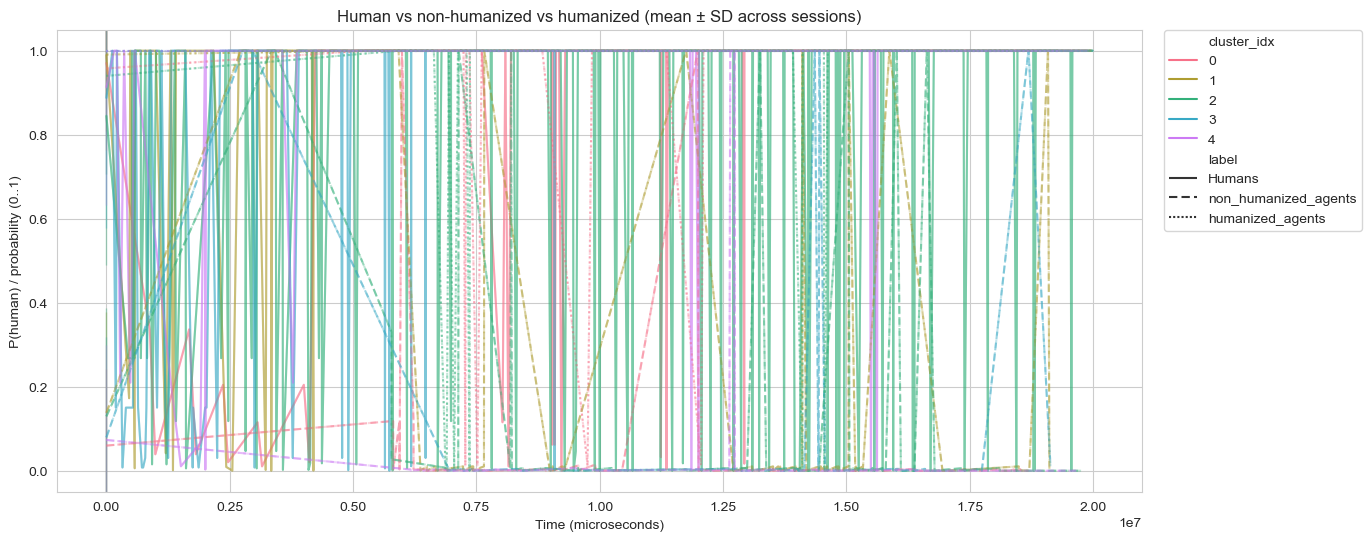

In [252]:
plot_human_vs_nonhuman_vs_humanized(gotten_all_rows, time_us_cutoff=1e6 * 20)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

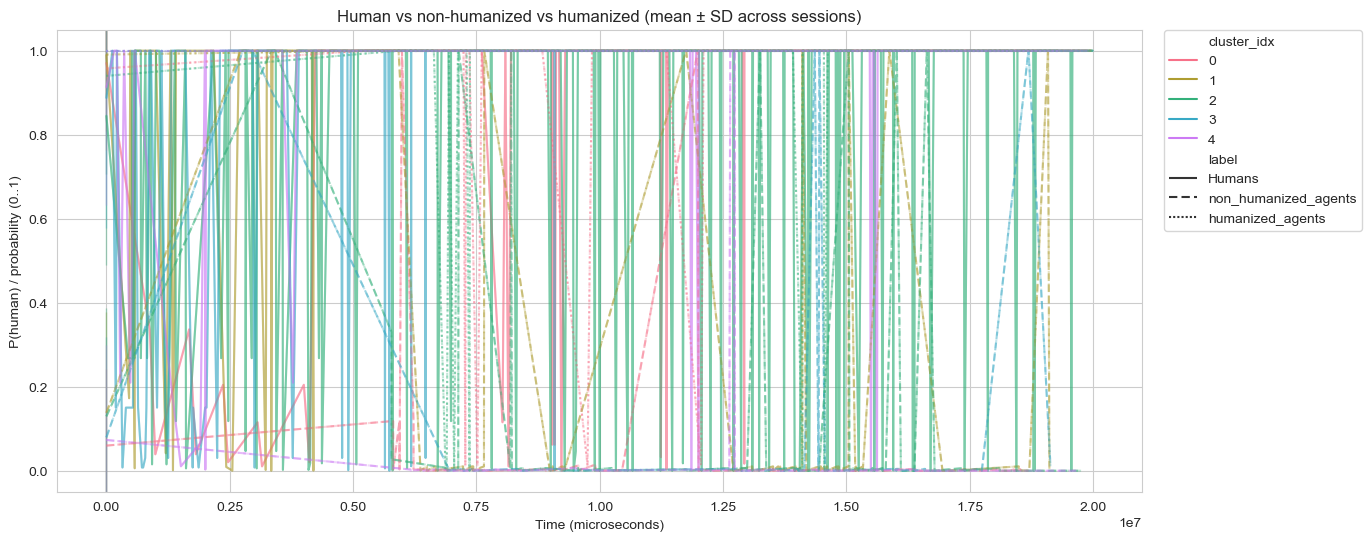

In [253]:

plot_human_vs_nonhuman_vs_humanized(gotten_all_rows, time_us_cutoff=1e6 * 20)

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

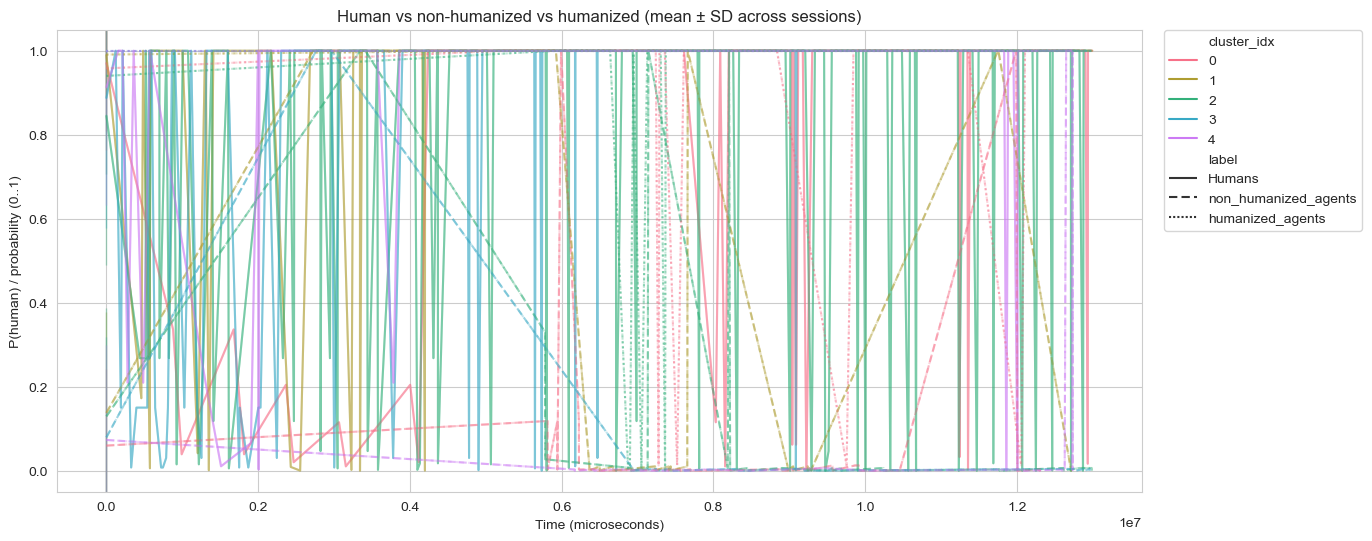

In [255]:

plot_human_vs_nonhuman_vs_humanized(gotten_all_rows, time_us_cutoff=1e6 * 13)

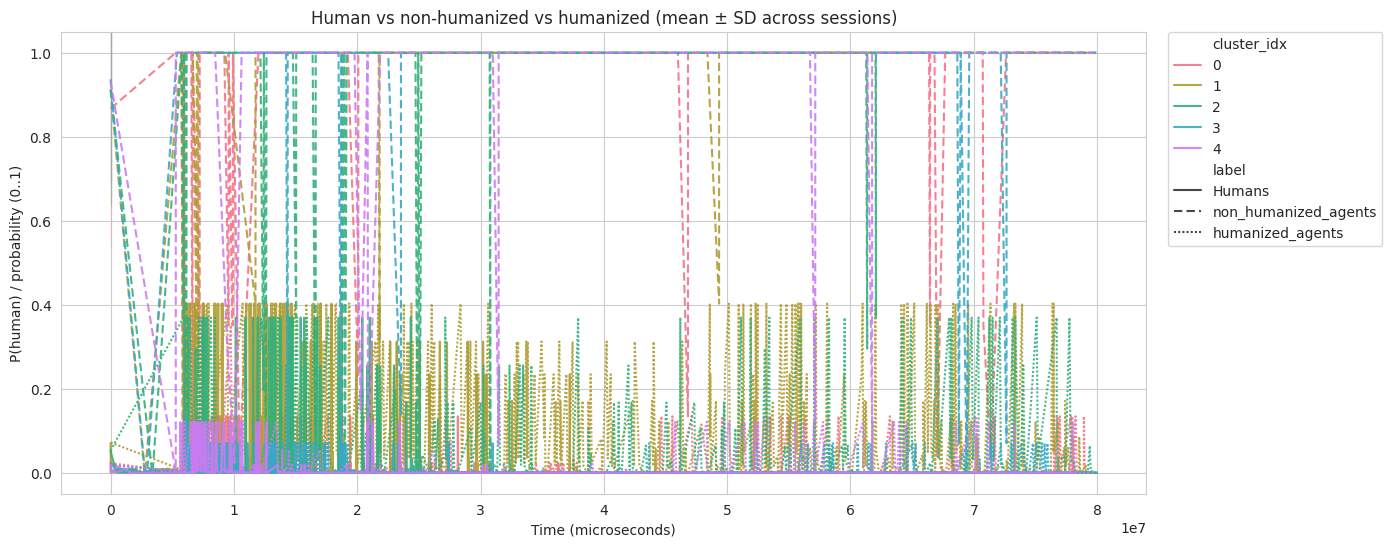

In [61]:

plot_human_vs_nonhuman_vs_humanized(gotten_all_rows, time_us_cutoff=1e6 * 80)

## calculate mutual information

### binary classification mutual information per method vs human on different clusters

In [298]:
from analysis.processing.calculate_roc_auc_from_feature import make_feature_table_but_mutual_information_binary


from typing import Dict, List, Tuple
#from draw_motion_event2 import plot_gestures_2
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import sklearn

result_csv = pd.DataFrame()

# raw_swipe_classifiers_to_use_for_clusters: Dict[int, Tuple[Pipeline, XGBClassifier]] = {}
# humanized_swipe_classifiers_to_use_for_clusters: Dict[int, Tuple[Pipeline, XGBClassifier]] = {}

for cluster_idx, task_cluster in enumerate(task_clusters):
    list_to_concat: List[pd.DataFrame] = []

    try:
        non_humanized_result_csv = make_feature_table_but_mutual_information_binary(
            task_cluster_id=cluster_idx,
            method_name="RAW",
            pos_iterator=("non_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents,  index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(non_humanized_result_csv)
    except (ValueError, TypeError):
        print("Skipped unhumanized_agents: raw_faker incompatible with current bot_line_fit API")
    
    
    try:
        humanized_result_csv = make_feature_table_but_mutual_information_binary(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match",
            pos_iterator=("humanized_agents", ranged_swipe_generator(
                participants=humanized_agents, index_range=task_cluster)),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(humanized_result_csv)
    except (ValueError, TypeError):
        print("Skipped unhumanized_agents: raw_faker incompatible with current bot_line_fit API")

    try:
        fake_humanized_result_csv = make_feature_table_but_mutual_information_binary(
            task_cluster_id=cluster_idx,
            method_name="rotation_and_match_disturbance",
            pos_iterator=("fake_humanized_agents", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=static_fit_effort_provider.humanity_disturbance
                )),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv)
    except (ValueError, TypeError):
        print("Skipped unhumanized_agents: raw_faker incompatible with current bot_line_fit API")
        

    try:
        fake_humanized_result_csv_2 = make_feature_table_but_mutual_information_binary(
            task_cluster_id=cluster_idx,
            method_name="b_spline_disturbance",
            pos_iterator=("fake_humanized_agents_b_spline", ranged_swipe_generator(
                participants=non_humanized_agents, index_range=task_cluster,
                humanity_disturbance=b_spline_faker
                )),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(fake_humanized_result_csv_2)
    except (ValueError, TypeError):
        print("Skipped unhumanized_agents: raw_faker incompatible with current bot_line_fit API")

    try:
        unhumanized_result_csv = make_feature_table_but_mutual_information_binary(
            task_cluster_id=cluster_idx,
            method_name="unhumanized_agents",
            pos_iterator=("unhumanized_agents", ranged_swipe_generator(
                participants=humanized_agents, index_range=task_cluster,
                humanity_disturbance=raw_faker
                )),
            neg_iterator=("humans", ranged_swipe_generator(
                participants=humans, index_range=task_cluster)),
        )
        list_to_concat.append(unhumanized_result_csv)
    except (ValueError, TypeError):
        print("Skipped unhumanized_agents: raw_faker incompatible with current bot_line_fit API")
        
    # directly join the three result csvs to results
    result_csv = pd.concat(
        [result_csv] + list_to_concat,
        axis=1
    )

    
result_csv.T.to_csv("results1220/final_mutual_information_binary_per_method.csv")

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_203653.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_203833.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_204008.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_204358.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_205227.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_205336.log, which is unex

Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_161850.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_164345.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_164832.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260201_211742.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file logs/logs_user4567_gesture_recording/gesture_recording_20260201_212028.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 53 complete samples from all 54 samples in the 

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_115003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_134628.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_134809.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_152620.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154457.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordi

Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_104541.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_204624.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_204732.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_212932.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_213116.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file logs/logs_user4567_gesture_recording/gesture_recording_20260201_203507.log. 

...

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_121655.log, which is unexpected and currently not supported. Skipping this file.
Error processing file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_121749.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 000006b9, len(current_gesture): 7. Discarding the last incomplete trace.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_122223.log, which is unexpected and currently not supported. Skipping this file.
Error processing file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_122322.log: Unexpected log format: log ended without proper termination. last_is_syn_report: True, inherited_id: 0000074b, len(current_ges

Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260201_215847.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_195411.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_195518.log, which is unexpected and currently not supported. Skipping this file.
Incomplete sample detected in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_202242.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 5 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251202_210536.log. This may indicate an unexpected log format or missing lines

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_204914.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_205007.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_205309.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260131_205542.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gestur

Kept 0 complete samples from all 1 samples in the generated trace.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user2_gesture_recording/gesture_recording_20251012_121239.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_135228.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_140248.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_141003.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_142228.log, which is unexpected and currently not supported.

Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_155747.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user4567_gesture_recording/gesture_recording_20260202_205056.log, which is unexpected and currently not supported. Skipping this file.


### Multiclass of various method and human vs each other on different clusters

In [262]:
# reload analysis.processing.calculate_roc_auc_from_feature
import importlib
import analysis.processing.calculate_roc_auc_from_feature
importlib.reload(analysis.processing.calculate_roc_auc_from_feature)

<module 'analysis.processing.calculate_roc_auc_from_feature' from '/Users/gouwenbin/Desktop/Passing-the-Turing-Test-on-Screen-Agent-Humanization-Benchmark-main/analysis/processing/calculate_roc_auc_from_feature.py'>

In [265]:
#这是3.10.1的多分类版本——不是binary（agent vs human），
#而是把所有方法（non_humanized、humanized、fake_humanized、b_spline、unhumanized）
#同时放进来做multiclass mutual information计算。

from analysis.processing.calculate_roc_auc_from_feature import make_feature_table_but_mutual_information_multiple
from typing import Dict, List, Tuple
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import sklearn

result_csv_multiple_info = pd.DataFrame()

for cluster_idx, task_cluster in enumerate(task_clusters):
    list_to_concat: List[pd.DataFrame] = []
    generators: List[Tuple[str, List[List[FingerEvent]]]] = [
        ("non_humanized_agents", ranged_swipe_generator(
            participants=non_humanized_agents, index_range=task_cluster)),
        ("humanized_agents", ranged_swipe_generator(
            participants=humanized_agents, index_range=task_cluster)),
        ("fake_humanized_agents", ranged_swipe_generator(
            participants=non_humanized_agents, index_range=task_cluster,
            humanity_disturbance=static_fit_effort_provider.humanity_disturbance)),
        ("fake_humanized_agents_b_spline", ranged_swipe_generator(
            participants=non_humanized_agents, index_range=task_cluster,
            humanity_disturbance=b_spline_faker)),
        ("unhumanized_agents", ranged_swipe_generator(
            participants=humanized_agents, index_range=task_cluster,
            humanity_disturbance=raw_faker)),
    ]
    try:
        result_per_task_cluster = make_feature_table_but_mutual_information_multiple(
            task_cluster_id=cluster_idx,
            type_and_data_iterators=generators,
        )
        list_to_concat.append(result_per_task_cluster)
    except (ValueError, TypeError):
        print("Warning: No valid data or API incompatibility for task", task_cluster)

    result_csv_multiple_info = pd.concat(
        [result_csv_multiple_info] + list_to_concat,
        axis=1
    )

result_csv_multiple_info.T.to_csv("results1220/final_mutual_information_multiple.csv")
print("Done. Shape:", result_csv_multiple_info.shape)

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260205_030456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 15 complete samples from all 16 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_202

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251215_141730.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 5 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251217_020420.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_201717.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/g

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251216_151243.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 11 complete samples from all 12 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_182609.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 98 complete samples from all 99 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_200814.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 4 complete samples from all 5 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_20

Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_164737.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 79 complete samples from all 82 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_205852.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 4 complete samples from all 6 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/autoglm_raw_gesture_recording_2026020X/gesture_recording_20260204_220331.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 2 complete samples from all 3 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2

Done. Shape: (24, 5)


### human vs unhumanized agent on all task as 1 cluster

In [266]:
#把所有116个task合并成一个大pool，计算human vs non_humanized_agents的multiclass mutual information，
#输出归一化的相对重要性百分比（5.45%、5.44%...），对应论文Table 6的IF列。
def get_human_versus_non_human_on_all_task():
    generators: List[Tuple[str, List[List[FingerEvent]]]] = [
        ("Humans", ranged_swipe_generator(
            participants=humans)),
        ("non_humanized_agents", ranged_swipe_generator(
            participants=non_humanized_agents)),
        # ("humanized_agents", ranged_swipe_generator(
         #    participants=humanized_agents)),
    ]
    
    result = make_feature_table_but_mutual_information_multiple(
        task_cluster_id=-1,
        type_and_data_iterators=generators,
    )
    return result

get_human_versus_non_human_on_all_task().to_csv("results1220/human_vs_nonhuman_mutual_information_all_tasks.csv")

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_010704.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

In [267]:
def temp_print_in_percentages():
    df = pd.read_csv("results1220/human_vs_nonhuman_mutual_information_all_tasks.csv", index_col=[0])
    for col in df.columns:
        df[col] = df[col].apply(lambda x: f"{x * 100.0:.2f}%")
    print(df)
temp_print_in_percentages()
#前3名完全一样，
#只是meanResultantLength和maxDevSigned顺序调换了
#这个微小差异来自数据集不同（你有7个用户+AutoGLM，作者有3个用户+CPM）。

                     (-1, 'mutual_information_multiclass')
feature                                                   
maxDevSigned                                         5.45%
meanResultantLength                                  5.44%
ratio_end_to_length                                  5.43%
avgDirection                                         5.33%
direction                                            5.20%
dev50                                                4.80%
startX                                               4.71%
displacement                                         4.68%
length                                               4.61%
duration                                             4.60%
endX                                                 4.60%
dev20                                                4.34%
dev80                                                4.18%
startY                                               4.16%
v80                                                  3.9

In [268]:
from analysis.processing.calculate_roc_auc_from_feature import make_feature_table_but_mutual_information_multiple

def get_human_versus_non_human_on_all_task():
    generators: List[Tuple[str, List[List[FingerEvent]]]] = [
        ("Humans", ranged_swipe_generator(
            participants=humans)),
        ("non_humanized_agents", ranged_swipe_generator(
            participants=non_humanized_agents)),
        # ("humanized_agents", ranged_swipe_generator(
         #    participants=humanized_agents)),
    ]
    
    result = make_feature_table_but_mutual_information_multiple(
        task_cluster_id=-1,
        type_and_data_iterators=generators,
        output_relative_importance=False,
    )
    return result

get_human_versus_non_human_on_all_task() # .to_csv("results0123/human_vs_nonhuman_mutual_information_all_tasks.csv")

SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_010704.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

,"(-1, mutual_information_multiclass)"
feature,
maxDevSigned,0.570747
meanResultantLength,0.569638
ratio_end_to_length,0.568555
avgDirection,0.557268
direction,0.544612
dev50,0.502374
startX,0.493220
displacement,0.489522
length,0.482564


SYN_CONFIG found in line, which is unexpected but not disruptive: [    2449.596335] /dev/input/event2: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_154302.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173741.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173828.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_173915.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251115_175245.log

Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_150710.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file logs/logs_user123_1011_till_1015_gesture_recording/user3_batch_1_gesture_recording/gesture_recording_20251014_165316.log, which is unexpected and currently not supported. Skipping this file.
SYN_CONFIG found in line, which is unexpected but not disruptive: [     861.450668] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
SYN_CONFIG found in line, which is unexpected but not disruptive: [     345.430142] /dev/input/event3: EV_SYN       SYN_CONFIG           00000004
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/gesture_recording_20251112_102333.log, which is unexpected and currently not supported. Skipping this file.
Multitouch event found in file gesture_recordings/gesture_recording_2025111x/ge

Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_010704.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 1 complete samples from all 2 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_044456.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 18 complete samples from all 19 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/gesture_recording_20251209_092718.log. This may indicate an unexpected log format or missing lines. Keeping the traces with complete properties.
Kept 0 complete samples from all 1 samples in the generated trace.
Incomplete sample detected in file gesture_recordings/gesture_recording_o_2025_10_2026_01/ge

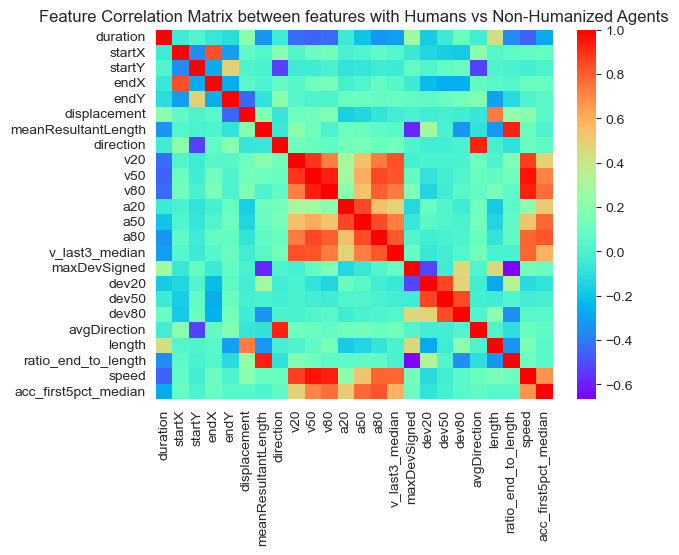

In [269]:
#计算24个特征之间的Pearson相关系数矩阵，画成热力图，对应论文Figure 9（Feature Correlation Matrix）。

from analysis.processing.calculate_roc_auc_from_feature import build_features_dataframe, get_feature_columns, get_numeric_feature_column_names
import seaborn as sns
import matplotlib.pyplot as plt
def get_human_versus_non_human_feature_correlation_on_all_task():
    generators: List[Tuple[str, List[List[FingerEvent]]]] = [
        ("Humans", ranged_swipe_generator(
            participants=humans)),
        ("non_humanized_agents", ranged_swipe_generator(
            participants=non_humanized_agents)),
        # ("humanized_agents", ranged_swipe_generator(
         #    participants=humanized_agents)),
    ]
    
    result = build_features_dataframe(
        generators
    )
    feature_columns = get_feature_columns(result, get_numeric_feature_column_names(result))
    
    correlation_matrix = feature_columns.corr()
    sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap="rainbow")
    plt.title("Feature Correlation Matrix between features with Humans vs Non-Humanized Agents")
    plt.show()
get_human_versus_non_human_feature_correlation_on_all_task()
